# 3. risk analysis and CAPM

In this notebook we build a **risk-focused report** for a small set of “objects” (can be assets, strategies, or portfolios). the goal is not just to compute numbers, but to make the **math and interpretation transparent** so we can understand what each metric means and how it is calculated and how we can interpret from them.

in this notebook we produce

- tables (small, topic-specific) and plots (simple, comparable) for:
  - performance and basic distribution shape
  - drawdowns and drawdown episodes
  - tail risk (vaR / expected shortfall) + backtests
  - historical stress windows
  - capm factor regression
  - risk attribution and diversification diagnostics


## sign conventions

many risk measures are easier to read as **positive “loss magnitudes”**. for example, if the 5% quantile of returns is negative, we report:

- $\text{vaR}_{5\%} = -q_{0.05}(r)$ (positive number)
- $\text{ES}_{5\%} = -\mathbb{e}[r \mid r \le q_{0.05}(r)]$ (positive number)

so bigger vaR/ES means worse tail risk.



### Imports and plotting style


In [1]:
import warnings
from pathlib import Path as path
from datetime import datetime
from statistics import NormalDist as normaldist
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages as pdfpages
from cycler import cycler
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression
from IPython.display import display

import sys
sys.path.append(str(path("..").resolve()))
import quantfinlab.portfolio as pf

warnings.filterwarnings("ignore")


palette = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 175,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})

ann = 252
rf_annual = 0.04
rf_daily = (1 + rf_annual) ** (1 / ann) - 1


## 1) data and returns

### what we need as input

the report needs **aligned daily returns** for each object:

- a date index $t = 1, 2, \dots, T$
- for each object $j$, a series $\{r_{j,t}\}$

if you start from prices $p_t$, we use **simple returns**:

$$
r_t = \frac{p_t}{p_{t-1}} - 1
$$

in this notebook we keep everything in simple returns because:
- the nav compounding is literally $\prod (1+r)$,
- most risk metrics (vaR/ES on daily returns) are commonly shown in simple-return units.



## Load data and compute returns


the data used in this project can be downloaded from here ([Stooq US (nasdaq) daily market data])


[Stooq US (nasdaq) daily market data]: https://stooq.com/db/h/

In [2]:
df = pd.read_parquet("../data/nasdaq_all_close_volume.parquet")
df["date"] = pd.to_datetime(df["Date"], errors="coerce")
dcol = "date"
df = df.dropna(subset=[dcol]).sort_values(dcol)

close_map, vol_map = {}, {}
for c in df.columns:
    c_str = str(c)
    if c_str.lower() == dcol.lower() or "__" not in c_str:
        continue
    t, f = c_str.rsplit("__", 1)
    f = f.lower()
    if f == "close":
        close_map[t] = c
    elif f == "volume":
        vol_map[t] = c

tickers_all = sorted(set(close_map).intersection(vol_map))

close_prices = df[[close_map[t] for t in tickers_all]].copy()
volumes = df[[vol_map[t] for t in tickers_all]].copy()
close_prices.columns = tickers_all
volumes.columns = tickers_all
close_prices.index = pd.to_datetime(df[dcol].values)
volumes.index = pd.to_datetime(df[dcol].values)

close_prices = close_prices.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
volumes = volumes.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

start = pd.Timestamp("2016-01-01")
close_prices = close_prices.loc[close_prices.index >= start]
volumes = volumes.loc[volumes.index >= start]

idx = close_prices.index.intersection(volumes.index)
cols = close_prices.columns.intersection(volumes.columns)
close_prices = close_prices.loc[idx, cols]
volumes = volumes.loc[idx, cols]

returns = pf.prices_to_returns(close_prices)


first_date = pd.concat([close_prices.apply(pd.Series.first_valid_index),
                         volumes.apply(pd.Series.first_valid_index)],axis=1,).max(axis=1)


spy = pd.read_csv("../data/spy_yfinance.csv")
spy["date"] = pd.to_datetime(spy["Date"], errors="coerce") if "date" in [str(c).lower() for c in spy.columns] else pd.to_datetime(spy["Date"], errors="coerce")
dcol_spy = "date" if "date" in spy.columns else "Date"
spy = spy.dropna(subset=[dcol_spy]).sort_values(dcol_spy).set_index(dcol_spy)

if "Adj Close" in spy.columns:
    spy_px = pd.to_numeric(spy["Adj Close"], errors="coerce")
else:
    raise ValueError("spy_yfinance.csv missing adj close column")

spy_px = spy_px.loc[spy_px.index >= start]
market_ret = spy_px.pct_change().replace([np.inf, -np.inf], np.nan)


## 2) rebalancing, universe selection, and strategies

In the last project we imported the same data from nasdaq and filtered the most liquid stocks for each month from 2016 to 2026 and implemented MeanVariance, MinVariance and MaxSharpe models with monthly rebalancing and backtested and compared them under real market conditions.

for better understanding please read the last project ([2. Portfolio Optimization with Mean-Variance Models]) because this project is highly related to it and it's continue to that project.

[2. Portfolio Optimization with Mean-Variance Models]: https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html


### rebalancing logic (no look-ahead)

a clean backtest timeline is:

1) at the start of day $t$, if $t$ is a rebalance date, compute target weights $w_t$ using information up to $t-1$  
2) apply transaction costs/turnover if needed  
3) hold weights through the day and apply realized return $r_{p,t+1}$ next

transaction cost proxy (simple linear model):

$$
\text{tc}_t = c \sum_i |w_{i,t} - w_{i,t-1}|
$$

where $c$ is a per-unit turnover cost.

### strategies used here (high level)

In this notebook we don't repeat the full grid from the last notebook. for the first implementation we build exactly two portfolio objects from the portfolio library: **MinVar EWMA** and **MS-FG EWMA Mom**. we also use two of the stocks in our dataset for showing different results in different types of objects. We use **NVIDIA** and **Apple**. and for CAPM analysis we use **SPY** as our benchmark. At the end of this notebook we analyze the known Project 2 finalist portfolios on both US and HK data.

if you later add more objects, the report works as long as:
- each object is a daily return series aligned to the same date index
- object names are consistent (for labeling)


In [3]:
from quantfinlab.portfolio import covariance, expected_returns, optimizers, walkforward

rebal_dates = pf.make_rebalance_dates(returns.index, freq="ME", min_history_days=252)

starter_specs = [
    {"name": "MinVar EWMA", "optimizer": "MinVar", "cov_model": "EWMA"},
    
    {"name": "MS-FG EWMA Mom", "optimizer": "FrontierGrid",
    "cov_model": "EWMA", "mu_model": "Momentum"}]

starter_stack = walkforward.run_walkforward_grid(
    returns=returns,
    close=close_prices,
    volume=volumes,
    rebalance_dates=rebal_dates,
    cov_models={"EWMA": covariance.ewma_covariance},
    mu_models={"Momentum": expected_returns.momentum_mu},
    optimizers={"MinVar": optimizers.minimum_variance,
                "FrontierGrid": optimizers.max_sharpe_frontier_grid},
    strategy_specs=starter_specs,
    rf_daily=rf_daily,
    annualization=ann)

cache = dict(starter_stack.cache)
res_minvar = starter_stack.backtests["MinVar EWMA"]
res_frontier = starter_stack.backtests["MS-FG EWMA Mom"]

base_idx = returns.index.intersection(res_minvar.net_returns.index).intersection(res_frontier.net_returns.index)

nvda_ret = returns["NVDA"].reindex(base_idx).fillna(0.0)
aapl_ret = returns["AAPL"].reindex(base_idx).fillna(0.0)

minvar_ret = res_minvar.net_returns.reindex(base_idx).fillna(0.0)
frontier_ret = res_frontier.net_returns.reindex(base_idx).fillna(0.0)

market_ret = market_ret.reindex(base_idx).fillna(0.0)

obj = {
    "NVDA": nvda_ret,
    "AAPL": aapl_ret,
    "MinVar EWMA": minvar_ret,
    "MS-FG EWMA Mom": frontier_ret}

obj_colors = {
    "NVDA": palette[0],
    "AAPL": palette[1],
    "MinVar EWMA": palette[2],
    "MS-FG EWMA Mom": palette[3]}

print("analysis objects:", list(obj.keys()))
print("date range:", base_idx.min().date(), "to", base_idx.max().date(), ", n:", len(base_idx))


analysis objects: ['NVDA', 'AAPL', 'MinVar EWMA', 'MS-FG EWMA Mom']
date range: 2017-01-31 to 2026-01-28 , n: 2261


## 3) core risk metrics

In this section we build tables that summarize each object using only its own return series (We had this in the project 2 too).

### 3.1 nav (cumulative wealth)

Given daily returns $r_t$, if returns are computed simple, we define nav as:

$$
\text{nav}_t = \prod_{u \le t} (1 + r_u)
$$

in code, this is a cumulative product of $(1+r)$.

### 3.2 annualized return

from nav, the total growth factor is $\text{nav}_T$. to annualize over $T$ trading days (We assume 252 trading days in one year):

$$
r^{ann} = \text{nav}_T^{252/T} - 1
$$

this assumes the sample growth rate continues at the same pace (a standard convention).

### 3.3 annualized volatility

daily volatility is the sample standard deviation:

$$
\hat\sigma = \sqrt{\frac{1}{T-1}\sum_{t=1}^T (r_t - \bar r)^2}
$$

annualized volatility is:

$$
\hat\sigma^{ann} = \hat\sigma\sqrt{252}
$$

### 3.4 sharpe ratio

For sharpe we use excess returns (the returns compared to risk free rate returns) and Volatility for comparing excess-return risk-adjusted performance :

$$
\text{sharpe} = \frac{\bar r^{ex}}{\hat\sigma}\sqrt{252}
\quad\text{where}\quad
\bar r^{ex} = \frac{1}{T}\sum_{t=1}^T (r_t - r_{f,t})
$$

With sharpe we can tell how many units of excess return we gain per unit of volatility.

### 3.5 sortino ratio (downside-focused)

For sortino we replace total volatility with **downside deviation**. We define downside returns relative to a target $\tau$ (often $0$ or $r_f$). So we set returns higher than risk free rate as 0 to analyze the lowest returns:

$$
d_t = \min(0, r_t - \tau)
$$

downside deviation:

$$
\sigma_d = \sqrt{\frac{1}{T-1}\sum_{t=1}^T d_t^2}
$$

sortino:

$$
\text{sortino} = \frac{\bar r - \tau}{\sigma_d}\sqrt{252}
$$


In [4]:
def nav_series(r):
    r = pd.Series(r).fillna(0.0)
    return (1 + r).cumprod()

def sortino(r):
    x = pd.Series(r).dropna()
    ex = x - rf_daily
    dn = np.minimum(ex, 0)
    den = np.sqrt((dn ** 2).mean())
    return float((ex.mean() / den) * np.sqrt(ann)) if den > 1e-12 else np.nan

perf_rows = []

for name, r in obj.items():
    x = pd.Series(r).dropna()

    nav = nav_series(x)
    ann_return = float(nav.iloc[-1] ** (ann / len(x)) - 1) if len(x) else np.nan

    daily_mean = float(x.mean())
    daily_vol = float(x.std(ddof=1))
    ann_vol = daily_vol * np.sqrt(ann) if daily_vol > 1e-12 else np.nan

    sharpe = ((daily_mean - rf_daily) / daily_vol * np.sqrt(ann)) if daily_vol > 1e-12 else np.nan
    sortino_ratio = sortino(x)

    perf_rows.append({
        "object": name,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": float(sharpe) if np.isfinite(sharpe) else np.nan,
        "sortino": float(sortino_ratio) if np.isfinite(sortino_ratio) else np.nan,
    })

perf_tbl = pd.DataFrame(perf_rows).set_index("object").sort_index()


In [5]:
display(perf_tbl.round(2))


,ann_return,ann_vol,sharpe,sortino
object,,,,
AAPL,0.28,0.30,0.85,1.25
MS-FG EWMA Mom,0.28,0.29,0.86,1.24
MinVar EWMA,0.17,0.15,0.84,1.21
NVDA,0.61,0.50,1.12,1.68


As we can see nvidia has so much more annual returns than other objects but the annual volatility is insanely more. even with more volatility, Apple and Nvidia still have more sharpe and sortino ratio, but if we care about risk, it's even obvious from the first metric (annual vol) that our diversification reduced the volatility succesfully.
And in 2016 we wouldn't know in 2026 nvidia would grow this much and give this much return. and even if we knew we probably wouldn't trust this much volatility and hold it until now. the best thing we could've done was make a portfolio of the top 100 stocks in that time and update it each month. we now get to other metrics for comparing the risk of these 4 objects.

---

## 4) rolling volatility

volatility is not constant. a single full-sample $\sigma$ hides regime changes. with rolling volatility we can analyze the volatility overtime and see different volatility of an asset in different times.

### rolling statistics

a rolling volatility over window length $w$ (for example 60 days) is:

$$
\hat\sigma_{t,w} = \sqrt{\frac{1}{w-1}\sum_{u=t-w+1}^t (r_u - \bar r_{t,w})^2}
$$

and annualized rolling vol is:

$$
\hat\sigma_{t,w}^{ann} = \hat\sigma_{t,w}\sqrt{252}
$$


we plot multiple windows (e.g., 20/60/252 days) because:
- short windows react quickly and are more noisy (good for risk control)
- long windows are smoother (good for long-horizon intuition)



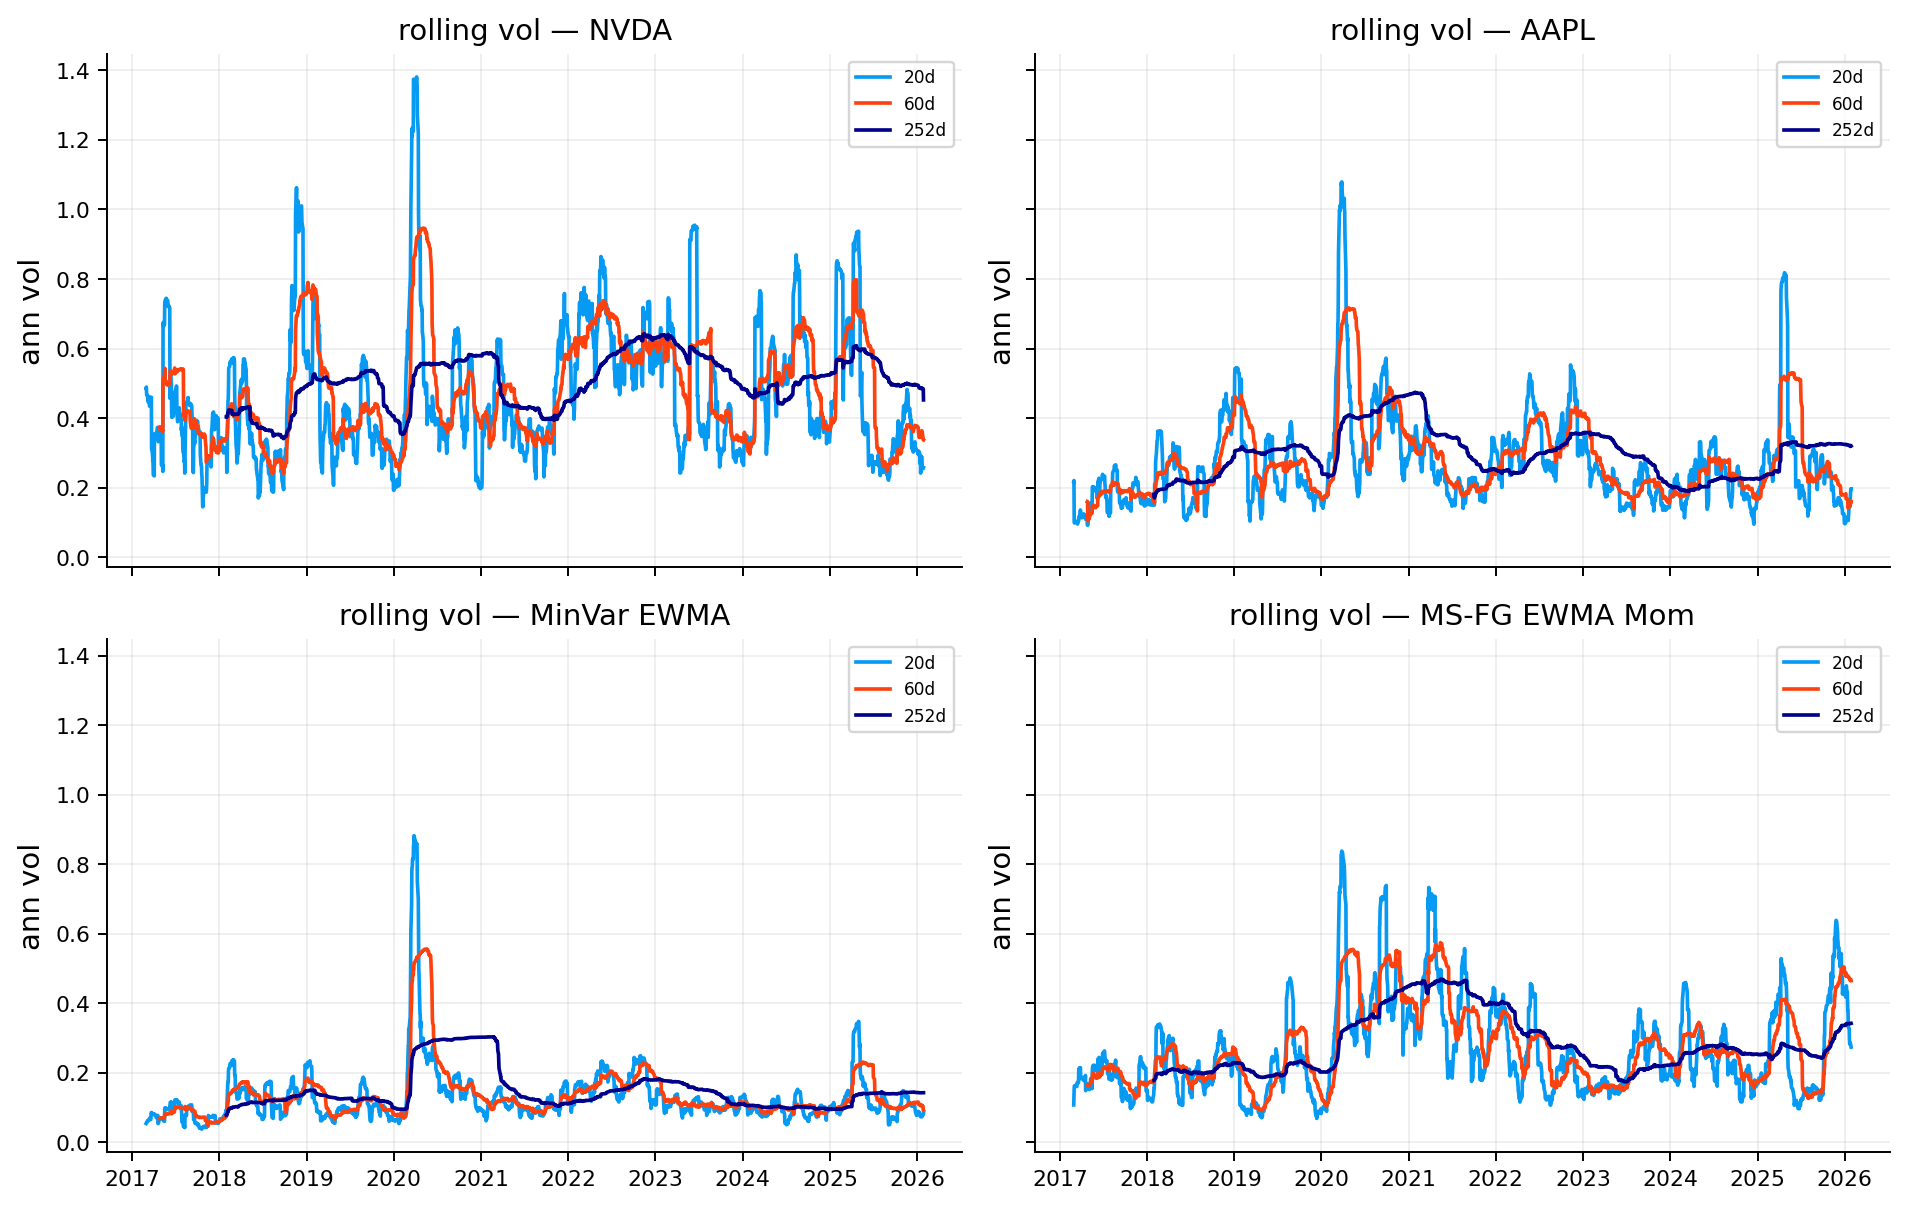

In [6]:
windows = [20, 60, 252]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, (name, r) in enumerate(obj.items()):
    ax = axes[i]
    x = pd.Series(r).dropna()
    for w in windows:
        rv = x.rolling(w).std(ddof=1) * np.sqrt(ann)
        ax.plot(rv.index, rv.values, lw=1.5, label=f"{w}d")

    ax.set_title(f"rolling vol — {name}")
    ax.set_ylabel("ann vol")
    ax.legend()

plt.tight_layout()
plt.show()


As we can see all of our objects have been more volatile in 2020 due to Covid crash. but the difference is that our two stocks have experienced more volatility in crash times and our diversified portfolios were able to manage the volatility in those times better and had lower effect from crashes.
And as we can see Nvidia has the most noise and movement and high volatility overtime and our MinVar model with EWMA covariance managed to control volatility overtime better than all the other objects.

---

## 5) distribution shape and tail diagnostics

performance ratios (sharpe/sortino) do **not** tell you what the return distribution looks like. in the metrics that we analyzed we only work with variance and mean. not the real shape and behavior of distribution. two strategies can have the same sharpe but very different crash behavior.

### 5.1 skewness

skewness measures asymmetry. using centered moments:

$$
\text{skew} = \frac{\mathbb{e}[(r-\mu)^3]}{\sigma^3}
$$

- negative skew can mean occasional large negative days (crash)
- positive skew can mean occasional large positive days (lottery-like)

### 5.2 excess kurtosis

kurtosis measures tail heaviness relative to normal:

$$
\text{kurt} = \frac{\mathbb{e}[(r-\mu)^4]}{\sigma^4} - 3
$$

the “$-3$” makes normal distribution kurtosis equal to $0$ (“excess kurtosis”).

### 5.3 tail ratio (quantile-based)

a simple, robust tail comparison is:

$$
\text{tail ratio} = \left|\frac{q_{0.95}}{q_{0.05}}\right|
$$

where $q_p$ is the $p$-quantile of daily returns. if the left tail is much larger in magnitude than the right tail, the ratio drops. If we have bigger left tail than right tail, it means we have more extreme negative returns than extreme possitive which can be a sign of risk. 

### 5.4 worst-day averages

another tail measure that can be used is:

- worst 1-day return: $\min_t r_t$
- average of worst 5 days: mean of the 5 smallest returns
- average of worst 10 days: mean of the 10 smallest returns

these are easy for users to understand what does a bad week look like without introducing a full scenario model.

in below we get to more advanced models for these types of risk with VaR.


In [7]:
shape_rows = []

for name, r in obj.items():
    x = pd.Series(r).dropna()

    q05 = float(x.quantile(0.05))
    q95 = float(x.quantile(0.95))
    tail_ratio = float(abs(q95 / q05)) if abs(q05) > 1e-12 else np.nan

    worst_1d = float(x.min()) if len(x) else np.nan
    worst_5d_avg = float(x.nsmallest(5).mean()) if len(x) >= 5 else np.nan
    worst_10d_avg = float(x.nsmallest(10).mean()) if len(x) >= 10 else np.nan

    shape_rows.append({
        "object": name,
        "skew": float(x.skew()) if len(x) else np.nan,
        "excess_kurtosis": float(x.kurt()) if len(x) else np.nan,  
        "tail_ratio_95_05": tail_ratio,
        "worst_1d": worst_1d,
        "worst_5d_avg": worst_5d_avg,
        "worst_10d_avg": worst_10d_avg,
    })

shape_tbl = pd.DataFrame(shape_rows).set_index("object").sort_index()
display(shape_tbl.round(4))


,skew,excess_kurtosis,tail_ratio_95_05,worst_1d,worst_5d_avg,worst_10d_avg
object,,,,,,
AAPL,0.1655,6.8540,0.9931,-0.1286,-0.0999,-0.0850
MS-FG EWMA Mom,-0.1685,5.6565,1.0078,-0.1248,-0.1028,-0.0855
MinVar EWMA,-0.3344,19.3083,1.0040,-0.0974,-0.0751,-0.0571
NVDA,0.1793,5.2051,1.0930,-0.1875,-0.1605,-0.1310


Looks like MinVar EWMA doesn't have the best shape if we use skew and kurt, but this is because it's distribution is closer to 0 and every little extreme loss can drive the skew and kurt to bad situation. based on kurtosis, all of the objects are fat tailed but the amount of losses that we take from tail is different for each object. When it comes to see how much loss we take in worst days we again see that MinVar EWMA has lower loss and nvidia again has the most loss. and from these measure our maxsharpe and apple are very close to eachother.

---

## 6) cumulative performance and drawdown


### 6.1 drawdown

drawdown measures how far we get below the previous peak and how much time does it take to get back to peak.

we define peak nav as:

$$
\text{peak}_t = \max_{u \le t} \text{nav}_u
$$

then drawdown is:

$$
\text{dd}_t = \frac{\text{nav}_t}{\text{peak}_t} - 1
$$

so drawdown is $0$ at peaks and negative otherwise.

drawdown analysis answers:
- how deep are losses during stress?
- how long does it take to recover?
- are drawdowns frequent but shallow, or rare but huge?

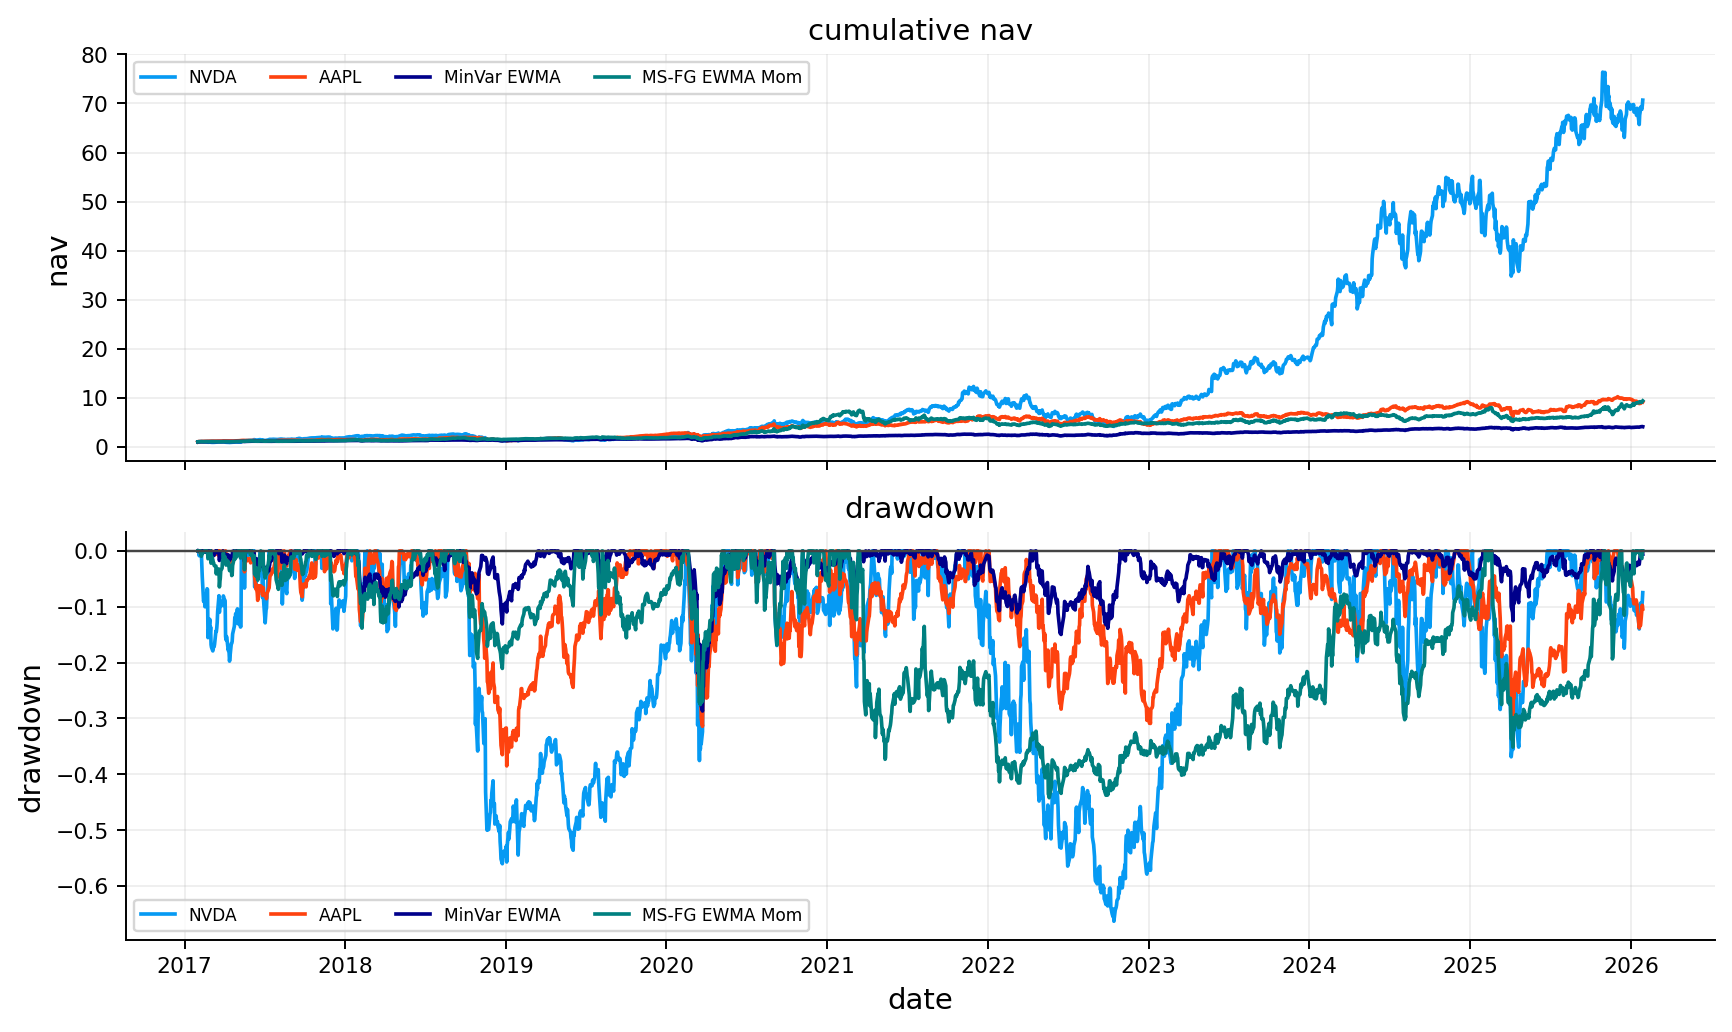

In [8]:
def dd_series(r):
    nav = nav_series(r)
    return nav / nav.cummax() - 1.0

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for name, r in obj.items():
    nav = nav_series(r)
    ax[0].plot(nav.index, nav.values, color=obj_colors[name], label=name)

ax[0].set_title("cumulative nav")
ax[0].set_ylabel("nav")
ax[0].legend(ncol=4)

for name, r in obj.items():
    dd = dd_series(r)
    ax[1].plot(dd.index, dd.values, color=obj_colors[name], label=name)

ax[1].axhline(0.0, color="#444", lw=1)
ax[1].set_title("drawdown")
ax[1].set_ylabel("drawdown")
ax[1].set_xlabel("date")
ax[1].legend(ncol=4)

plt.tight_layout()
plt.show()


### 6.2 drawdown episode

the drawdown time-series is great visually, but a user also needs **events**. we want to know exactly what were the worst drawdowns, when did they start, and how long did they last

an episode starts when drawdown becomes negative and ends when nav reaches the last peak (drawdown returns to $0$).

for each episode $k$ we record:
- start date $t_k^{start}$
- end date $t_k^{end}$
- depth: $\min_{t \in [t_k^{start}, t_k^{end}]} \text{dd}_t$
- duration: number of trading days in the episode


In [9]:
def drawdown_episodes(r):
    dd = dd_series(r)
    in_dd = False
    start_i = None
    out = []
    for i, v in enumerate(dd.values):
        if v < 0 and not in_dd:
            in_dd = True
            start_i = i
        if v == 0 and in_dd:
            end_i = i
            seg = dd.iloc[start_i:end_i]
            out.append((seg.index[0], seg.index[-1], float(seg.min()), int(len(seg))))
            in_dd = False
    if in_dd:
        seg = dd.iloc[start_i:]
        out.append((seg.index[0], seg.index[-1], float(seg.min()), int(len(seg))))
    return pd.DataFrame(out, columns=["start", "end", "depth", "duration"])


def avg_recovery_time(r):
    nav = nav_series(r)
    peak = nav.cummax()
    dd = nav / peak - 1
    rec_times = []
    in_dd = False
    t0 = None
    for i, v in enumerate(dd.values):
        if v < 0 and not in_dd:
            in_dd = True
            t0 = i
        if v == 0 and in_dd:
            rec_times.append(i - t0)
            in_dd = False
    return float(np.mean(rec_times)) if len(rec_times) else np.nan

dd_rows = []

for name, r in obj.items():
    x = pd.Series(r).dropna()
    dd = dd_series(x)

    ep = drawdown_episodes(x)
    longest_dd_days = int(ep["duration"].max()) if len(ep) else 0

    dd_rows.append({
        "object": name,
        "max_dd": float(dd.min()) if len(dd) else np.nan,
        "longest_dd_days": longest_dd_days,
        "avg_recovery_days": avg_recovery_time(x),
    })

dd_summary_tbl = pd.DataFrame(dd_rows).set_index("object").sort_index()
display(dd_summary_tbl.round(4))


,max_dd,longest_dd_days,avg_recovery_days
object,,,
AAPL,-0.3852,354,21.2234
MS-FG EWMA Mom,-0.4422,977,25.3415
MinVar EWMA,-0.2868,153,12.4774
NVDA,-0.6634,373,18.4019


In [10]:
episodes_rows = []

for name, r in obj.items():
    ep = drawdown_episodes(r).sort_values("depth")
    ep = ep.head(2).copy()
    ep.insert(0, "object", name)
    episodes_rows.append(ep)

episodes_tbl = pd.concat(episodes_rows, axis=0).reset_index(drop=True)
display(episodes_tbl)


,object,start,end,depth,duration
0,NVDA,2021-11-30,2023-05-24,-0.663351,373
1,NVDA,2018-10-02,2020-02-13,-0.560400,344
2,AAPL,2018-10-04,2019-10-09,-0.385177,255
3,AAPL,2024-12-27,2025-10-17,-0.333607,202
4,MinVar EWMA,2020-02-19,2020-05-28,-0.286807,70
5,MinVar EWMA,2022-04-21,2022-10-27,-0.149735,132
6,MS-FG EWMA Mom,2021-03-16,2025-02-03,-0.442167,977
7,MS-FG EWMA Mom,2025-02-19,2025-10-30,-0.351537,177


From the plot, we have the most drawdown in Nvidia. it means in around 2022 we reached our peak in nvidia and then it came down around 66% in 2022 before going up and reaching it's last peak again. this is the part that makes keeping nvidia stocks hard. you would have earned a lot of money from Nvidia **Only if** you kept it through the 50-60% loss in 2019 and 2022. 
Apple seems to have better performance than maxsharpe in drawdown. and MinVar EWMA has the most stable performance and the least max drawdown. below we get to more details about drawdown.

looks like MaxSharpe diversification isn't as good for reducing drawdown and negative effects of crashes like covid, but in some times like 2019 that both stocks have huge drawdown that can be a market effect, it doesn't have that much drawdown.

---

## 7) Value-at-risk (VaR) and expected shortfall (ES or CVaR)

We analyzed tail and distribution of objects for risk and average worst days to answer On bad days, how large can losses get and how severe are losses once we enter the tail

If daily simple returns be $r_t$ ($r_t=-0.02$ means a $-2\%$ return in one day).  
We choose a tail probability $\alpha$ (common one is $\alpha=0.05$ for the **worst 5%** of days).


### 7.1 left-tail quantile

We define the left-tail quantile $q_\alpha$ of the return distribution as the threshold such that only an $\alpha$ fraction of observations fall below it:

$$
P(r \le q_\alpha(r)) = \alpha.
$$

Because this is the **left** tail, $q_\alpha(r)$ is typically **negative** (a loss).  
Risk reports often present tail risk as a **positive loss magnitude** for readability.


### 7.2 value-at-risk (VaR)

VaR is a threshold loss:

Using the quantile definition:

$$
\text{VaR}_\alpha = -q_\alpha(r).
$$

For example if $\alpha=0.05$
- If $\text{VaR}_{0.05}=2.1\%$, then on **95%** of days the loss is **no worse than 2.1%**.
- On the **worst 5%** of days, losses are **worse than 2.1%**. 
- This means we should except this asset to have more than 2.1% loss in the worst 5% of days. It's rare but it happens and it's importnant to know how much loss we except as a measure of risk.

The problem is that VaR tells you where the tail begins, but not how large losses are inside the tail.

---

### 7.3 expected shortfall (ES) / conditional VaR

Expected Shortfall (ES) measures tail severity by averaging losses beyond VaR:

$$
\text{ES}_\alpha = -E\!\left[r \mid r \le q_\alpha(r)\right].
$$

If $\alpha=0.05$:
- If $\text{ES}_{0.05}=3.4\%$, then among the **worst 5%** of days, the **average loss** is **3.4%**.

- VaR is a cutoff (one quantile). It tells us what the best return in the worst 5% losses are.
- ES is a severity measure. it tells us the average loss we should except in the worst 5% of losses.

ES is always bigger (or maybe equal) than VaR. If ES is much larger than VaR, the distribution has a heavier left tail (more extreme losses after crossing the threshold).

---

## 7.4 estimation methods used in this report

We report a comparison table for $\alpha=0.05$ using two other estimators:
1) **Cornish–Fisher (CF) adjusted quantiles**
2) **Filtered historical simulation (FHS) with EWMA volatility**

A single VaR/ES estimate can be fragile, so comparing multiple approaches helps users see a plausible range.

### 7.4.1 cornish–fisher (CF): non-normal quantile correction using skewness and kurtosis

CF starts from the **normal** quantile and adjusts it to reflect **skewness** and **fat tails**.

### (a) standardize returns

From a sample window, estimate:
- $\mu$ (sample mean) and $\sigma$ (sample standard deviation)
- standardized values $x_t = (r_t-\mu)/\sigma$

Compute standardized **skewness** $S$ and **excess kurtosis** $K$:

$$
S = E[X^3] \approx \frac{1}{T}\sum_{t=1}^T x_t^3,
\qquad
K = E[X^4]-3 \approx \frac{1}{T}\sum_{t=1}^T x_t^4 - 3.
$$

### (b) adjust the normal quantile
We set $z = z_\alpha = \Phi^{-1}(\alpha)$ as the standard normal $\alpha$-quantile.

A commonly used CF expansion is:

$$
z_{\text{CF}} =
z
+\frac{1}{6}(z^2-1)S
+\frac{1}{24}(z^3-3z)K
-\frac{1}{36}(2z^3-5z)S^2.
$$

Then the CF return quantile is:

$$
q_\alpha^{\text{CF}}(r) = \mu + \sigma z_{\text{CF}}.
$$

So the CF VaR is:

$$
\text{VaR}_\alpha^{\text{CF}} = -\left(\mu + \sigma z_{\text{CF}}\right).
$$

### (c) Cornish Fisher ES
CF primarily provides a corrected **quantile** (VaR).  
A common practical ES approximation is to compute ES empirically using the CF cutoff:

We first compute $q_\alpha^{\text{CF}}(r)$  
and then average sample returns below that cutoff:

$$
\text{ES}_\alpha^{\text{CF}}
\approx
-\frac{1}{|\mathcal{T}_\alpha^{\text{CF}}|}\sum_{t\in \mathcal{T}_\alpha^{\text{CF}}} r_t,
\qquad
\mathcal{T}_\alpha^{\text{CF}}=\{t:r_t\le q_\alpha^{\text{CF}}(r)\}.
$$

This model incorporates skewness/kurtosis (non-normality), but approximation can be unstable if skew/kurt estimates are noisy or tails are extreme

negative skew ($S<0$) usually worsens left-tail quantiles
positive excess kurtosis ($K>0$) deepens tail risk vs normal

---

### 7.4.2 historical simulation (HS)

HS is the most direct approach: it treats the observed return window as the empirical distribution.

The HS quantile is the empirical quantile

$$
q_\alpha^{\text{HS}}(r) = \text{EmpQuantile}_\alpha(\{r_t\}_{t=1}^T),
$$

so

$$
\text{VaR}_\alpha^{\text{HS}} = -q_\alpha^{\text{HS}}(r).
$$

And HS ES is:

$$
\text{ES}_\alpha^{\text{HS}}
= -E[r \mid r \le q_\alpha^{\text{HS}}(r)]
\approx
-\frac{1}{|\mathcal{T}_\alpha|}\sum_{t\in \mathcal{T}_\alpha} r_t.
$$

This moodel can be sensitive to the chosen window, and to regime changes

---

### 7.4.3 filtered historical simulation (FHS): volatility-adjusted tail estimation

HS assumes the return distribution is stable across time.  
In reality, returns show **volatility clustering** (calm vs turbulent periods).  
With FHS we address this by filtering out time-varying volatility before sampling the tail.

### EWMA volatility filter
There are many ways for filtering. In this project we use this approach:

We estimate conditional variance using EWMA:

$$
\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2,
$$

where $\lambda\in(0,1)$ is the decay parameter (we set as $\lambda\approx 0.94$).


### FHS expected shortfall

$$
\text{ES}_{\alpha,t+1}^{\text{FHS}} =
-\left(\mu_{t+1} + \sigma_{t+1} \, E[\varepsilon \mid \varepsilon \le q_\alpha(\varepsilon)]\right).
$$

Empirically:

$$
E[\varepsilon \mid \varepsilon \le q_\alpha(\varepsilon)]
\approx
\frac{1}{|\mathcal{T}_\alpha^\varepsilon|}
\sum_{t\in \mathcal{T}_\alpha^\varepsilon}\varepsilon_t.
$$

So:

$$
\text{ES}_{\alpha,t+1}^{\text{FHS}}
\approx
-\left(\mu_{t+1} + \sigma_{t+1}
\frac{1}{|\mathcal{T}_\alpha^\varepsilon|}
\sum_{t\in \mathcal{T}_alpha^\varepsilon}\varepsilon_t\right).
$$

This model adapts to volatility regimes and has better behavior when today’s volatility differs from the historical average of volatility, but it depends what model we use and can be different 

In [11]:
def hist_var_es(r, alpha=0.05):
    x = pd.Series(r).dropna()
    q = x.quantile(alpha)
    es = x[x <= q].mean()
    return -float(q), -float(es)

def cf_var_es(r, alpha=0.05, n_sim=70000, seed=7):
    x = pd.Series(r).dropna()
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    if sd <= 1e-12:
        return np.nan, np.nan
    s = float(x.skew())
    k = float(x.kurt())
    z = normaldist().inv_cdf(alpha)
    zc = z + (z**2 - 1)*s/6 + (z**3 - 3*z)*k/24 - (2*z**3 - 5*z)*(s**2)/36
    q = mu + sd * zc

    rng = np.random.default_rng(seed)
    zs = rng.standard_normal(n_sim)
    za = zs + (zs**2 - 1)*s/6 + (zs**3 - 3*zs)*k/24 - (2*zs**3 - 5*zs)*(s**2)/36
    rs = mu + sd * za
    es = rs[rs <= q].mean()
    return -float(q), -float(es)

def fhs_var_es(r, alpha=0.05, lam=0.94):
    x = pd.Series(r).dropna().astype(float)
    mu = float(x.mean())
    e = x - mu

    sig = np.zeros(len(e), dtype=float)
    sig[0] = max(float(e.std(ddof=1)), 1e-6)
    for t in range(1, len(e)):
        sig[t] = np.sqrt(lam * sig[t - 1]**2 + (1 - lam) * e.iloc[t - 1]**2)

    z = e.to_numpy() / np.where(sig > 1e-12, sig, np.nan)
    z = z[np.isfinite(z)]
    qz = np.quantile(z, alpha)
    ez = z[z <= qz].mean()

    sn = sig[-1]
    return float(-(mu + sn * qz)), float(-(mu + sn * ez))


var_rows = []
for name, r in obj.items():
    x = pd.Series(r).dropna()
    hv, he = hist_var_es(x, 0.05)
    cv, ce = cf_var_es(x, 0.05)
    fv, fe = fhs_var_es(x, 0.05)
    var_rows.append({
        "object": name,
        "hist_var5": hv,
        "hist_es5": he,
        "cf_var5": cv,
        "cf_es5": ce,
        "fhs_var5": fv,
        "fhs_es5": fe,
    })

var_tbl = pd.DataFrame(var_rows).set_index("object").sort_index()
display(var_tbl.round(4))


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
AAPL,0.0287,0.0425,0.0261,0.0547,0.0205,0.0299
MS-FG EWMA Mom,0.0293,0.0437,0.0281,0.0544,0.0367,0.0512
MinVar EWMA,0.0133,0.0218,0.0124,0.0490,0.0086,0.0132
NVDA,0.0466,0.0691,0.0446,0.0839,0.0286,0.0409


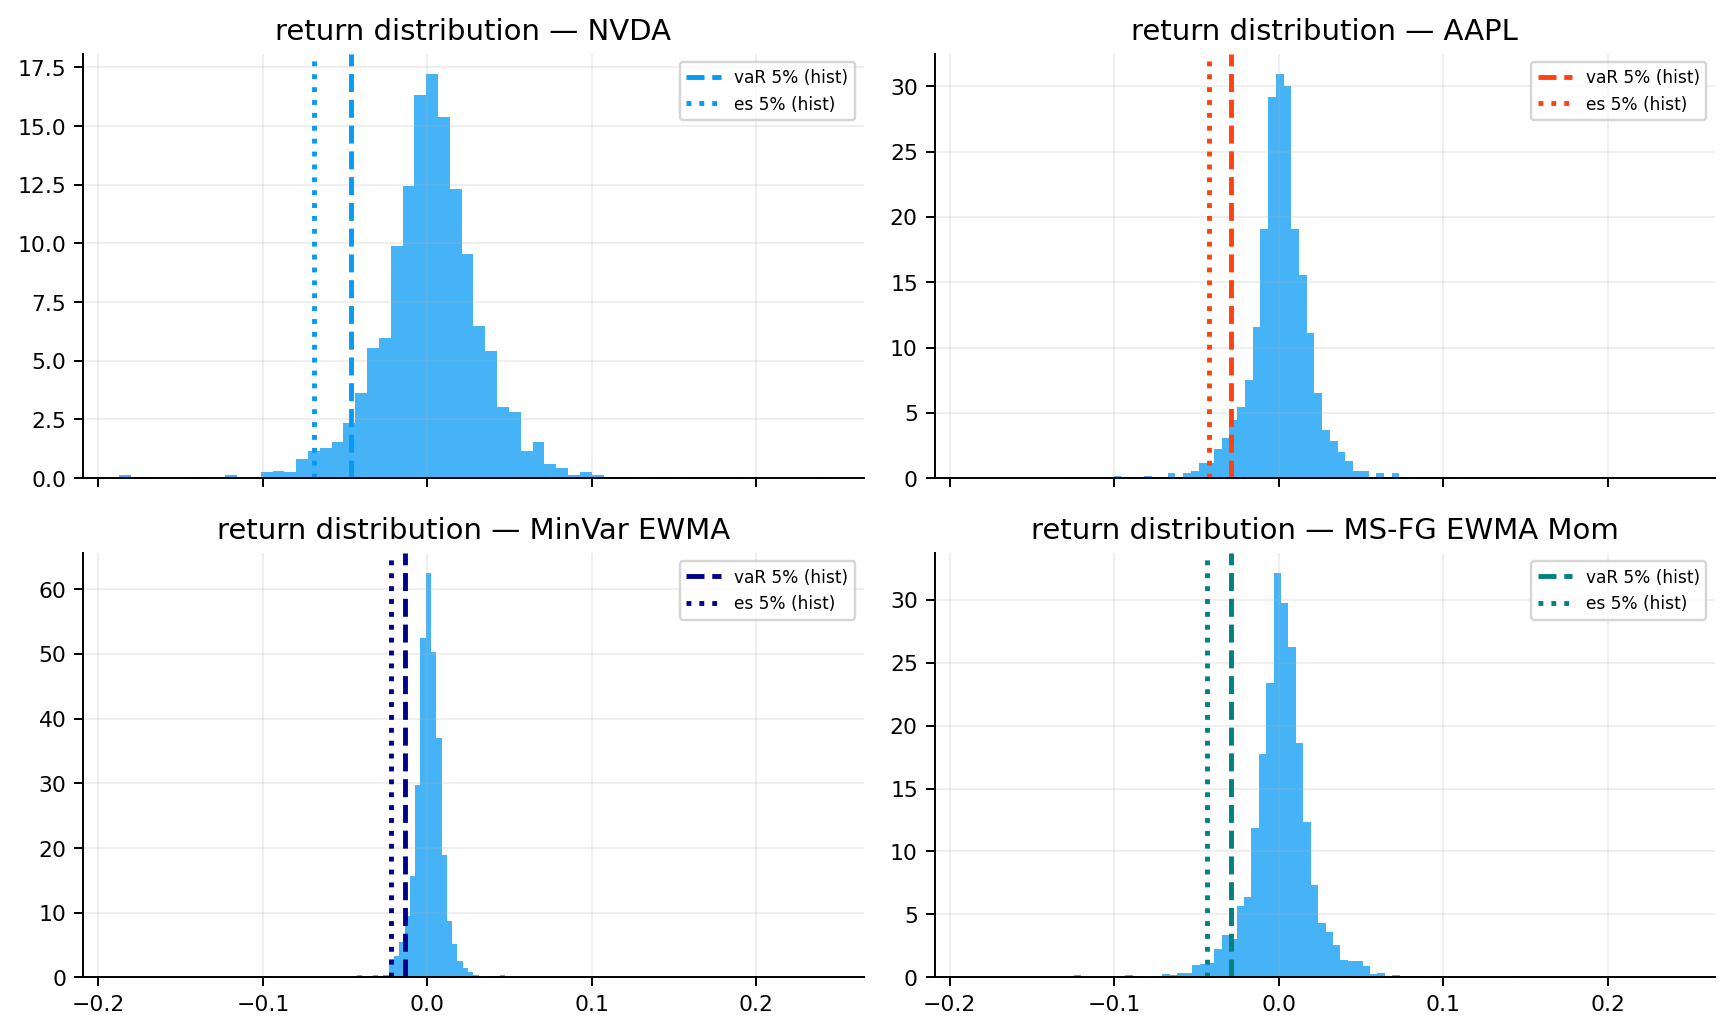

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.ravel()

for i, (name, r) in enumerate(obj.items()):
    ax = axes[i]
    x = pd.Series(r).dropna()

    hv, he = hist_var_es(x, 0.05)
    ax.hist(x.values, bins=60, density=True, alpha=0.75)
    ax.axvline(-hv, lw=2.0, ls="--", color=obj_colors[name], label="vaR 5% (hist)")
    ax.axvline(-he, lw=2.0, ls=":", color=obj_colors[name], label="es 5% (hist)")
    ax.set_title(f"return distribution — {name}")
    ax.legend()

plt.tight_layout()
plt.show()


We can see from the table that models give us different results. If we only cosider Historic VaR, We might think that Apple is more risky than MaxSharpe, but other models show otherwise. again we see that the loss of Nvidia is the most in most of the models. and MinVar EWMA has controlled the risk the best way.

## 8) VaR backtesting (Model risk)

A VaR model makes a testable promise. For a 5% VaR, Losses should exceed the VaR threshold about 5% of the time.

Backtesting checks whether that promise holds in realized data.


### 8.1 breach indicator (what counts as a VaR failure)

A VaR breach occurs when the realized return is worse than the VaR threshold:

$$
r_t < -\text{VaR}_{\alpha,t}.
$$

We define the breach indicator:

$$
b_t = \mathbb{1}\!\left[r_t < -\text{VaR}_{\alpha,t}\right],
$$

where $b_t=1$ means a breach happened, and $b_t=0$ otherwise.

We summarize breaches using:
- **breach count:** $x = \sum_{t=1}^n b_t$
- **breach rate:** $\hat p = x/n$
- **longest breach streak:** $\max$ number of consecutive $b_t=1$ (a simple clustering diagnostic)

If the VaR model is correct, we expect $\hat p \approx \alpha$ over a long sample.
If breaches happen in streaks, the model may be underreacting to volatility regime changes (clustering risk).

---

### 8.2 Kupiec test: unconditional coverage (frequency)

The **Kupiec (POF)** test checks whether breaches occur with the correct long-run frequency.

If we have:
- $n$ = number of test days
- $x$ = number of breaches
- $\hat p = x/n$ = observed breach rate
- $p = \alpha$ = model-implied breach probability (5%)

Kupiec’s likelihood ratio statistic is:

The log-likelihood under the null (correct coverage) is:

$$
\ell_0 = (n-x)\log(1-p) + x\log(p).
$$

The log-likelihood under the alternative (best-fitting rate) is:

$$
\ell_1 = (n-x)\log(1-\hat p) + x\log(\hat p).
$$

Kupiec’s likelihood-ratio statistic is:

$$
\text{LR}_{uc} = -2(\ell_0-\ell_1),
\qquad
\text{LR}_{uc}\sim \chi^2(1)\ \text{under }H_0.
$$

it means:
  - **large** $\text{LR}_{uc}$ (small p-value) means the breach frequency is wrong:
  - too many breaches means VaR is too small (underestimates risk)
  - too few breaches means VaR is too conservative

---

### 8.3 Christoffersen test: independence / clustering

Correct frequency alone is not enough, breaches should also be independent over time.  
If breaches have clustering, the VaR model may fail during volatility spikes or regime shifts. se we test independence

The Christoffersen independence test treats the breach sequence $b_t$ as a two-state process (0 = no breach, 1 = breach) and checks whether transitions depend on the previous day.

Count transitions:
- $n_{00}$: number of times $b_{t-1}=0 \to b_t=0$
- $n_{01}$: number of times $b_{t-1}=0 \to b_t=1$
- $n_{10}$: number of times $b_{t-1}=1 \to b_t=0$
- $n_{11}$: number of times $b_{t-1}=1 \to b_t=1$

Estimate transition probabilities:

$$
\pi_{01} = \frac{n_{01}}{n_{00}+n_{01}}, \qquad
\pi_{11} = \frac{n_{11}}{n_{10}+n_{11}}.
$$

If breaches are independent, the probability of a breach tomorrow does not depend on whether there was a breach today, so:

$$
H_0: \pi_{01} = \pi_{11}.
$$


Log-likelihood under independence:
$$
\ell_0 = (n_{00}+n_{10})\log(1-\pi) + (n_{01}+n_{11})\log(\pi).
$$

Log-likelihood under dependence (two transition probabilities):
$$
\ell_1 =
n_{00}\log(1-\pi_{01}) + n_{01}\log(\pi_{01})
+
n_{10}\log(1-\pi_{11}) + n_{11}\log(\pi_{11}).
$$

The test statistic is:
$$
\text{LR}_{ind} = -2(\ell_0-\ell_1),
\qquad
\text{LR}_{ind}\sim \chi^2(1)\ \text{under }H_0.
$$

We define likelihoods:
- under independence (Bernoulli with constant probability $\hat p$):

$$
L_0 =
(1-\hat p)^{n_{00}+n_{10}}
\hat p^{n_{01}+n_{11}}
$$

- under first-order dependence (different transition probabilities):

$$
L_1 =
(1-\pi_{01})^{n_{00}}
\pi_{01}^{n_{01}}
(1-\pi_{11})^{n_{10}}
\pi_{11}^{n_{11}}.
$$

Christoffersen’s likelihood ratio statistic:

$$
\text{LR}_{ind} = -2\ln\left(\frac{L_0}{L_1}\right)
\qquad
\text{LR}_{ind}\sim \chi^2(1) \text{ under } H_0.
$$

small p-value means breaches are clustered (depend on previous breach status)
clustering is a common sign that the VaR model is not adapting fast enough to changing volatility


We report p-values for:

- **Kupiec (coverage)**: is breach frequency close to $\alpha$
- **Christoffersen (independence)**: are breaches unclustered

A well-specified VaR model typically has:
- coverage p-value not too small (frequency is plausible)
- independence p-value not too small (no strong clustering)

Small p-values suggest misspecification: wrong level of risk, volatility dynamics not captured, or regime changes.

In [13]:
alpha = 0.05
lookback = 252
bt_methods = ["hist", "cf", "fhs"]


def chi2_sf(x, df):
    return float(chi2.sf(x, df))


def rolling_var_quantile(r, alpha=0.05, lookback=252, method="hist", cf_n_sim=15000, cf_seed=7, fhs_lambda=0.94):
    x = pd.Series(r).dropna().astype(float)
    if len(x) < lookback + 1:
        return pd.Series(dtype=float)

    m = str(method).strip().lower()
    q = pd.Series(np.nan, index=x.index, dtype=float)
    for i in range(lookback, len(x)):
        w = x.iloc[i - lookback:i]
        if m == "hist":
            v, _ = hist_var_es(w, alpha=alpha)
        elif m == "cf":
            v, _ = cf_var_es(w, alpha=alpha, n_sim=cf_n_sim, seed=cf_seed)
        elif m == "fhs":
            v, _ = fhs_var_es(w, alpha=alpha, lam=fhs_lambda)
        else:
            raise ValueError("method must be one of {'hist', 'cf', 'fhs'}")
        q.iloc[i] = -float(v) if np.isfinite(v) else np.nan
    return q


def longest_true_streak(mask):
    m = np.asarray(mask, dtype=bool)
    best = 0
    cur = 0
    for v in m:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return int(best)


def kupiec_test(breach, alpha=0.05):
    b = np.asarray(breach, dtype=bool)
    n = int(b.size)
    x = int(b.sum())
    if n <= 0:
        return np.nan, np.nan

    p = float(alpha)
    eps = 1e-12
    ph = x / n
    ph = min(max(ph, eps), 1.0 - eps)

    ll0 = (n - x) * np.log1p(-p) + x * np.log(p)
    ll1 = (n - x) * np.log1p(-ph) + x * np.log(ph)

    lr = float(-2.0 * (ll0 - ll1))
    pv = chi2_sf(lr, df=1)
    return lr, pv


def christoffersen_independence(breach):
    b = np.asarray(breach, dtype=int)
    if b.size < 3:
        return np.nan, np.nan

    b0 = b[:-1]
    b1 = b[1:]

    n00 = int(((b0 == 0) & (b1 == 0)).sum())
    n01 = int(((b0 == 0) & (b1 == 1)).sum())
    n10 = int(((b0 == 1) & (b1 == 0)).sum())
    n11 = int(((b0 == 1) & (b1 == 1)).sum())

    eps = 1e-12
    pi01 = n01 / (n00 + n01 + eps)
    pi11 = n11 / (n10 + n11 + eps)
    pi = (n01 + n11) / (n00 + n01 + n10 + n11 + eps)

    pi01 = min(max(pi01, eps), 1.0 - eps)
    pi11 = min(max(pi11, eps), 1.0 - eps)
    pi = min(max(pi, eps), 1.0 - eps)

    ll0 = (n00 + n10) * np.log1p(-pi) + (n01 + n11) * np.log(pi)
    ll1 = (
        n00 * np.log1p(-pi01) + n01 * np.log(pi01)
        + n10 * np.log1p(-pi11) + n11 * np.log(pi11)
    )

    lr = float(-2.0 * (ll0 - ll1))
    pv = chi2_sf(lr, df=1)
    return lr, pv


def quantile_loss(ret, q, alpha=0.05):
    z = pd.concat([pd.Series(ret).rename("ret"), pd.Series(q).rename("q")], axis=1).dropna()
    if len(z) == 0:
        return np.nan
    e = z["ret"] - z["q"]
    loss = e * (alpha - (e < 0).astype(float))
    return float(loss.mean())


def breach_stats(r, alpha=0.05, lookback=252, method="hist"):
    x = pd.Series(r).dropna().astype(float)
    q = rolling_var_quantile(x, alpha=alpha, lookback=lookback, method=method)
    z = pd.concat([x.rename("ret"), q.rename("var_q")], axis=1).dropna()


    br = z["ret"] < z["var_q"]
    lr_uc, pv_uc = kupiec_test(br, alpha=alpha)
    lr_ind, pv_ind = christoffersen_independence(br)

    idx = np.flatnonzero(br.to_numpy())
    gaps = np.diff(idx) if idx.size >= 2 else np.array([])

    rate = float(br.mean())
    return {
        "series": z,
        "breach": br,
        "count": int(br.sum()),
        "rate": rate,
        "coverage_error": float(rate - alpha),
        "abs_coverage_error": float(abs(rate - alpha)),
        "longest_streak": longest_true_streak(br.to_numpy()),
        "avg_gap": float(np.mean(gaps)) if gaps.size else np.nan,
        "med_gap": float(np.median(gaps)) if gaps.size else np.nan,
        "kupiec_lr": lr_uc,
        "kupiec_p": pv_uc,
        "christ_lr": lr_ind,
        "christ_p": pv_ind,
        "quantile_loss": quantile_loss(z["ret"], z["var_q"], alpha=alpha),
    }


rows = []
stats_map = {}
for name, r in obj.items():
    stats_map[name] = {}
    for m in bt_methods:
        st = breach_stats(r, alpha=alpha, lookback=lookback, method=m)
        stats_map[name][m] = st
        rows.append({
            "object": name,
            "method": m,
            "breach_count": st["count"],
            "breach_rate": st["rate"],
            "coverage_error": st["coverage_error"],
            "abs_coverage_error": st["abs_coverage_error"],
            "longest_breach_streak": st["longest_streak"],
            "avg_gap_days": st["avg_gap"],
            "kupiec_p": st["kupiec_p"],
            "christoffersen_p": st["christ_p"],
            "quantile_loss": st["quantile_loss"],
        })

var_bt_tbl = pd.DataFrame(rows).set_index(["object", "method"]).sort_index()
var_bt_tbl["accuracy_rank"] = np.nan
var_bt_tbl["accuracy_score"] = np.nan
var_bt_tbl["is_best"] = False

for name, g in var_bt_tbl.groupby(level=0, sort=False):
    abs_cov = g["abs_coverage_error"]
    qloss = g["quantile_loss"]
    kup = g["kupiec_p"].fillna(-np.inf)
    chrp = g["christoffersen_p"].fillna(-np.inf)

    r_abs = abs_cov.rank(ascending=True, method="min", na_option="bottom")
    r_ql = qloss.rank(ascending=True, method="min", na_option="bottom")
    r_k = kup.rank(ascending=False, method="min")
    r_c = chrp.rank(ascending=False, method="min")

    rank_sum = (r_abs + r_ql + r_k + r_c).astype(float)
    acc_rank = rank_sum.rank(ascending=True, method="min")
    acc_score = 1.0 / (1.0 + rank_sum)

    var_bt_tbl.loc[g.index, "accuracy_rank"] = acc_rank.to_numpy(dtype=float)
    var_bt_tbl.loc[g.index, "accuracy_score"] = acc_score.to_numpy(dtype=float)

    best_idx = pd.DataFrame(
        {
            "rank_sum": rank_sum,
            "abs_cov": abs_cov,
            "qloss": qloss,
            "kupiec": kup,
            "christ": chrp,
            "method_name": [idx[1] for idx in g.index],
        },
        index=g.index,
    ).sort_values(
        by=["rank_sum", "abs_cov", "qloss", "kupiec", "christ", "method_name"],
        ascending=[True, True, True, False, False, True],
    ).index[0]
    var_bt_tbl.loc[best_idx, "is_best"] = True


display(var_bt_tbl.round(4))

best_method_map = {obj_name: method for obj_name, method in var_bt_tbl[var_bt_tbl["is_best"]].index}
breach_map = {}
for name, r in obj.items():
    m = best_method_map.get(name, "hist")
    st = stats_map[name][m]
    st["method"] = m
    breach_map[name] = st

var_bt_tbl_pdf = var_bt_tbl.rename(columns={
    "breach_count": "breaches",
    "breach_rate": "rate",
    "longest_breach_streak": "max_streak",
    "avg_gap_days": "avg_gap_d",
    "kupiec_p": "kupiec_p",
    "christoffersen_p": "christoffersen_p",
})


breach_count  breach_rate  coverage_error  \
object         method                                              
AAPL           cf               135       0.0672          0.0172   
               fhs              105       0.0523          0.0023   
               hist             124       0.0617          0.0117   
MS-FG EWMA Mom cf               117       0.0582          0.0082   
               fhs              110       0.0548          0.0048   
               hist             118       0.0587          0.0087   
MinVar EWMA    cf               103       0.0513          0.0013   
               fhs              108       0.0538          0.0038   
               hist             116       0.0577          0.0077   
NVDA           cf               170       0.0846          0.0346   
               fhs              116       0.0577          0.0077   
               hist             126       0.0627          0.0127   

                       abs_coverage_error  longest_breach_streak  \
object         method                                              
AAPL           cf                  0.0172                      4   
               fhs                 0.0023                      3   
               hist                0.0117                      4   
MS-FG EWMA Mom cf                  0.0082                      3   
               fhs                 0.0048                      3   
               hist                0.0087                      3   
MinVar EWMA    cf                  0.0013                      3   
               fhs                 0.0038                      2   
               hist                0.0077                      3   
NVDA           cf                  0.0346                      3   
               fhs                 0.0077                      2   
               hist                0.0127                      3   

                       avg_gap_days  kupiec_p  christoffersen_p  \
object         method                                             
AAPL           cf           14.9254    0.0008            0.0002   
               fhs          19.2308    0.6437            0.0011   
               hist         16.2602    0.0198            0.0002   
MS-FG EWMA Mom cf           17.0603    0.0983            0.0233   
               fhs          17.9908    0.3353            0.1139   
               hist         16.9145    0.0801            0.0109   
MinVar EWMA    cf           19.0686    0.7949            0.0000   
               fhs          18.5794    0.4449            0.0919   
               hist         16.9217    0.1199            0.0000   
NVDA           cf           11.8343    0.0000            0.0009   
               fhs          17.3913    0.1199            0.2037   
               hist         15.9920    0.0117            0.0344   

                       quantile_loss  accuracy_rank  accuracy_score  is_best  
object         method                                                         
AAPL           cf             0.0023            2.0          0.0909    False  
               fhs            0.0022            1.0          0.2000     True  
               hist           0.0023            2.0          0.0909    False  
MS-FG EWMA Mom cf             0.0023            2.0          0.1000    False  
               fhs            0.0021            1.0          0.2000     True  
               hist           0.0023            3.0          0.0833    False  
MinVar EWMA    cf             0.0012            2.0          0.1250    False  
               fhs            0.0011            1.0          0.1429     True  
               hist           0.0012            3.0          0.0833    False  
NVDA           cf             0.0039            3.0          0.0769    False  
               fhs            0.0035            1.0          0.2000     True  
               hist           0.0037            2.0          0.1111    False

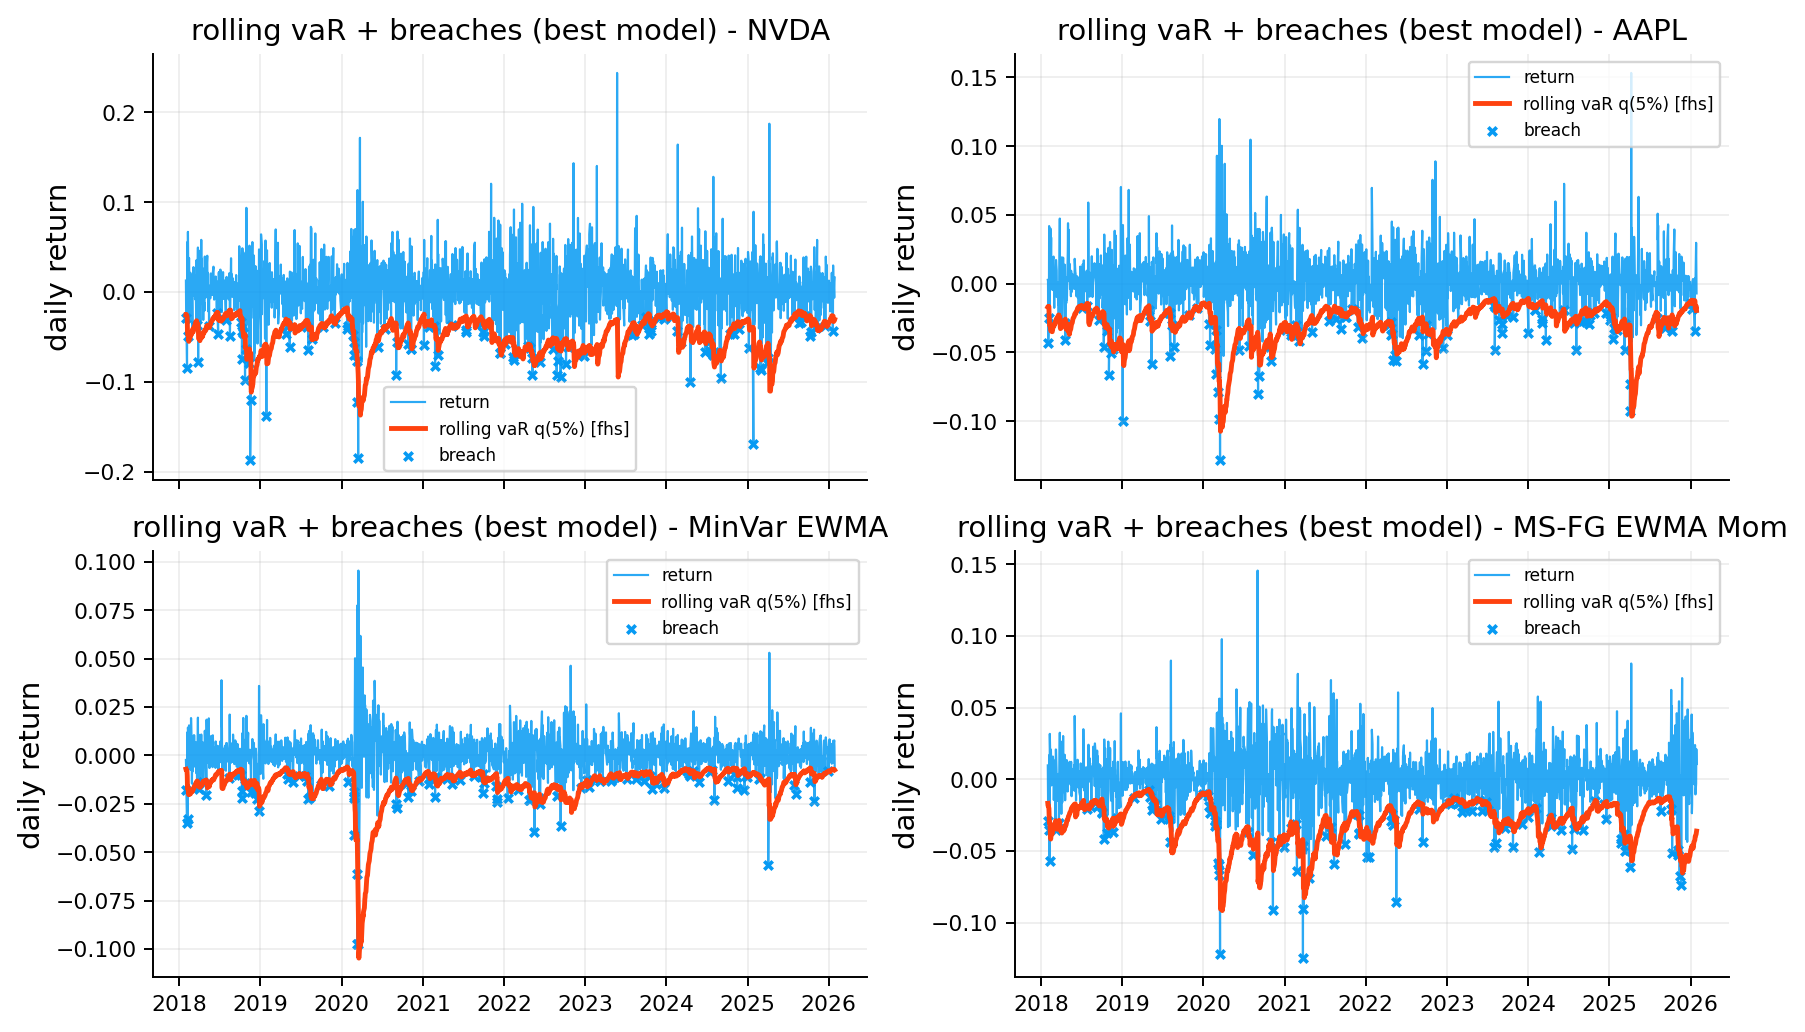

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)
axes = axes.ravel()

for i, name in enumerate(obj.keys()):
    ax = axes[i]
    z = breach_map[name]["series"]
    br = breach_map[name]["breach"]
    m = breach_map[name].get("method", "hist")

    ax.plot(z.index, z["ret"].values, lw=0.9, alpha=0.85, label="return")
    ax.plot(z.index, z["var_q"].values, lw=2.0, label=f"rolling vaR q(5%) [{m}]")
    ax.scatter(z.index[br], z.loc[br, "ret"].values, s=12, marker="x", label="breach")

    ax.set_title(f"rolling vaR + breaches (best model) - {name}")
    ax.set_ylabel("daily return")
    ax.legend()

plt.tight_layout()
plt.show()


**FHS is the most robust method**. It delivers accurate unconditional coverage across all tested objects, consistently low quantile loss, and is statistically the best choice 75% of the time. Its use of volatility filtering makes it a lot more adaptive than simple Historical Simulation and less assumption dependent than Cornish-Fisher.

**All models failed independence tests** (except NVDA with FHS). Even the best model produces clustered violations in most portfolios. Relying solely on an unconditional coverage test would be dangerous. a conditional coverage failure means large losses are likely to be followed by more large losses, potentially blowing through capital buffers.

**Cornish-Fisher is fragile** but works better for a stable model like MinVar EWMA. Its extreme underprediction on NVDA (8.5% breach rate) shows it can misbehave badly when the return distribution is far from normal (NVDA’s high volatility and potential skewness). It only performs good for the well diversified MinVar EWMA portfolio where non normality is milder.

**Simple Historical Simulation is a decent fallback**. It was never the worst and never the best. It lacks the adaptiveness of FHS.

---

## 9) historical stress windows (scenario slices)

instead of hypothetical shocks, we can look at real historical periods like covid crash and see how did each object behave during that exact window, what was the max drawdown inside the window and how much loss we would take in that period if we held these objects.

for this project we use three periods:
- the 4th quarter of 2018
- the Covid crash in the first months of 2020
- inflation of 2022


In [15]:
stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "2020_covid": ("2020-02-20", "2020-04-30"),
    "2022_inflation": ("2022-01-03", "2022-10-31"),
}

stress_rows = []
for wname, (s, e) in stress_windows.items():
    s = pd.Timestamp(s)
    e = pd.Timestamp(e)
    for name, r in obj.items():
        x = pd.Series(r).loc[(pd.Series(r).index >= s) & (pd.Series(r).index <= e)].dropna()
        if len(x) == 0:
            continue
        nav = nav_series(x)
        dd = nav / nav.cummax() - 1
        worst_week = x.resample("W-FRI").sum().min() if len(x) > 5 else np.nan
        stress_rows.append({
            "window": wname,
            "object": name,
            "cum_return": float(nav.iloc[-1] - 1),
            "max_dd": float(dd.min()),
            "worst_day": float(x.min()),
            "worst_week": float(worst_week) if np.isfinite(worst_week) else np.nan,
        })

stress_tbl = pd.DataFrame(stress_rows).sort_values(["window", "object"]).reset_index(drop=True)


In [16]:
display(stress_tbl.round(4))

,window,object,cum_return,max_dd,worst_day,worst_week
0,2018_q4,AAPL,-0.2988,-0.3651,-0.0663,-0.1140
1,2018_q4,MS-FG EWMA Mom,-0.1658,-0.2033,-0.0416,-0.0720
2,2018_q4,MinVar EWMA,-0.0799,-0.1237,-0.0287,-0.0572
3,2018_q4,NVDA,-0.5245,-0.5604,-0.1875,-0.1988
4,2020_covid,AAPL,-0.0921,-0.2995,-0.1286,-0.1803
5,2020_covid,MS-FG EWMA Mom,-0.0523,-0.2735,-0.1221,-0.1193
6,2020_covid,MinVar EWMA,-0.0704,-0.2819,-0.0974,-0.1391
7,2020_covid,NVDA,-0.0707,-0.3634,-0.1846,-0.1286
8,2022_inflation,AAPL,-0.1329,-0.2834,-0.0587,-0.0830
9,2022_inflation,MS-FG EWMA Mom,-0.1814,-0.2824,-0.0857,-0.1039


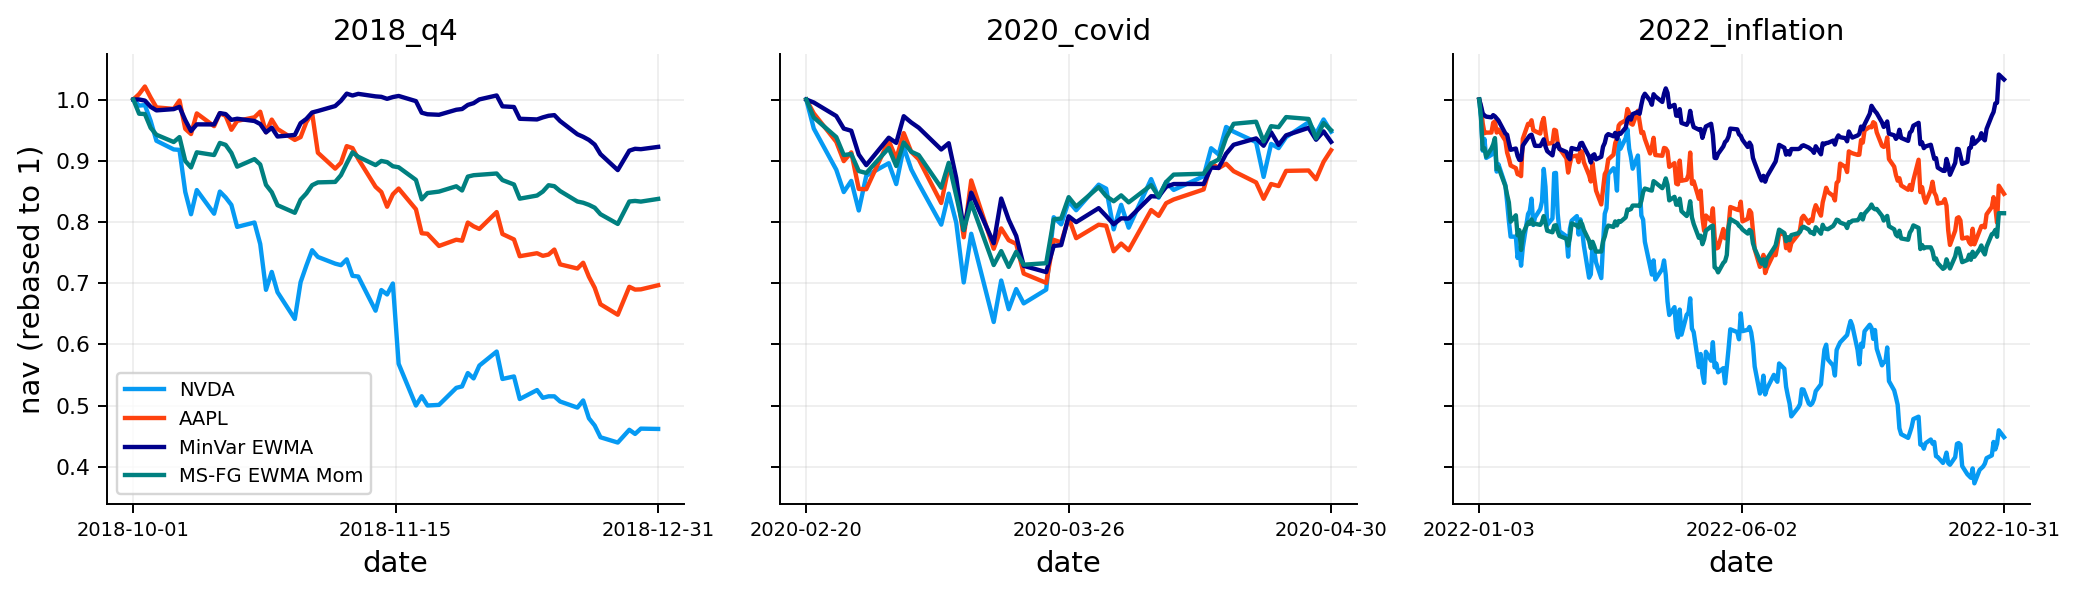

In [17]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, len(stress_windows), figsize=(12, 3.5), sharey=True)

if len(stress_windows) == 1:
    axes = [axes]

for ax, (wname, (s, e)) in zip(axes, stress_windows.items()):
    s = pd.Timestamp(s)
    e = pd.Timestamp(e)
    mid = s + (e - s) / 2

    for name, r in obj.items():
        x = pd.Series(r).loc[(pd.Series(r).index >= s) & (pd.Series(r).index <= e)].dropna()
        if len(x) == 0:
            continue
        nav = nav_series(x)
        nav = nav / nav.iloc[0]
        ax.plot(nav.index, nav.values, lw=1.8, color=obj_colors[name], label=name)

    ax.set_title(wname)
    ax.set_xlabel("date")
    ax.grid(True, alpha=0.2)
    ticks = [s, mid, e]
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", labelrotation=0, labelsize=8)

axes[0].set_ylabel("nav (rebased to 1)")
axes[0].legend(ncol=1, fontsize=8)
plt.tight_layout()
plt.show()


When it comes to these periods, companies get effected directly and these events cause more drops and negative returns in stock prices and diversification seems to be the safer choice. this is one of the rare measures that we can see MaxSharpe performed better than apple.

---

## 10) CAPM / market factor decomposition

capm explains returns using a single market factor. here, we use spy data that we imported as our market proxy (S&P 500 ETF).

With this model we assume that any return more than risk free rate of our objects can be explained by market returns and market risk effects on these returns. 

From this relationship we can interpret how much each object's risk is dependent to market risk and we can see if each object has any returns more than market returns that can't be explained with market risk.

### 10.1 capm model (daily)

using excess returns:

$$
r^{ex}_{j,t} = \alpha_j + \beta_j\, r^{ex}_{m,t} + \varepsilon_{j,t}
$$

where:
- $r^{ex}_{j,t} = r_{j,t} - r_{f,t}$ (excess return of the object)
- $r^{ex}_{m,t} = r_{m,t} - r_{f,t}$ (market = spy)
- $\alpha_j$ is “alpha” (average unexplained excess return)
- $\beta_j$ is market sensitivity
- $\varepsilon$ is the residual

### estimation (ols via sklearn)

OLS (ordinary least squares) is a model for minimizing the square of residuals between the prediction and the real data for fitting a linear regression on our data.

$$
\min_{\alpha,\beta} \sum_t \left(r^{ex}_{j,t} - \alpha - \beta r^{ex}_{m,t}\right)^2
$$

the fitted values are:

$$
\hat r^{ex}_{j,t} = \hat\alpha + \hat\beta r^{ex}_{m,t}
$$

and $r^2$ is:

$$
r^2 = 1 - \frac{\sum_t (r^{ex}_{j,t} - \hat r^{ex}_{j,t})^2}{\sum_t (r^{ex}_{j,t} - \bar r^{ex}_j)^2}
$$

### 10.2 Active risk vs benchmark (tracking error and information ratio)

We define active return as performance relative to the benchmark:

$$
a_t = r_t - m_t
$$

Then
Tracking error (annualized):

$$
TE = \sqrt{ann}\;\sigma(a_t)
$$

Information ratio (annualized):
$$
IR = \sqrt{ann}\;\frac{E[a_t]}{\sigma(a_t)}
$$

- high TE: we deviate a lot from the benchmark (high active risk)
- high IR: we’re rewarded well per unit of active risk


### 10.3 Up capture and down capture

These measure how the object behaves when the market is up vs down.

Let:
- $\mathcal{U}=\{t: m_t>0\}$ (up-market days)
- $\mathcal{D}=\{t: m_t<0\}$ (down-market days)

Then:

$$
\text{UpCapture}=\frac{E[r_t\mid t\in\mathcal{U}]}{E[m_t\mid t\in\mathcal{U}]},
\qquad
\text{DownCapture}=\frac{E[r_t\mid t\in\mathcal{D}]}{E[m_t\mid t\in\mathcal{D}]}
$$

- UpCapture > 1: stronger upside participation than the benchmark
- DownCapture > 1: worse downside participation than the benchmark
- < 1 means more calm moves than the benchmark in that regime


### 10.4 Systematic variance share 

we want to see how much of an object's risk is market risk.
A simple CAPM-based approximation of the market-driven share of variance:

$$
\text{SystematicVarShare} \approx \frac{\beta^2\,\text{Var}(m^{ex})}{\text{Var}(r^{ex})}
$$

- near 1: most risk comes from the market
- near 0: most risk is idiosyncratic (strategy/asset-specific)


### the regression scatter plot

- each dot is a day ($x$ = market excess return, $y$ = object excess return)
- the fitted line slope is $\beta$
- the intercept is $\alpha$


In [18]:
capm_rows = []
roll_store = {}

m_ex = pd.Series(market_ret, index=base_idx) - rf_daily

def capm_ols(y, x):
    xy = pd.concat([pd.Series(y), pd.Series(x)], axis=1).dropna()
    yv = xy.iloc[:, 0].to_numpy(float)
    xv = xy.iloc[:, 1].to_numpy(float)

    xmat = np.column_stack([np.ones(len(xv)), xv])
    coef = np.linalg.lstsq(xmat, yv, rcond=None)[0]

    alpha = float(coef[0])
    beta = float(coef[1])
    yhat = xmat @ coef

    ssr = float(((yv - yhat) ** 2).sum())
    sst = float(((yv - yv.mean()) ** 2).sum())
    r2 = 1 - ssr / sst if sst > 1e-12 else np.nan

    return alpha, beta, r2

def rolling_beta_corr(r, m, w):
    x = pd.concat([pd.Series(r), pd.Series(m)], axis=1).dropna()
    rp = x.iloc[:, 0]
    rm = x.iloc[:, 1]
    beta = rp.rolling(w).cov(rm) / rm.rolling(w).var()
    corr = rp.rolling(w).corr(rm)
    beta.name = f"beta_{w}"
    corr.name = f"corr_{w}"
    return beta, corr


for name, r in obj.items():
    y_ex = pd.Series(r, index=base_idx) - rf_daily
    xy_ex = pd.concat([m_ex, y_ex], axis=1).dropna()
    if len(xy_ex) >= 30:
        x_reg = xy_ex.iloc[:, 0].to_numpy(float).reshape(-1, 1)
        y_reg = xy_ex.iloc[:, 1].to_numpy(float)
        reg = LinearRegression().fit(x_reg, y_reg)
        alpha = float(reg.intercept_)
        beta = float(reg.coef_[0])
        r2 = float(reg.score(x_reg, y_reg))
    else:
        alpha, beta, r2 = np.nan, np.nan, np.nan


    alpha_ann = (1 + alpha) ** ann - 1 if alpha > -0.999 else np.nan

    active = (pd.Series(r, index=base_idx) - pd.Series(market_ret, index=base_idx)).dropna()
    te = float(active.std(ddof=1) * np.sqrt(ann))
    ir = float(active.mean() / active.std(ddof=1) * np.sqrt(ann))

    m = pd.Series(market_ret, index=base_idx).dropna()
    y = pd.Series(r, index=base_idx).dropna()
    xy = pd.concat([y, m], axis=1).dropna()
    y_aligned = xy.iloc[:, 0].to_numpy(float)
    m_aligned = xy.iloc[:, 1].to_numpy(float)

    up_m = m_aligned > 0
    dn_m = m_aligned < 0
    up_cap = (np.mean(y_aligned[up_m]) / np.mean(m_aligned[up_m]))
    dn_cap = (np.mean(y_aligned[dn_m]) / np.mean(m_aligned[dn_m]))

    var_m = float(np.var(m_ex.dropna().to_numpy(float), ddof=1))
    var_y = float(np.var(y_ex.dropna().to_numpy(float), ddof=1))
    sys_share = (beta ** 2) * var_m / var_y

    capm_rows.append({
        "object": name,
        "alpha_daily": alpha,
        "alpha_ann": alpha_ann,
        "beta": beta,
        "r2": r2,
        "tracking_error": te,
        "information_ratio": ir,
        "up_capture": up_cap,
        "down_capture": dn_cap,
        "systematic_var_share": sys_share,
    })

    b126, c126 = rolling_beta_corr(y_ex, m_ex, 126)
    b252, c252 = rolling_beta_corr(y_ex, m_ex, 252)
    roll_store[name] = {"beta_126": b126, "corr_126": c126, "beta_252": b252, "corr_252": c252}

capm_tbl = pd.DataFrame(capm_rows).set_index("object").sort_index()


In [19]:
display(capm_tbl.round(4))

,alpha_daily,alpha_ann,beta,r2,tracking_error,information_ratio,up_capture,down_capture,systematic_var_share
object,,,,,,,,,
AAPL,0.0004,0.1117,1.2284,0.5866,0.1954,0.6806,1.2905,1.1891,0.5866
MS-FG EWMA Mom,0.0005,0.1465,0.9853,0.3833,0.2312,0.5838,1.1959,1.0734,0.3833
MinVar EWMA,0.0002,0.0538,0.6539,0.6133,0.1154,0.0988,0.6573,0.5819,0.6133
NVDA,0.0014,0.4093,1.8388,0.4598,0.4000,1.1068,2.1876,1.8877,0.4598


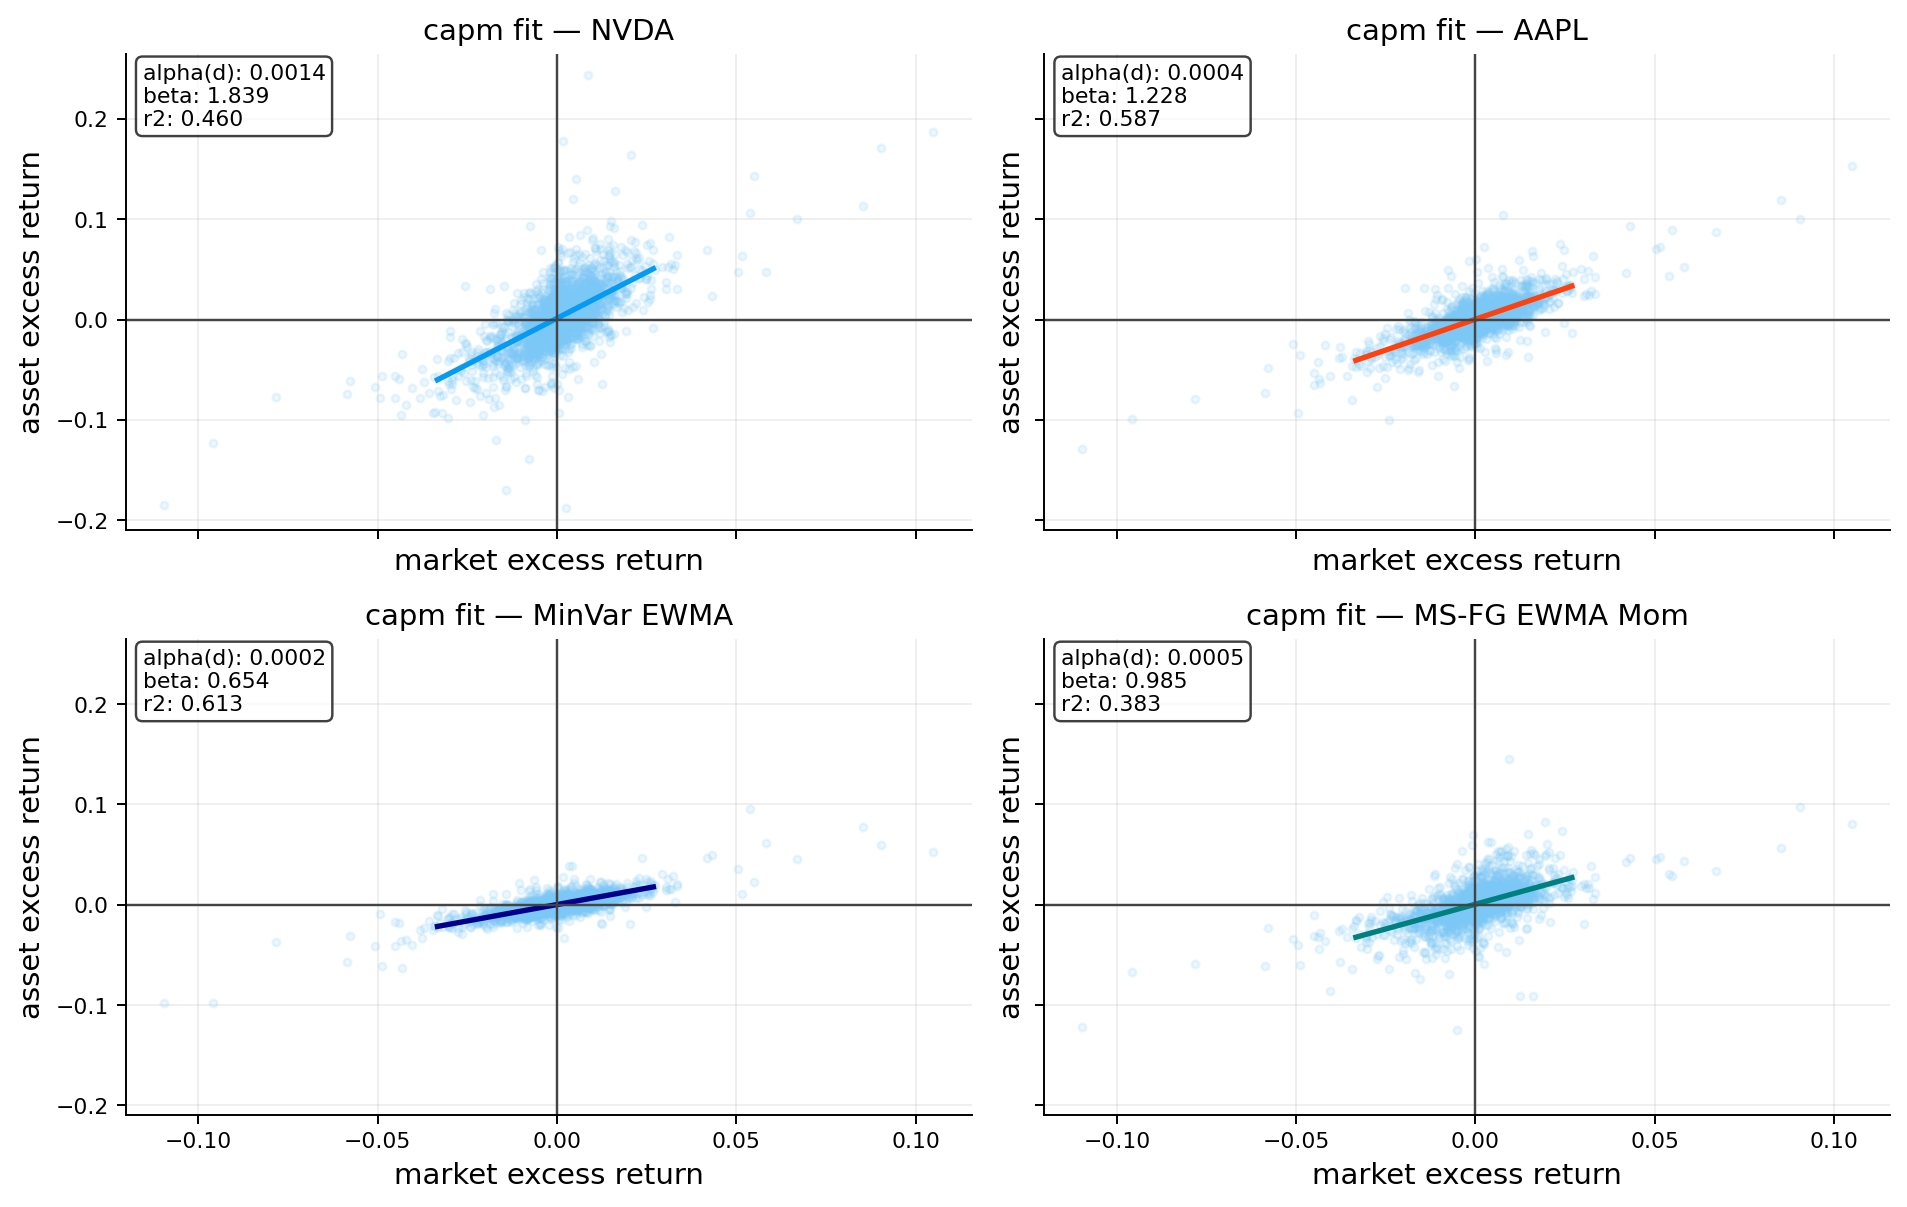

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, name in enumerate(obj.keys()):
    ax = axes[i]
    y_ex = (pd.Series(obj[name], index=base_idx) - rf_daily).dropna()
    m_ex = (pd.Series(market_ret, index=base_idx) - rf_daily).dropna()
    xy = pd.concat([m_ex, y_ex], axis=1).dropna()
    x = xy.iloc[:, 0].to_numpy(float)
    y = xy.iloc[:, 1].to_numpy(float)

    alpha = capm_tbl.loc[name, "alpha_daily"]
    beta = capm_tbl.loc[name, "beta"]
    r2 = capm_tbl.loc[name, "r2"]

    ax.scatter(x, y, s=10, alpha=0.15, color=palette[7])
    xs = np.linspace(np.percentile(x, 1), np.percentile(x, 99), 200)
    ys = alpha + beta * xs
    ax.plot(xs, ys, lw=2.2, color=obj_colors[name])

    ax.axhline(0.0, color="#444", lw=1)
    ax.axvline(0.0, color="#444", lw=1)
    ax.set_title(f"capm fit — {name}")
    ax.set_xlabel("market excess return")
    ax.set_ylabel("asset excess return")
    ax.text(
        0.02, 0.98,
        f"alpha(d): {alpha:.4f}\n"
        f"beta: {beta:.3f}\n"
        f"r2: {r2:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75),
    )

plt.tight_layout()
plt.show()


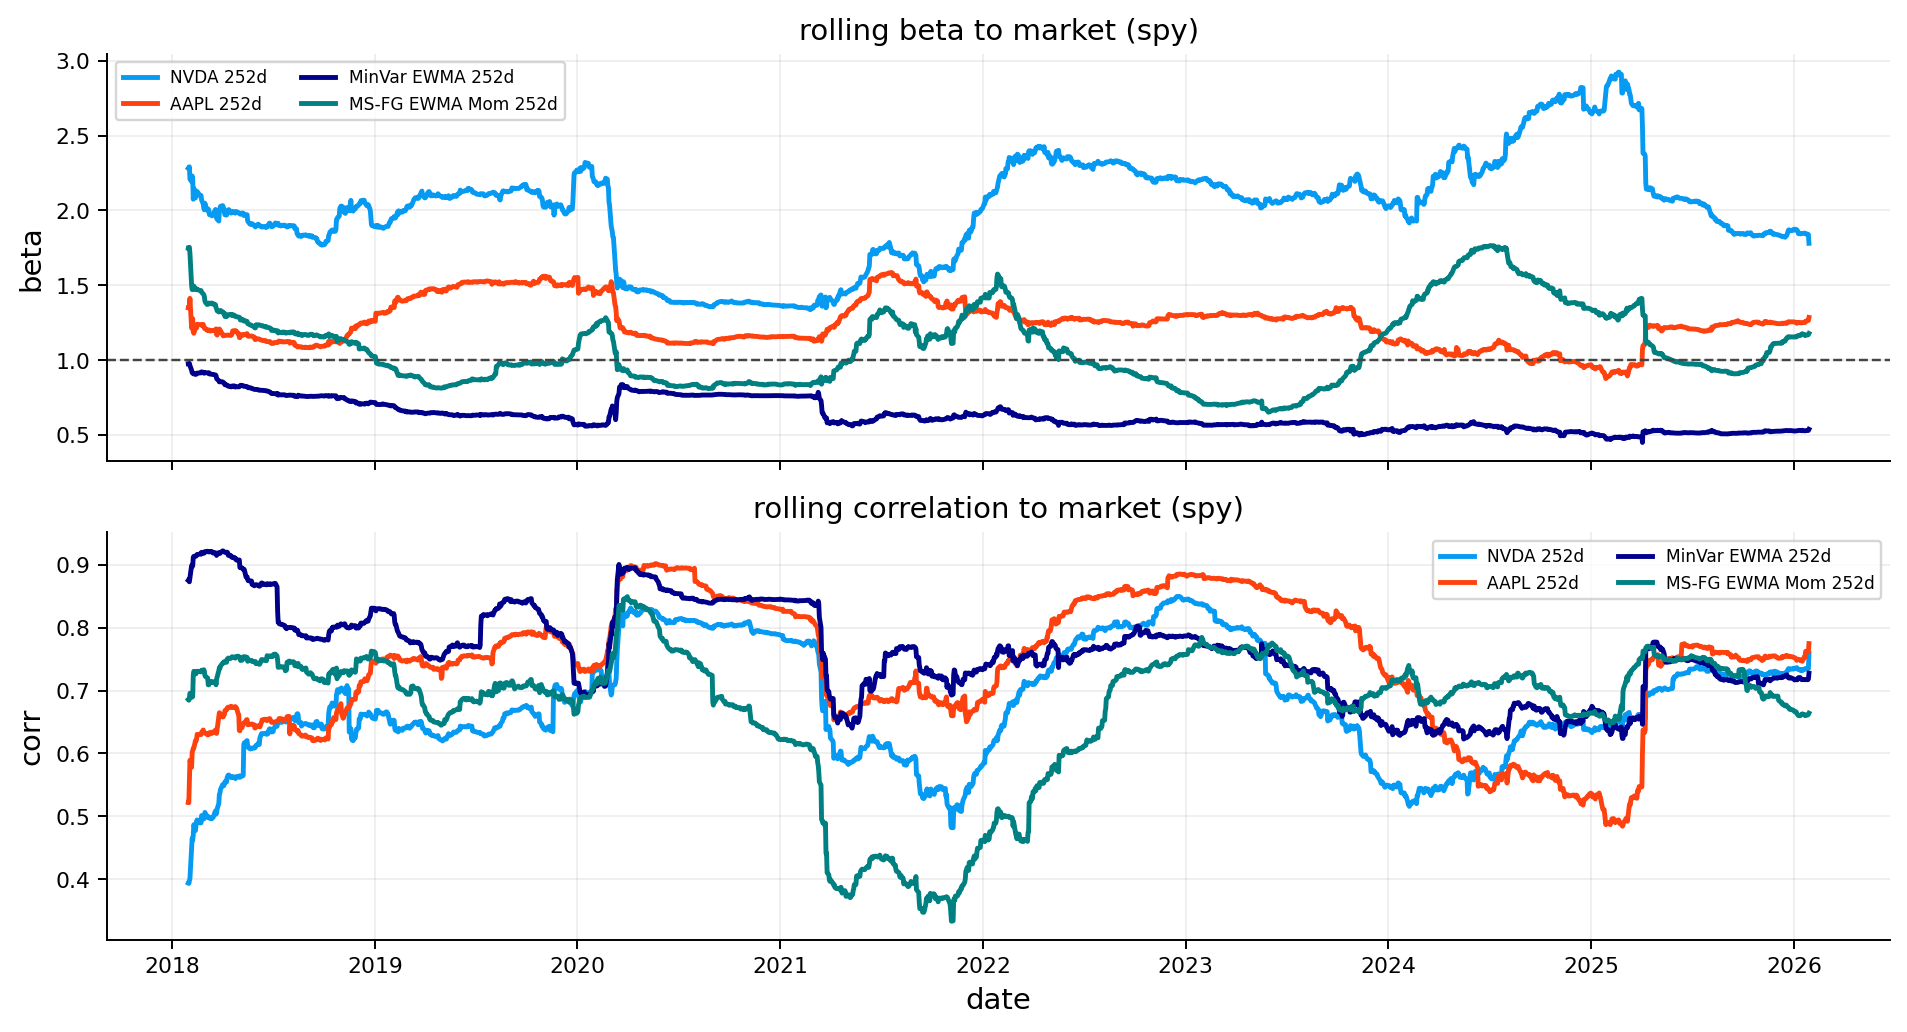

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for name in obj.keys():
    axes[0].plot(roll_store[name]["beta_252"], lw=2.0, color=obj_colors[name], label=f"{name} 252d")

axes[0].axhline(1.0, color="#444", lw=1, ls="--")
axes[0].set_title("rolling beta to market (spy)")
axes[0].set_ylabel("beta")
axes[0].legend(ncol=2)

for name in obj.keys():
    axes[1].plot(roll_store[name]["corr_252"], lw=2.0, color=obj_colors[name], label=f"{name} 252d")

axes[1].set_title("rolling correlation to market (spy)")
axes[1].set_ylabel("corr")
axes[1].set_xlabel("date")
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()


Now we can see the difference between our models and our picked stocks. both of our models have beta under 1 and both the stocks have over 1 beta. this means that the risk of these stocks are more dependent on market risk than the diversified portfolios.
all the 4 objects have positive alpha which means they all have more returns that can't be explained by market return and can be interpreted as outperformance of these objects relative to S&P 500. correlation of all the objects to SPY are high through time and MaxSharpe has some times that has higher than 1 beta, but MinVar EWMA has less than 1 beta almost all the time and is the only object with less than one up and down capture, but this object moves with market a lot due to correlation and R2 and var share.

---

## 11) risk attribution

We explained this in last notebook. now we repeat it and add another part.
for our portfolios we are looking for the assets that have the most share of portfolios risk.

### 11.1 volatility attribution (covariance-based)

If portfolio weights are $w$ and covariance matrix is $\Sigma$. portfolio volatility is:

$$
\sigma_p = \sqrt{w^\top \Sigma w}
$$

the marginal contribution to risk (mrc) of asset $i$ is:

$$
\text{mrc}_i = \frac{(\Sigma w)_i}{\sigma_p}
$$

the component contribution is:

$$
\text{rc}_i = w_i\,\text{mrc}_i
$$

and the contributions sum to total volatility:

$$
\sum_i \text{rc}_i = \sigma_p
$$

this tells us which names drive most of the volatility.

### 11.2 es attribution

for expected shortfall at level $\alpha$, identify the set of tail days:

$$
\mathcal{t}_\alpha = \{t : r_{p,t} \le q_\alpha(r_p)\}
$$

a simple scenario-based contribution approximation is:

$$
\text{es contrib}_i \approx -\frac{1}{|\mathcal{t}_\alpha|}\sum_{t \in \mathcal{t}_\alpha} w_i r_{i,t}
$$

so the largest contributors are the positions that lose the most on the worst portfolio days.


In [22]:
port_info = {
    "MinVar EWMA": (res_minvar, "EWMA"),
    "MS-FG EWMA Mom": (res_frontier, "EWMA"),
}

vol_contrib = {}
es_contrib = {}
overlap_rows = []

for pname, (res, cov_key) in port_info.items():
    dt = res.weights.index[-1]
    st = cache[dt]

    tickers = st["tickers"]
    w = res.weights.loc[dt].reindex(tickers).fillna(0.0).to_numpy(float)
    w = w / w.sum()

    cov = st["cov_ann_map"][cov_key]
    port_vol = np.sqrt(float(w @ cov @ w))

    m = cov @ w
    rc = pd.Series(w * m / port_vol, index=tickers).sort_values(ascending=False)
    vol_contrib[pname] = rc

    window = st.get("R_cov", st.get("window"))
    x = pd.DataFrame(window, columns=tickers)[tickers].to_numpy(float)
    rp = x @ w
    q = np.quantile(rp, 0.05)
    mask = rp <= q
    esc = pd.Series(-(x[mask] * w).mean(axis=0), index=tickers).sort_values(ascending=False)
    es_contrib[pname] = esc

    ov = len(set(rc.head(10).index).intersection(set(esc.head(10).index)))
    overlap_rows.append({"portfolio": pname, "top10_overlap_count": ov})

overlap_tbl = pd.DataFrame(overlap_rows).set_index("portfolio")


In [23]:
display(overlap_tbl)

,top10_overlap_count
portfolio,
MinVar EWMA,8
MS-FG EWMA Mom,9


for both strategies, 9 of top 10 contributions seem to be the same in Volatility and ES contributions. but the order might be different.

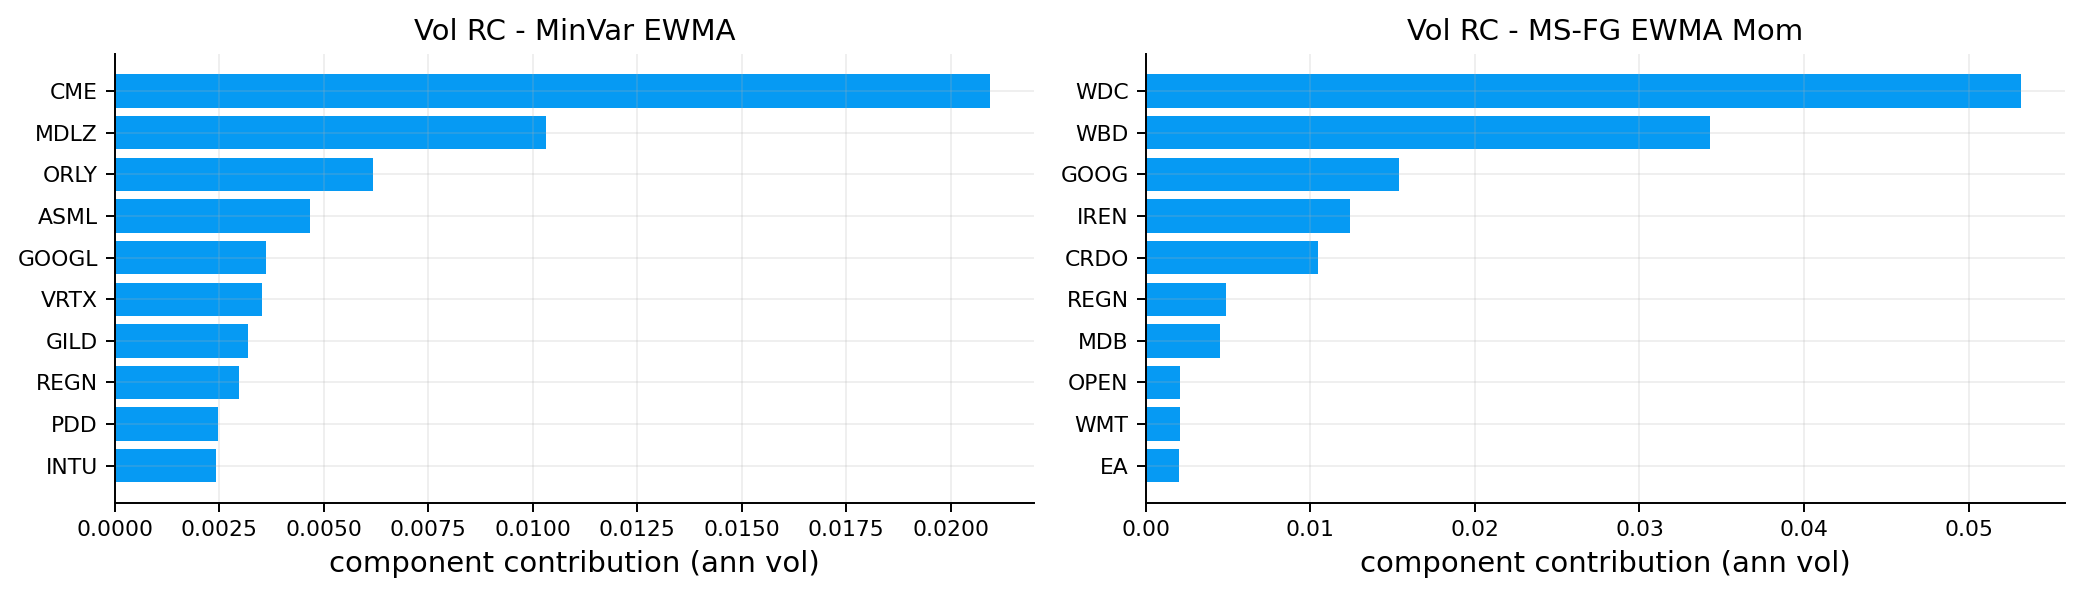

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, pname in zip(axes, port_info.keys()):
    top = vol_contrib[pname].head(10).sort_values()
    ax.barh(top.index, top.values)
    ax.set_title(f"Vol RC - {pname}")
    ax.set_xlabel("component contribution (ann vol)")

plt.tight_layout()
plt.show()


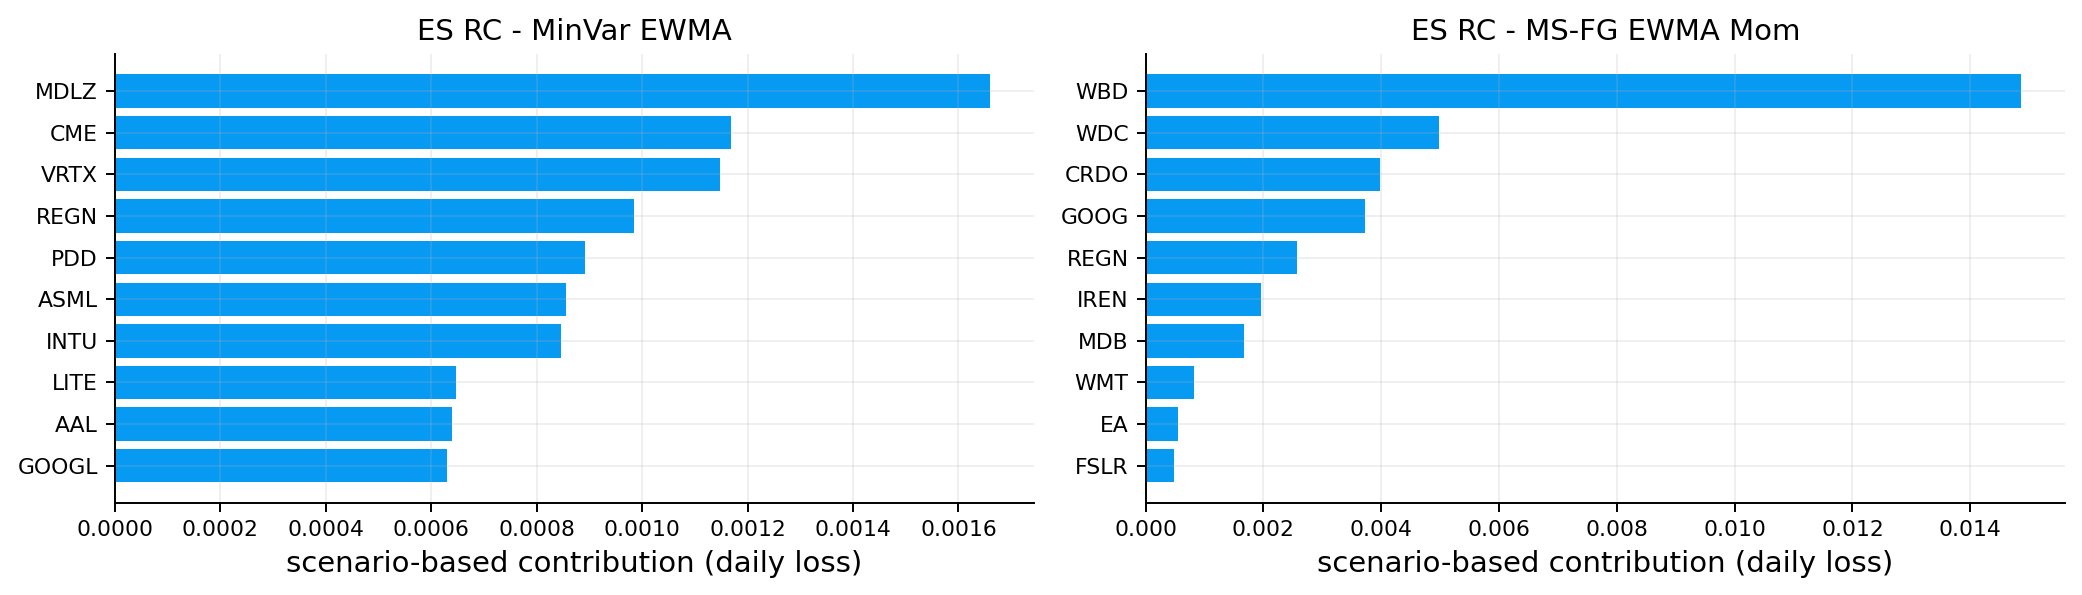

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, pname in zip(axes, port_info.keys()):
    top = es_contrib[pname].head(10).sort_values()
    ax.barh(top.index, top.values)
    ax.set_title(f"ES RC - {pname}")
    ax.set_xlabel("scenario-based contribution (daily loss)")

plt.tight_layout()
plt.show()


## 12) correlation and diversification (object-to-object)

correlation is a core ingredient of diversification. for two return series $x_t$ and $y_t$:

$$
\rho_{x,y} = \frac{\text{cov}(x,y)}{\sigma_x\sigma_y}
$$

we compute the correlation matrix across objects and visualize it as a heatmap.

- $\rho \approx 1$: objects move together (low diversification benefit)
- $\rho \approx 0$: movements are mostly independent
- $\rho < 0$: objects move in opposite direction, and we can hedge the other in some regimes (so rare in stock market)



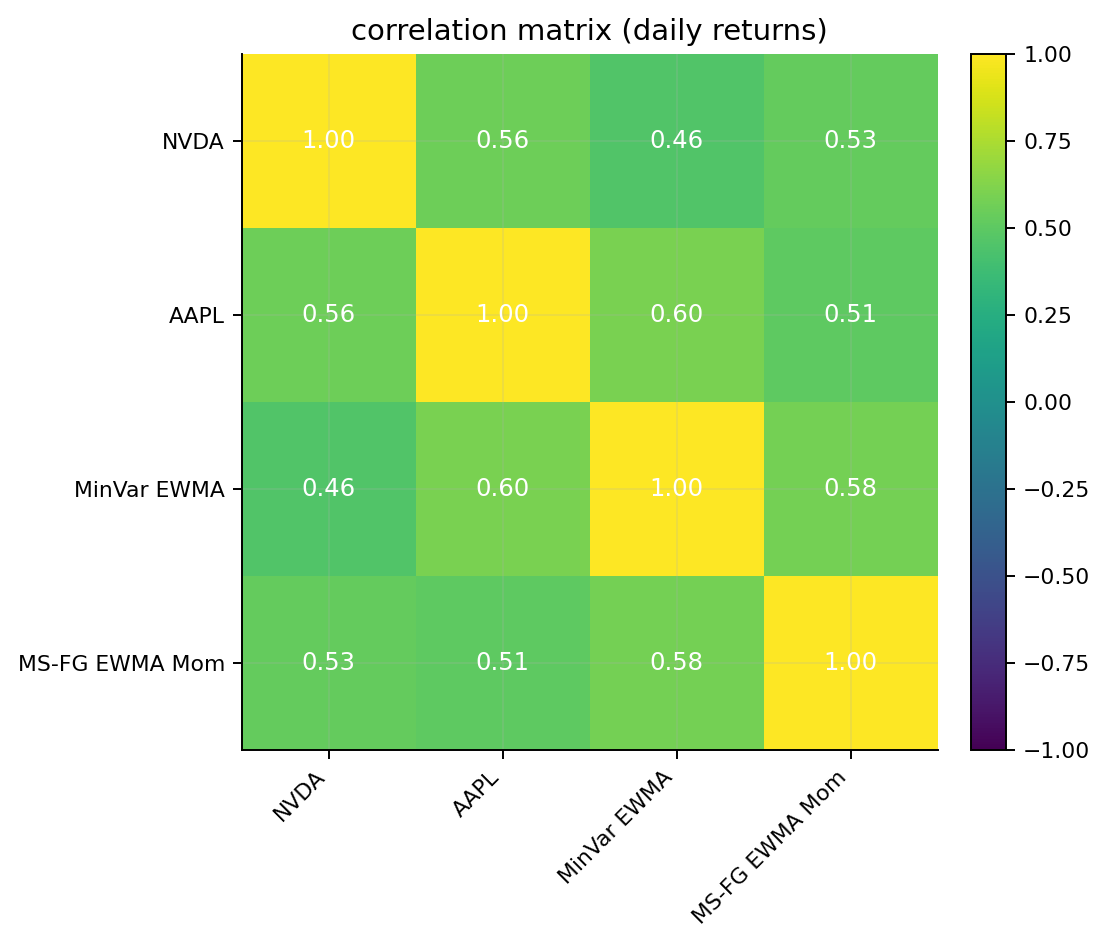

In [26]:
from quantfinlab.plotting.curves import choose_heatmap_cmap

corr = pd.DataFrame({k: pd.Series(v) for k, v in obj.items()}).dropna().corr()

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap=choose_heatmap_cmap("correlation"))
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("correlation matrix (daily returns)")


for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=10, color="white")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Implementation with Quantfinlab

We can implement the final library-composed workflow in two ways:

- US data with transparent atomic risk functions.
- HKEX data with the compact full risk report API.

In both cases, the Project 2 finalist portfolio names are listed explicitly. The notebook builds those known finalists directly instead of running the full grid search again and re-selecting winners.


## 1) Using manual functions for known US finalist risk measures and plots


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
MinVar EWMA,MinVar,-,EWMA,0.1703,0.1545,0.8413,-0.2868,0.5937,1.0569,0.0825,8.6666,0.0047,14.6727,0
MinVar Samp,MinVar,-,Sample,0.1531,0.1610,0.7211,-0.3009,0.5089,0.8829,0.0251,2.6315,0.0014,14.4339,0
MV EWMA Mom,MV,Momentum,EWMA,0.1652,0.1502,0.8321,-0.2869,0.5755,1.0287,0.1891,19.8510,0.0119,11.0928,0
MV EWMA BSM,MV,BayesSteinMomentum,EWMA,0.1639,0.1498,0.8263,-0.2875,0.5700,1.0221,0.1869,19.6290,0.0118,11.1398,0
Ridge EWMA Mom,RidgeMV,Momentum,EWMA,0.1634,0.1506,0.8202,-0.2861,0.5713,1.0009,0.1736,18.2317,0.0108,17.4597,0
MS EWMA Mom,MaxSharpe,Momentum,EWMA,0.2425,0.2563,0.8258,-0.4063,0.5969,1.0625,0.2862,30.0521,0.0152,7.6142,0
MS-FG EWMA Mom,FrontierGrid,Momentum,EWMA,0.2818,0.2944,0.8612,-0.4422,0.6372,1.1450,0.3717,39.0313,0.0170,6.2737,0


,ann_return,ann_vol,sharpe,sortino
object,,,,
MS EWMA Mom,0.2434,0.2563,0.8258,1.1895
MS-FG EWMA Mom,0.2830,0.2944,0.8612,1.2383
MV EWMA BSM,0.1638,0.1498,0.8263,1.1768
MV EWMA Mom,0.1651,0.1502,0.8321,1.1843
MinVar EWMA,0.1702,0.1545,0.8413,1.2069
MinVar Samp,0.1529,0.1610,0.7211,1.0202
Ridge EWMA Mom,0.1634,0.1506,0.8202,1.1624


,skew,excess_kurtosis,tail_ratio_95_05,worst_1d,worst_5d_avg,worst_10d_avg
object,,,,,,
MS EWMA Mom,-0.1235,8.4804,1.0189,-0.1191,-0.0974,-0.0826
MS-FG EWMA Mom,-0.1685,5.6565,1.0078,-0.1248,-0.1028,-0.0855
MV EWMA BSM,-0.4121,18.1061,1.0122,-0.0892,-0.0738,-0.0585
MV EWMA Mom,-0.4309,18.0276,1.0246,-0.0889,-0.0739,-0.0586
MinVar EWMA,-0.3344,19.3083,1.0040,-0.0974,-0.0751,-0.0571
MinVar Samp,-0.4201,18.2526,1.0097,-0.1112,-0.0736,-0.0595
Ridge EWMA Mom,-0.5183,19.7590,0.9974,-0.0991,-0.0750,-0.0590


,max_dd,longest_dd_days,avg_recovery_days,ulcer_index
object,,,,
MS EWMA Mom,-0.4063,977,24.1882,0.1894
MS-FG EWMA Mom,-0.4422,977,25.3415,0.2103
MV EWMA BSM,-0.2875,259,12.2278,0.0444
MV EWMA Mom,-0.2869,255,12.1258,0.0429
MinVar EWMA,-0.2868,153,12.4774,0.0438
MinVar Samp,-0.3009,269,13.3724,0.0522
Ridge EWMA Mom,-0.2861,259,11.6463,0.0445


,object,start,end,depth,duration
0,MinVar EWMA,2020-02-19,2020-05-28,-0.2868,70
1,MinVar Samp,2020-02-19,2020-07-14,-0.3009,102
2,MV EWMA Mom,2020-02-21,2020-05-15,-0.2869,60
3,MV EWMA BSM,2020-02-21,2020-05-15,-0.2875,60
4,Ridge EWMA Mom,2020-02-21,2020-05-15,-0.2861,60
5,MS EWMA Mom,2021-03-16,2025-02-03,-0.4063,977
6,MS-FG EWMA Mom,2021-03-16,2025-02-03,-0.4422,977


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
MS EWMA Mom,0.0239,0.0380,0.0234,0.0538,0.0321,0.0472
MS-FG EWMA Mom,0.0293,0.0437,0.0281,0.0544,0.0367,0.0512
MV EWMA BSM,0.0127,0.0212,0.0125,0.0461,0.0092,0.0136
MV EWMA Mom,0.0128,0.0213,0.0126,0.0462,0.0092,0.0135
MinVar EWMA,0.0133,0.0218,0.0124,0.0490,0.0086,0.0132
MinVar Samp,0.0137,0.0233,0.0135,0.0499,0.0098,0.0151
Ridge EWMA Mom,0.0129,0.0215,0.0125,0.0491,0.0083,0.0127


breach_count  breach_rate  coverage_error  \
object         method                                              
MS EWMA Mom    cf               119       0.0592          0.0092   
               fhs              113       0.0562          0.0062   
               hist             115       0.0572          0.0072   
MS-FG EWMA Mom cf               117       0.0582          0.0082   
               fhs              110       0.0548          0.0048   
               hist             118       0.0587          0.0087   
MV EWMA BSM    cf               116       0.0577          0.0077   
               fhs              106       0.0528          0.0028   
               hist             119       0.0592          0.0092   
MV EWMA Mom    cf               117       0.0582          0.0082   
               fhs              103       0.0513          0.0013   
               hist             115       0.0572          0.0072   
MinVar EWMA    cf               103       0.0513          0.0013   
               fhs              108       0.0538          0.0038   
               hist             116       0.0577          0.0077   
MinVar Samp    cf                88       0.0438         -0.0062   
               fhs              110       0.0548          0.0048   
               hist             110       0.0548          0.0048   
Ridge EWMA Mom cf               103       0.0513          0.0013   
               fhs              107       0.0533          0.0033   
               hist             114       0.0567          0.0067   

                       abs_coverage_error  longest_breach_streak  \
object         method                                              
MS EWMA Mom    cf                  0.0092                      3   
               fhs                 0.0062                      3   
               hist                0.0072                      3   
MS-FG EWMA Mom cf                  0.0082                      3   
               fhs                 0.0048                      3   
               hist                0.0087                      3   
MV EWMA BSM    cf                  0.0077                      3   
               fhs                 0.0028                      2   
               hist                0.0092                      3   
MV EWMA Mom    cf                  0.0082                      3   
               fhs                 0.0013                      2   
               hist                0.0072                      3   
MinVar EWMA    cf                  0.0013                      3   
               fhs                 0.0038                      2   
               hist                0.0077                      3   
MinVar Samp    cf                  0.0062                      3   
               fhs                 0.0048                      2   
               hist                0.0048                      3   
Ridge EWMA Mom cf                  0.0013                      3   
               fhs                 0.0033                      2   
               hist                0.0067                      3   

                       avg_gap_days  kupiec_p  christoffersen_p  \
object         method                                             
MS EWMA Mom    cf           16.8814    0.0647            0.0048   
               fhs          17.5089    0.2074            0.0048   
               hist         17.3596    0.1450            0.0175   
MS-FG EWMA Mom cf           17.0603    0.0983            0.0233   
               fhs          17.9908    0.3353            0.1139   
               hist         16.9145    0.0801            0.0109   
MV EWMA BSM    cf           16.8000    0.1199            0.0003   
               fhs          18.4000    0.5732            0.0734   
               hist         16.3729    0.0647            0.0002   
MV EWMA Mom    cf           16.6552    0.0983            0.0004   
               fhs          18.9412    0.7949            0.1176   
               hist   

,window,cum_return,max_dd,worst_day,worst_week
object,,,,,
MS EWMA Mom,2022_inflation,-0.1026,-0.2054,-0.0785,-0.0712
MS-FG EWMA Mom,2022_inflation,-0.1814,-0.2824,-0.0857,-0.1039
MV EWMA BSM,2018_q4,-0.0534,-0.1125,-0.0294,-0.0524
MV EWMA Mom,2018_q4,-0.0526,-0.1114,-0.0293,-0.0523
MinVar EWMA,2018_q4,-0.0799,-0.1237,-0.0287,-0.0572
MinVar Samp,2020_covid,-0.1219,-0.3001,-0.1112,-0.1446
Ridge EWMA Mom,2018_q4,-0.0651,-0.1128,-0.0311,-0.0517


,alpha_daily,alpha_ann,beta,r2,tracking_error,information_ratio,up_capture,down_capture,systematic_var_share
object,,,,,,,,,
MS EWMA Mom,0.0004,0.1059,0.9360,0.4564,0.1893,0.4917,1.0182,0.9133,0.4564
MS-FG EWMA Mom,0.0005,0.1465,0.9853,0.3833,0.2312,0.5838,1.1959,1.0734,0.3833
MV EWMA BSM,0.0002,0.0499,0.6334,0.6116,0.1154,0.0454,0.6328,0.5607,0.6116
MV EWMA Mom,0.0002,0.0509,0.6352,0.6124,0.1153,0.0554,0.6362,0.5634,0.6124
MinVar EWMA,0.0002,0.0538,0.6539,0.6133,0.1154,0.0988,0.6573,0.5819,0.6133
MinVar Samp,0.0001,0.0346,0.6924,0.6328,0.1130,-0.0217,0.6701,0.6130,0.6328
Ridge EWMA Mom,0.0002,0.0458,0.6647,0.6662,0.1069,0.0469,0.6619,0.5949,0.6662


,top10_overlap_count
portfolio,
MS EWMA Mom,10
MS-FG EWMA Mom,9
MV EWMA BSM,7
MV EWMA Mom,6
MinVar EWMA,8
MinVar Samp,8
Ridge EWMA Mom,6


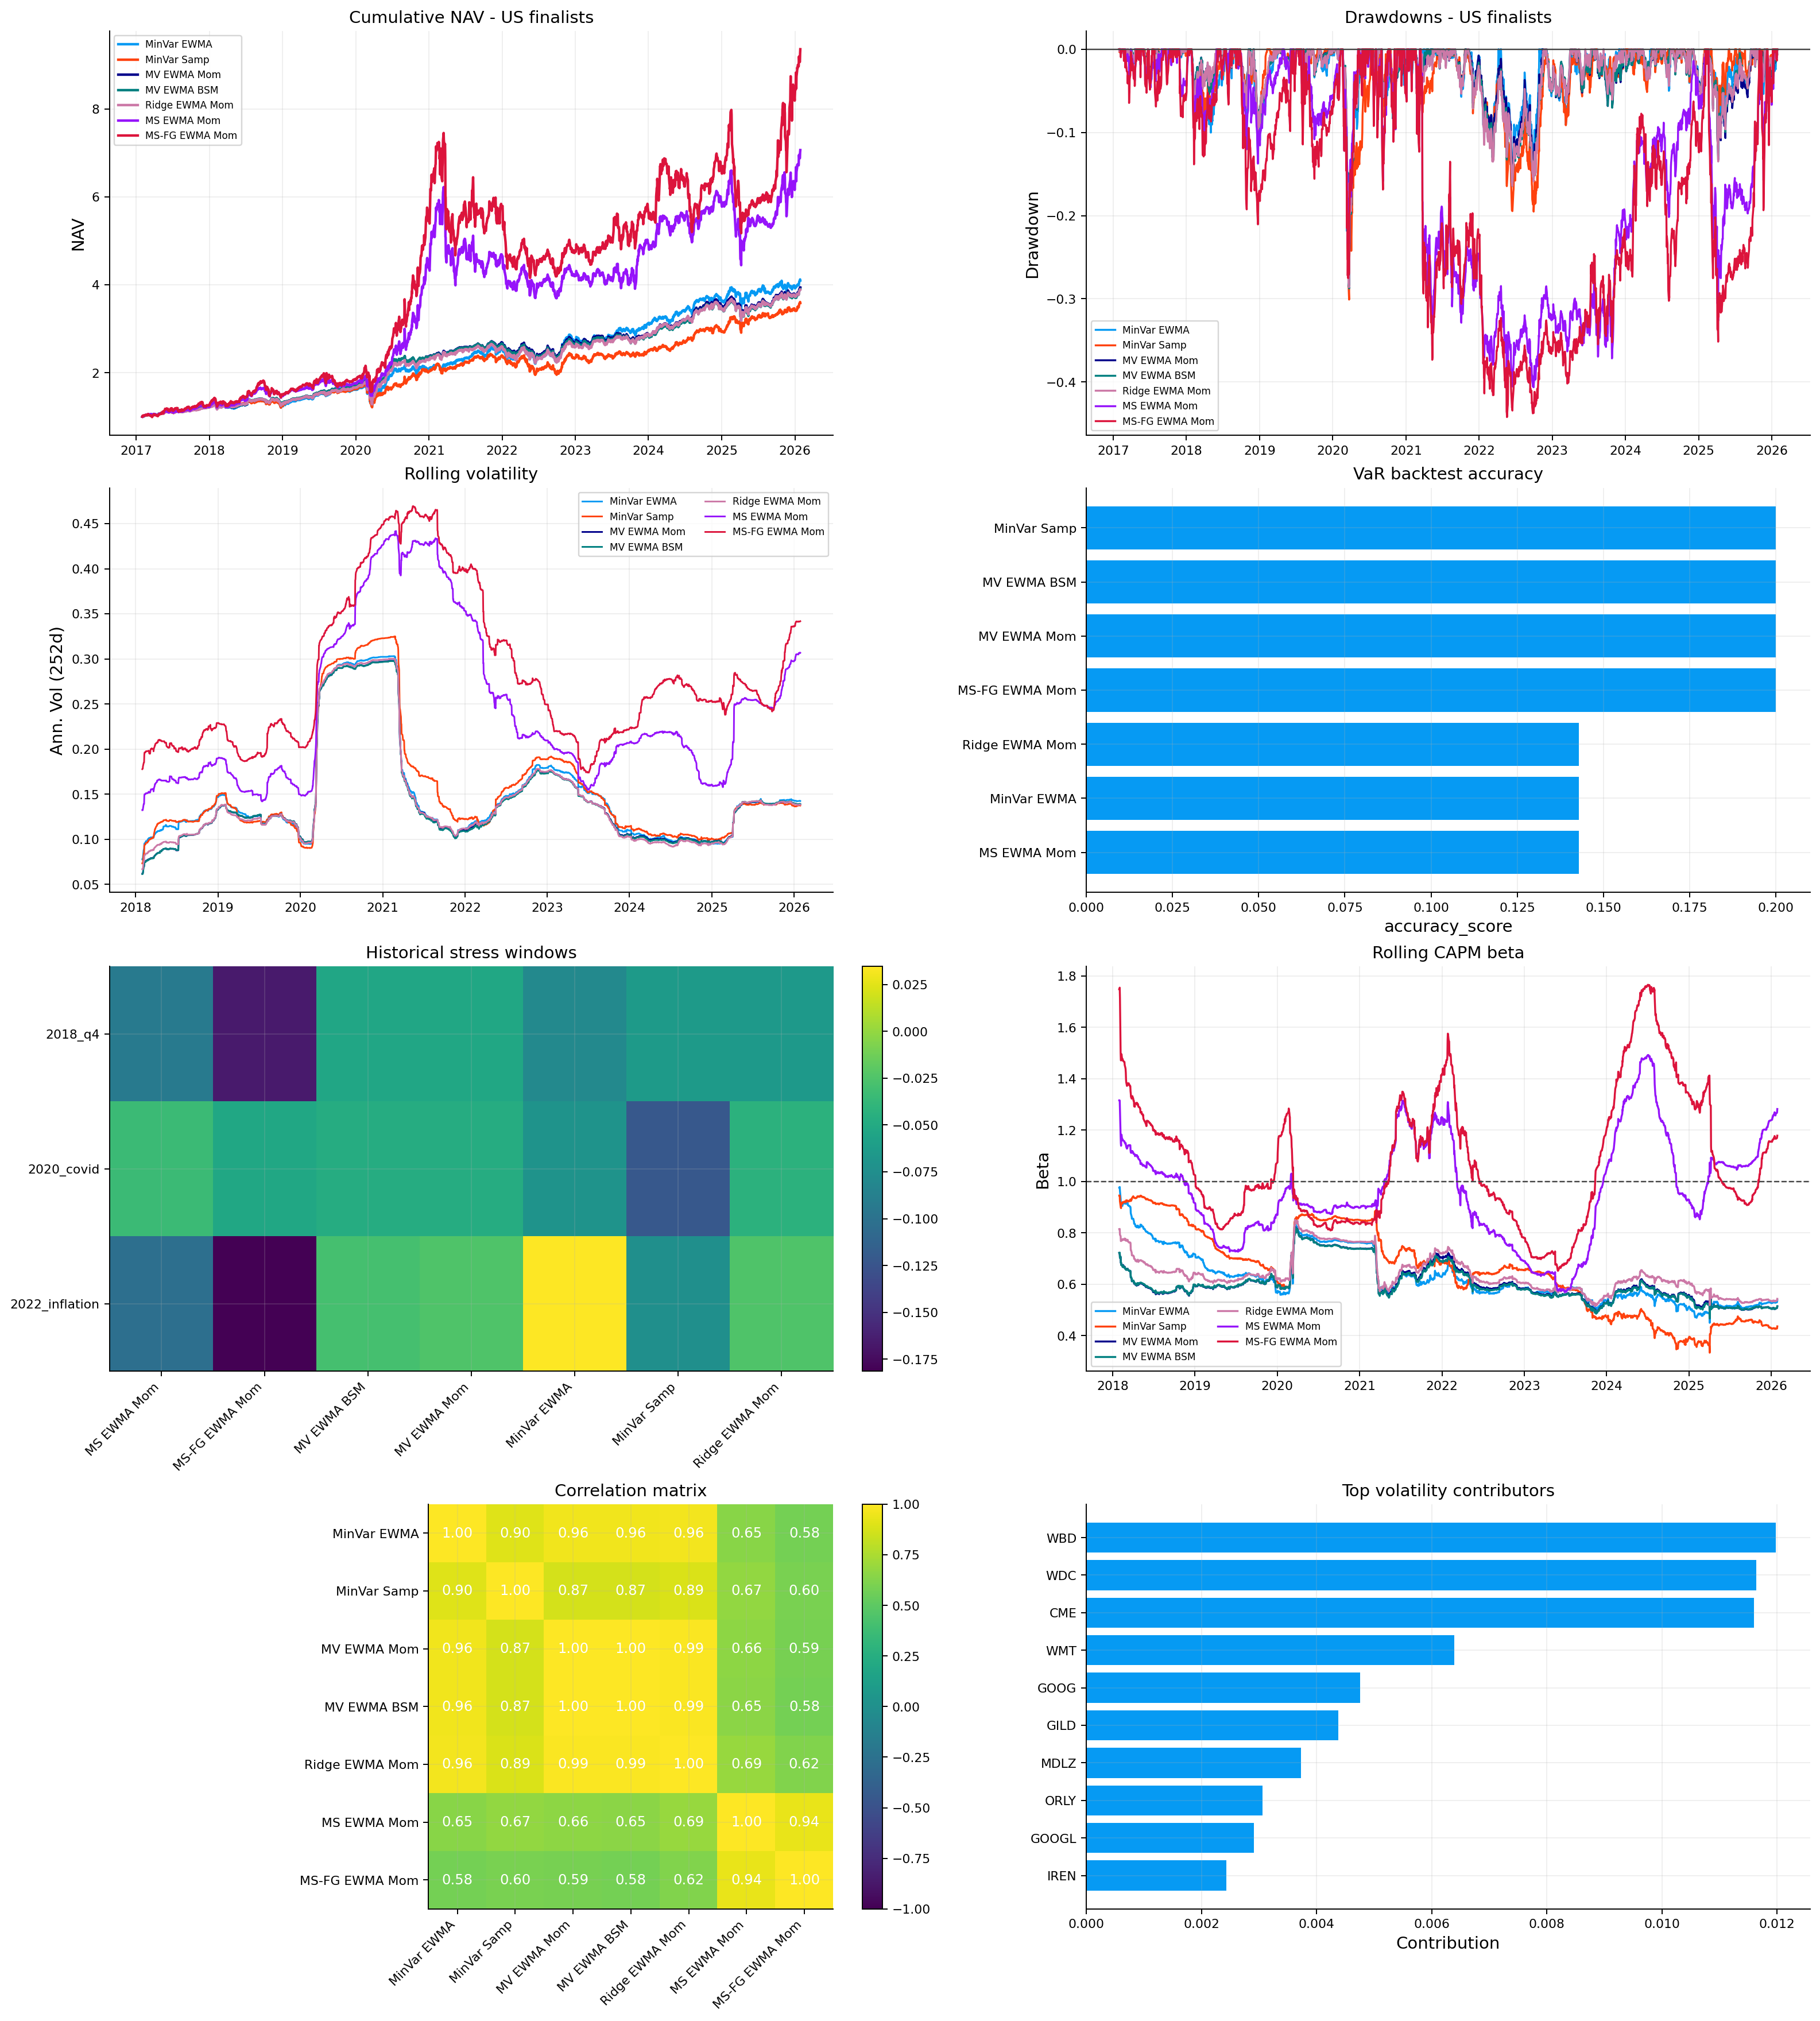

US finalists in risk analysis: ['MinVar EWMA', 'MinVar Samp', 'MV EWMA Mom', 'MV EWMA BSM', 'Ridge EWMA Mom', 'MS EWMA Mom', 'MS-FG EWMA Mom']


In [27]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantfinlab.portfolio import covariance, expected_returns, optimizers, universe, walkforward
from quantfinlab.risk import (
    capm,
    contributions,
    correlation,
    distribution,
    drawdown,
    performance,
    stress,
    var,
    var_backtesting)

from quantfinlab.plotting import risk as risk_plots

warnings.filterwarnings("ignore")

rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0

us_finalists = ["MinVar EWMA", "MinVar Samp",
                "MV EWMA Mom", "MV EWMA BSM",
                "Ridge EWMA Mom", "MS EWMA Mom", "MS-FG EWMA Mom"]

us_strategy_specs = [
    {"name": "MinVar EWMA", "optimizer": "MinVar", "cov_model": "EWMA"},
    {"name": "MinVar Samp", "optimizer": "MinVar", "cov_model": "Sample"},
    {"name": "MV EWMA Mom", "optimizer": "MV", "cov_model": "EWMA", "mu_model": "Momentum"},
    {"name": "MV EWMA BSM", "optimizer": "MV", "cov_model": "EWMA", "mu_model": "BayesSteinMomentum"},
    {"name": "Ridge EWMA Mom", "optimizer": "RidgeMV", "cov_model": "EWMA", "mu_model": "Momentum"},
    {"name": "MS EWMA Mom", "optimizer": "MaxSharpe", "cov_model": "EWMA", "mu_model": "Momentum"},
    {"name": "MS-FG EWMA Mom", "optimizer": "FrontierGrid", "cov_model": "EWMA", "mu_model": "Momentum"}]

df = pd.read_parquet("../data/nasdaq_all_close_volume.parquet")
df["date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date")

close_map, vol_map = {}, {}
for c in df.columns:
    c_str = str(c)
    if c_str.lower() == "date" or "__" not in c_str:
        continue
    t, f = c_str.rsplit("__", 1)
    fl = f.lower()
    if fl == "close":
        close_map[t] = c
    elif fl == "volume":
        vol_map[t] = c

tickers_all = sorted(set(close_map).intersection(vol_map))

close_prices = df[[close_map[t] for t in tickers_all]].copy()
volumes = df[[vol_map[t] for t in tickers_all]].copy()
close_prices.columns = tickers_all
volumes.columns = tickers_all
close_prices.index = pd.to_datetime(df["date"].values)
volumes.index = pd.to_datetime(df["date"].values)

close_prices, volumes = universe.clean_close_volume_panels(
    close_prices, volumes, start="2016-01-01")

returns = universe.prices_to_returns(close_prices)
rebal_dates = universe.make_rebalance_dates(
    returns.index, freq="ME", min_history_days=252)

stack = walkforward.run_walkforward_grid(
    returns=returns, close=close_prices, volume=volumes,
    rebalance_dates=rebal_dates,
    cov_models={"EWMA": covariance.ewma_covariance, "Sample": covariance.sample_covariance},
    mu_models={"Momentum": expected_returns.momentum_mu,
               "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu},

    optimizers={
        "MinVar": optimizers.minimum_variance,
        "MV": optimizers.mean_variance,
        "RidgeMV": optimizers.ridge_mean_variance,
        "MaxSharpe": optimizers.max_sharpe_slsqp,
        "FrontierGrid": optimizers.max_sharpe_frontier_grid},

    strategy_specs=us_strategy_specs,
    rf_daily=rf_daily,
    annualization=252)

results = {name: stack.backtests[name] for name in us_finalists}
display(stack.results.loc[us_finalists].round(4))

cache = dict(stack.cache)

def _default_cov_key(state_cache):
    for state in state_cache.values():
        cov_map = state.get("cov_ann_map", {})
        for preferred in ("LedoitWolf", "OAS", "Sample", "EWMA", "ledoitwolf", "oas", "sample", "ewma"):
            if preferred in cov_map:
                return preferred
        if cov_map:
            return next(iter(cov_map.keys()))
    return None


def _cov_key_for_backtest(result, fallback):
    meta = dict(result.metadata or {})
    return meta.get("cov_model") or fallback


fallback_cov_key = _default_cov_key(cache)
cov_key_for_rc = {name: _cov_key_for_backtest(res, fallback_cov_key) for name, res in results.items()}

common_idx = None
for res in results.values():
    idx_res = pd.DatetimeIndex(res.net_returns.index)
    common_idx = idx_res if common_idx is None else common_idx.intersection(idx_res)
if common_idx is None or len(common_idx) == 0:
    raise ValueError("No overlapping index across US finalist returns.")

objects = {name: res.net_returns.reindex(common_idx).fillna(0.0) for name, res in results.items()}

spy = pd.read_csv("../data/spy_yfinance.csv")
spy["date"] = pd.to_datetime(spy["Date"], errors="coerce")
spy = spy.dropna(subset=["date"]).sort_values("date").set_index("date")
if "Adj Close" in spy.columns:
    spy_px = pd.to_numeric(spy["Adj Close"], errors="coerce")
elif "Close" in spy.columns:
    spy_px = pd.to_numeric(spy["Close"], errors="coerce")
else:
    raise ValueError("spy_yfinance.csv missing close/adj close column")
market_ret = spy_px.pct_change(fill_method=None).reindex(common_idx).fillna(0.0)

portfolios = {
    name: {"backtest": results[name], "state_cache": cache, "cov_key": cov_key_for_rc[name]}
    for name in results.keys()}

perf_tbl = performance.performance_table(objects, rf_daily=rf_daily, annualization=252)
shape_tbl = distribution.tail_shape_table(objects)
dd_summary_tbl = drawdown.drawdown_summary_table(objects)
dd_episodes_tbl = drawdown.drawdown_episodes_table(objects, top_n=1)
var_es_tbl = var.var_es_table(objects, alpha=0.05, methods=["hist", "cf", "fhs"])
var_bt_tbl = var_backtesting.var_backtest_table(objects, alpha=0.05, methods=["hist", "cf", "fhs"], lookback=252)

stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "2020_covid": ("2020-02-20", "2020-04-30"),
    "2022_inflation": ("2022-01-03", "2022-10-31")}

stress_tbl = stress.stress_table(objects, windows=stress_windows, worst_only=True)
stress_tbl_full = stress.stress_table(objects, windows=stress_windows, worst_only=False)
capm_tbl, capm_roll = capm.capm_table(objects, market_ret=market_ret, rf_daily=rf_daily, rolling=[126, 252])
corr_tbl = correlation.corr_matrix(objects)
vol_rc_tbl, es_rc_tbl, overlap_tbl = contributions.attribution_tables(portfolios, es_alpha=0.05, top_k=10)

display(perf_tbl.round(4))
display(shape_tbl.round(4))
display(dd_summary_tbl.round(4))
display(dd_episodes_tbl.round(4))
display(var_es_tbl.round(4))
display(var_bt_tbl.round(4))
display(stress_tbl.round(4))
display(capm_tbl.round(4))
display(overlap_tbl)

fig, axes = plt.subplots(4, 2, figsize=(18, 20), constrained_layout=True)

risk_plots.plot_nav_compare(ax=axes[0, 0], objects=objects, title="Cumulative NAV - US finalists")
risk_plots.plot_drawdown_compare_objects(ax=axes[0, 1], objects=objects, title="Drawdowns - US finalists")
risk_plots.plot_rolling_volatility(ax=axes[1, 0], objects=objects, windows=[20, 60, 252], annualization=252, title="Rolling volatility")
risk_plots.plot_var_backtest_summary(ax=axes[1, 1], var_backtest_table=var_bt_tbl, title="VaR backtest accuracy")
risk_plots.plot_stress_heatmap(ax=axes[2, 0], stress_table=stress_tbl_full, title="Historical stress windows")
risk_plots.plot_rolling_beta(ax=axes[2, 1], rolling_beta=capm_roll, title="Rolling CAPM beta")
risk_plots.plot_corr_heatmap(ax=axes[3, 0], corr=corr_tbl, title="Correlation matrix")
risk_plots.plot_contribution_bars(ax=axes[3, 1], contribution_table=vol_rc_tbl, top_k=10, title="Top volatility contributors")

plt.show()

print("US finalists in risk analysis:", us_finalists)


## 2) Using the risk report function for known HKEX finalist results

The data used in this part can be downloaded from here ([Stooq HKEX daily market data]).

[Stooq HKEX daily market data]: https://stooq.com/db/h/

For the CAPM benchmark we build the EW portfolio as a benchmark when needed, but the reported risk objects are exactly the listed HKEX finalists.


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
MinVar Samp,MinVar,-,Sample,0.0381,0.1379,0.0552,-0.4350,0.0875,0.0732,0.0178,1.9429,0.0015,13.4652,0
MinVar LW,MinVar,-,LedoitWolf,0.0412,0.1382,0.0771,-0.4070,0.1012,0.1027,0.0152,1.6606,0.0013,15.4898,0
MV EWMA BS,MV,BayesStein,EWMA,0.0865,0.1320,0.3981,-0.2785,0.3106,0.4983,0.1944,21.1847,0.0145,9.9705,0
MV EWMA Mom,MV,Momentum,EWMA,0.0838,0.1327,0.3781,-0.2927,0.2861,0.4717,0.1942,21.1697,0.0146,10.0254,0
Ridge LW BS,RidgeMV,BayesStein,LedoitWolf,0.0807,0.1445,0.3382,-0.2772,0.2911,0.4311,0.0647,7.0501,0.0049,15.1786,0
MS LW BS,MaxSharpe,BayesStein,LedoitWolf,0.1723,0.2469,0.6108,-0.3582,0.4810,0.7733,0.1971,21.4788,0.0106,7.5459,0
MS-FG LW BS,FrontierGrid,BayesStein,LedoitWolf,0.1996,0.2673,0.6699,-0.3890,0.5132,0.8727,0.1611,17.5574,0.0078,7.2038,0


,ann_return,ann_vol,sharpe,sortino
object,,,,
MS LW BS,0.1726,0.2469,0.6108,0.8354
MS-FG LW BS,0.1998,0.2673,0.6699,0.9253
MV EWMA BS,0.0866,0.1320,0.3981,0.5383
MV EWMA Mom,0.0839,0.1327,0.3781,0.5103
MinVar LW,0.0411,0.1382,0.0771,0.1048
MinVar Samp,0.0380,0.1379,0.0552,0.0748
Ridge LW BS,0.0807,0.1445,0.3382,0.4535


,skew,excess_kurtosis,tail_ratio_95_05,worst_1d,worst_5d_avg,worst_10d_avg
object,,,,,,
MS LW BS,-0.9488,9.0562,0.9722,-0.1728,-0.0934,-0.0775
MS-FG LW BS,-0.7664,6.8257,1.0042,-0.1717,-0.0981,-0.0806
MV EWMA BS,-1.0763,10.1463,1.0358,-0.0883,-0.0586,-0.0470
MV EWMA Mom,-1.0612,9.6106,1.0060,-0.0861,-0.0586,-0.0480
MinVar LW,-0.5904,4.9987,1.0216,-0.0654,-0.0539,-0.0445
MinVar Samp,-0.6200,5.1635,1.0144,-0.0656,-0.0542,-0.0446
Ridge LW BS,-1.0029,7.5390,0.9677,-0.0919,-0.0594,-0.0485


,max_dd,longest_dd_days,avg_recovery_days,ulcer_index
object,,,,
MS LW BS,-0.3582,992,32.3906,0.1598
MS-FG LW BS,-0.3890,888,32.4375,0.1835
MV EWMA BS,-0.2785,1054,27.5541,0.0798
MV EWMA Mom,-0.2927,724,27.9863,0.0866
MinVar LW,-0.4070,1671,58.8056,0.1926
MinVar Samp,-0.4350,1678,11.9189,0.2104
Ridge LW BS,-0.2772,735,31.7692,0.0956


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
MS LW BS,0.0251,0.0372,0.0259,0.0572,0.0234,0.0330
MS-FG LW BS,0.0264,0.0396,0.0280,0.0558,0.0251,0.0347
MV EWMA BS,0.0121,0.0195,0.0140,0.0320,0.0082,0.0121
MV EWMA Mom,0.0122,0.0196,0.0141,0.0315,0.0080,0.0120
MinVar LW,0.0132,0.0201,0.0146,0.0264,0.0091,0.0133
MinVar Samp,0.0133,0.0202,0.0147,0.0266,0.0092,0.0138
Ridge LW BS,0.0142,0.0215,0.0157,0.0315,0.0094,0.0135


breach_count  breach_rate  coverage_error  \
object      method                                              
MS LW BS    cf               103       0.0525          0.0025   
            fhs              104       0.0530          0.0030   
            hist             120       0.0611          0.0111   
MS-FG LW BS cf                97       0.0494         -0.0006   
            fhs              104       0.0530          0.0030   
            hist             116       0.0591          0.0091   
MV EWMA BS  cf                85       0.0433         -0.0067   
            fhs              108       0.0550          0.0050   
            hist             110       0.0560          0.0060   
MV EWMA Mom cf                83       0.0423         -0.0077   
            fhs              113       0.0576          0.0076   
            hist             104       0.0530          0.0030   
MinVar LW   cf                96       0.0489         -0.0011   
            fhs               98       0.0499         -0.0001   
            hist             105       0.0535          0.0035   
MinVar Samp cf                96       0.0489         -0.0011   
            fhs              102       0.0520          0.0020   
            hist             107       0.0545          0.0045   
Ridge LW BS cf                90       0.0458         -0.0042   
            fhs              106       0.0540          0.0040   
            hist             104       0.0530          0.0030   

                    abs_coverage_error  longest_breach_streak  avg_gap_days  \
object      method                                                            
MS LW BS    cf                  0.0025                      3       18.9020   
            fhs                 0.0030                      2       18.7184   
            hist                0.0111                      3       16.2437   
MS-FG LW BS cf                  0.0006                      3       20.0833   
            fhs                 0.0030                      2       18.7184   
            hist                0.0091                      3       16.8087   
MV EWMA BS  cf                  0.0067                      3       23.0238   
            fhs                 0.0050                      3       18.0748   
            hist                0.0060                      3       17.7431   
MV EWMA Mom cf                  0.0077                      3       23.5854   
            fhs                 0.0076                      3       17.2679   
            hist                0.0030                      3       18.7670   
MinVar LW   cf                  0.0011                      3       20.2947   
            fhs                 0.0001                      3       19.9381   
            hist                0.0035                      3       18.5962   
MinVar Samp cf                  0.0011                      3       20.2947   
            fhs                 0.0020                      3       19.0891   
            hist                0.0045                      3       18.2453   
Ridge LW BS cf                  0.0042                      3       21.7303   
            fhs                 0.0040                      3       18.4190   
            hist                0.0030                      3       18.7767   

                    kupiec_p  christoffersen_p  quantile_loss  accuracy_rank  \
object      method                                                             
MS LW BS    cf        0.6182            0.2685         0.0019            2.0   
            fhs       0.5483            0.8287         0.0018            1.0   
            hist      0.0285            0.8931         0.0019            3.0   
MS-FG LW BS cf        0.9050            0.3185         0.0021            2.0   
            fhs       0.5483            0.8150         0.0020            1.0   
            hist      0.0720            0.6507         0.0020            3.0   
MV EWMA BS  cf        0.1638            0.0002         0.0011     

,alpha_daily,alpha_ann,beta,r2,tracking_error,information_ratio,up_capture,down_capture,systematic_var_share
object,,,,,,,,,
MS LW BS,0.0004,0.1087,0.8285,0.5136,0.1761,0.5303,0.9456,0.8616,0.5136
MS-FG LW BS,0.0005,0.1347,0.9164,0.5362,0.1829,0.6648,1.0409,0.9407,0.5362
MV EWMA BS,0.0001,0.0253,0.4803,0.6034,0.1387,-0.0352,0.5014,0.4645,0.6034
MV EWMA Mom,0.0001,0.0228,0.4804,0.5979,0.1393,-0.0523,0.5010,0.4661,0.5979
MinVar LW,-0.0001,-0.0192,0.5230,0.6537,0.1303,-0.3591,0.5391,0.5410,0.6537
MinVar Samp,-0.0001,-0.0216,0.5127,0.6305,0.1336,-0.3730,0.5262,0.5297,0.6305
Ridge LW BS,0.0001,0.0170,0.5568,0.6774,0.1253,-0.0685,0.5931,0.5669,0.6774


- MS-FG LW BS has the highest realized Sharpe ratio.
- Least severe maximum drawdown: Ridge LW BS (-27.72%).
- Lower historical ES tail risk: MV EWMA BS (1.95%).
- Highest market beta: MS-FG LW BS (0.92); lowest: MV EWMA BS (0.48).
- Potential VaR model instability (p<0.05): MV EWMA BS, MV EWMA Mom.


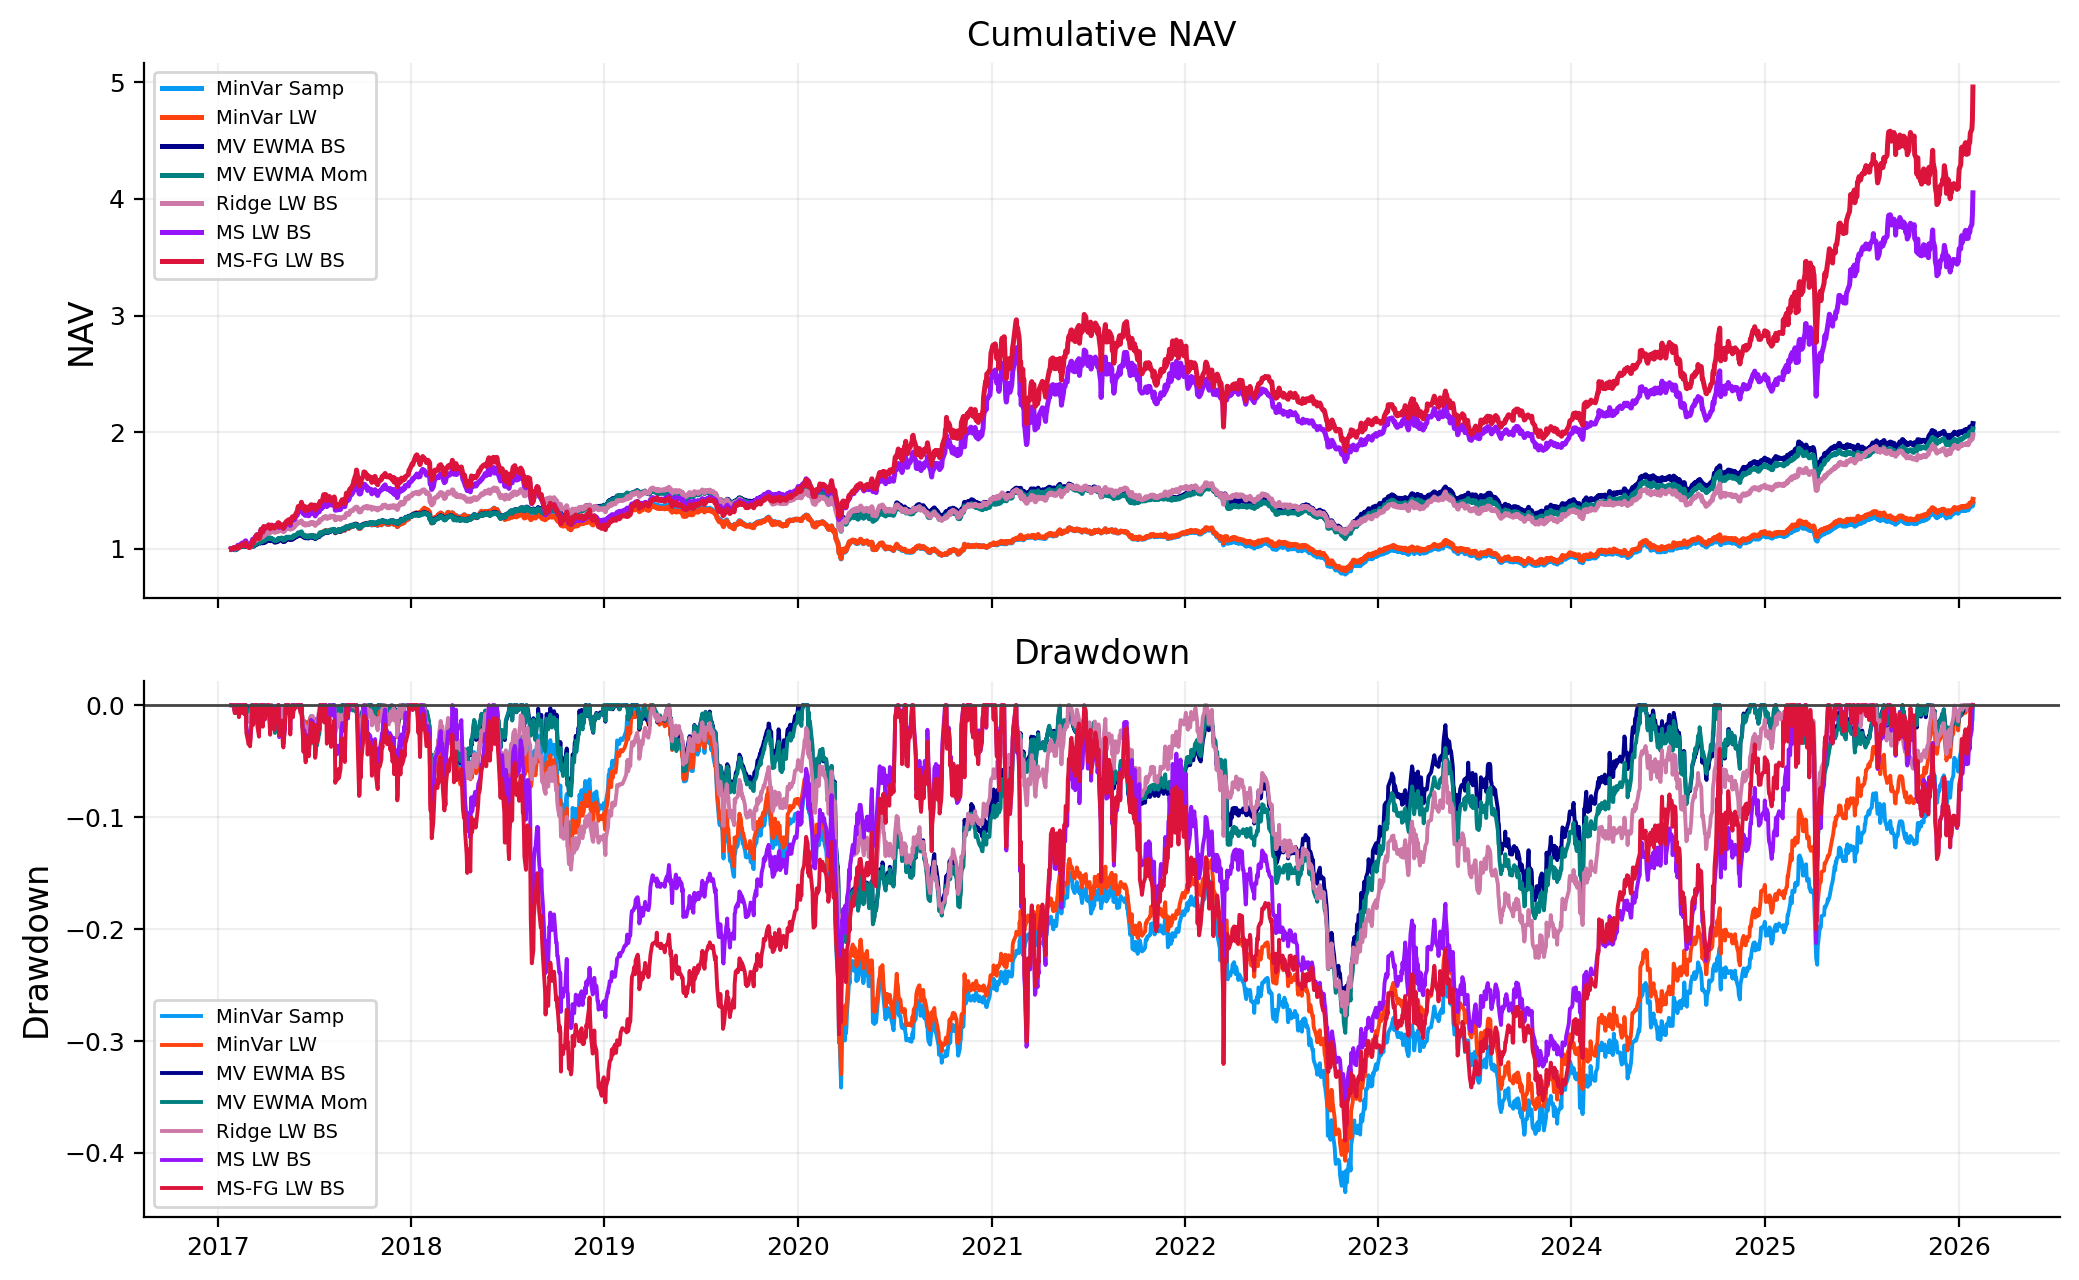

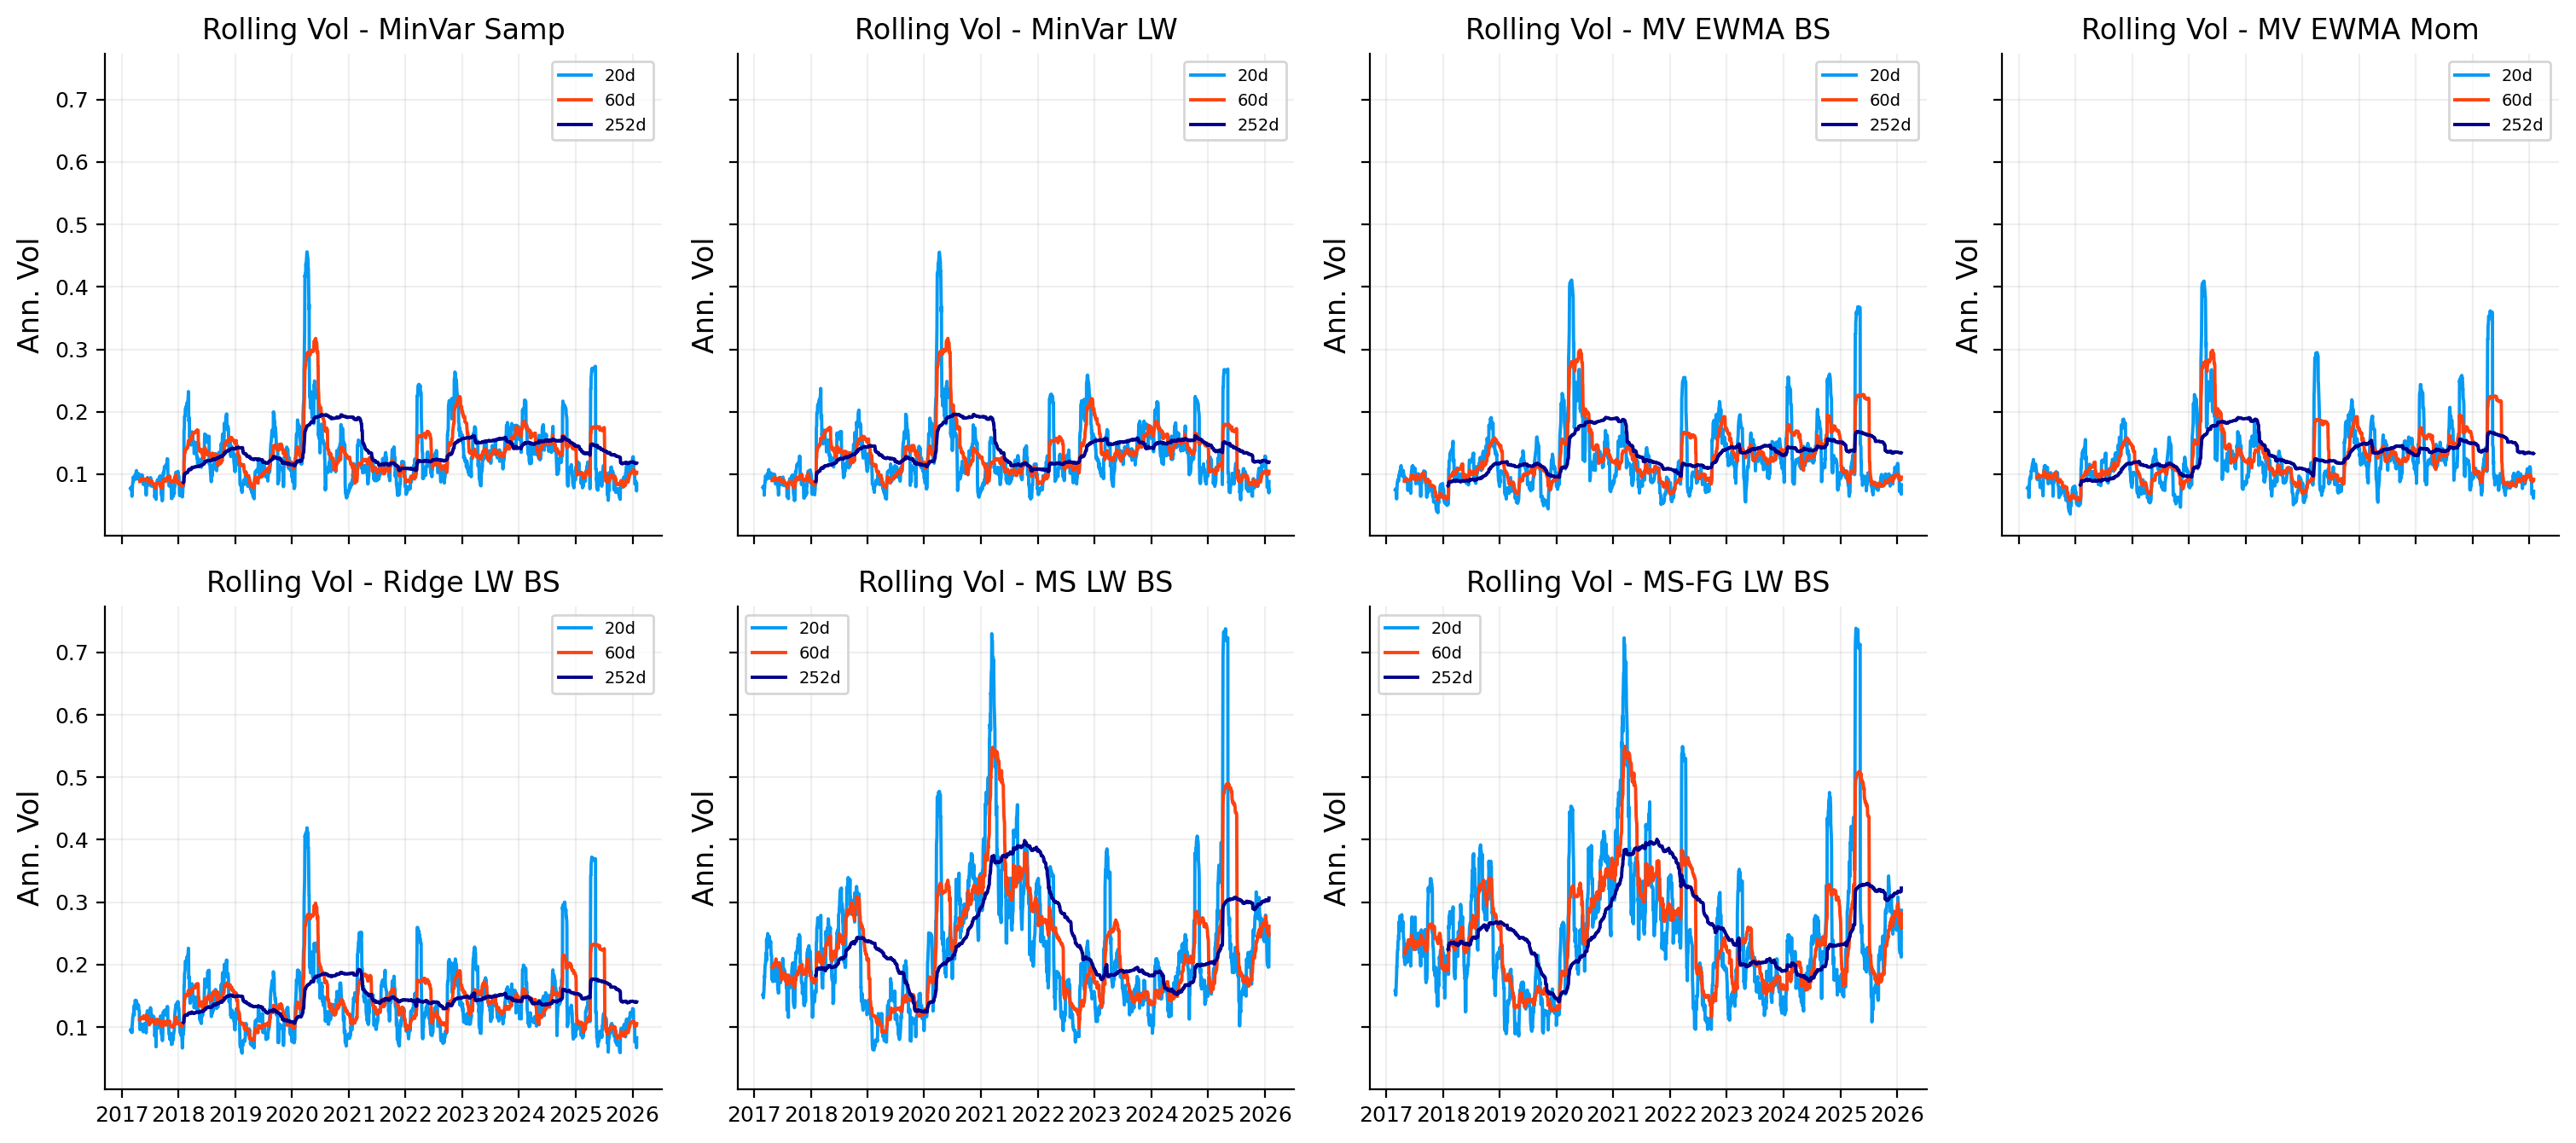

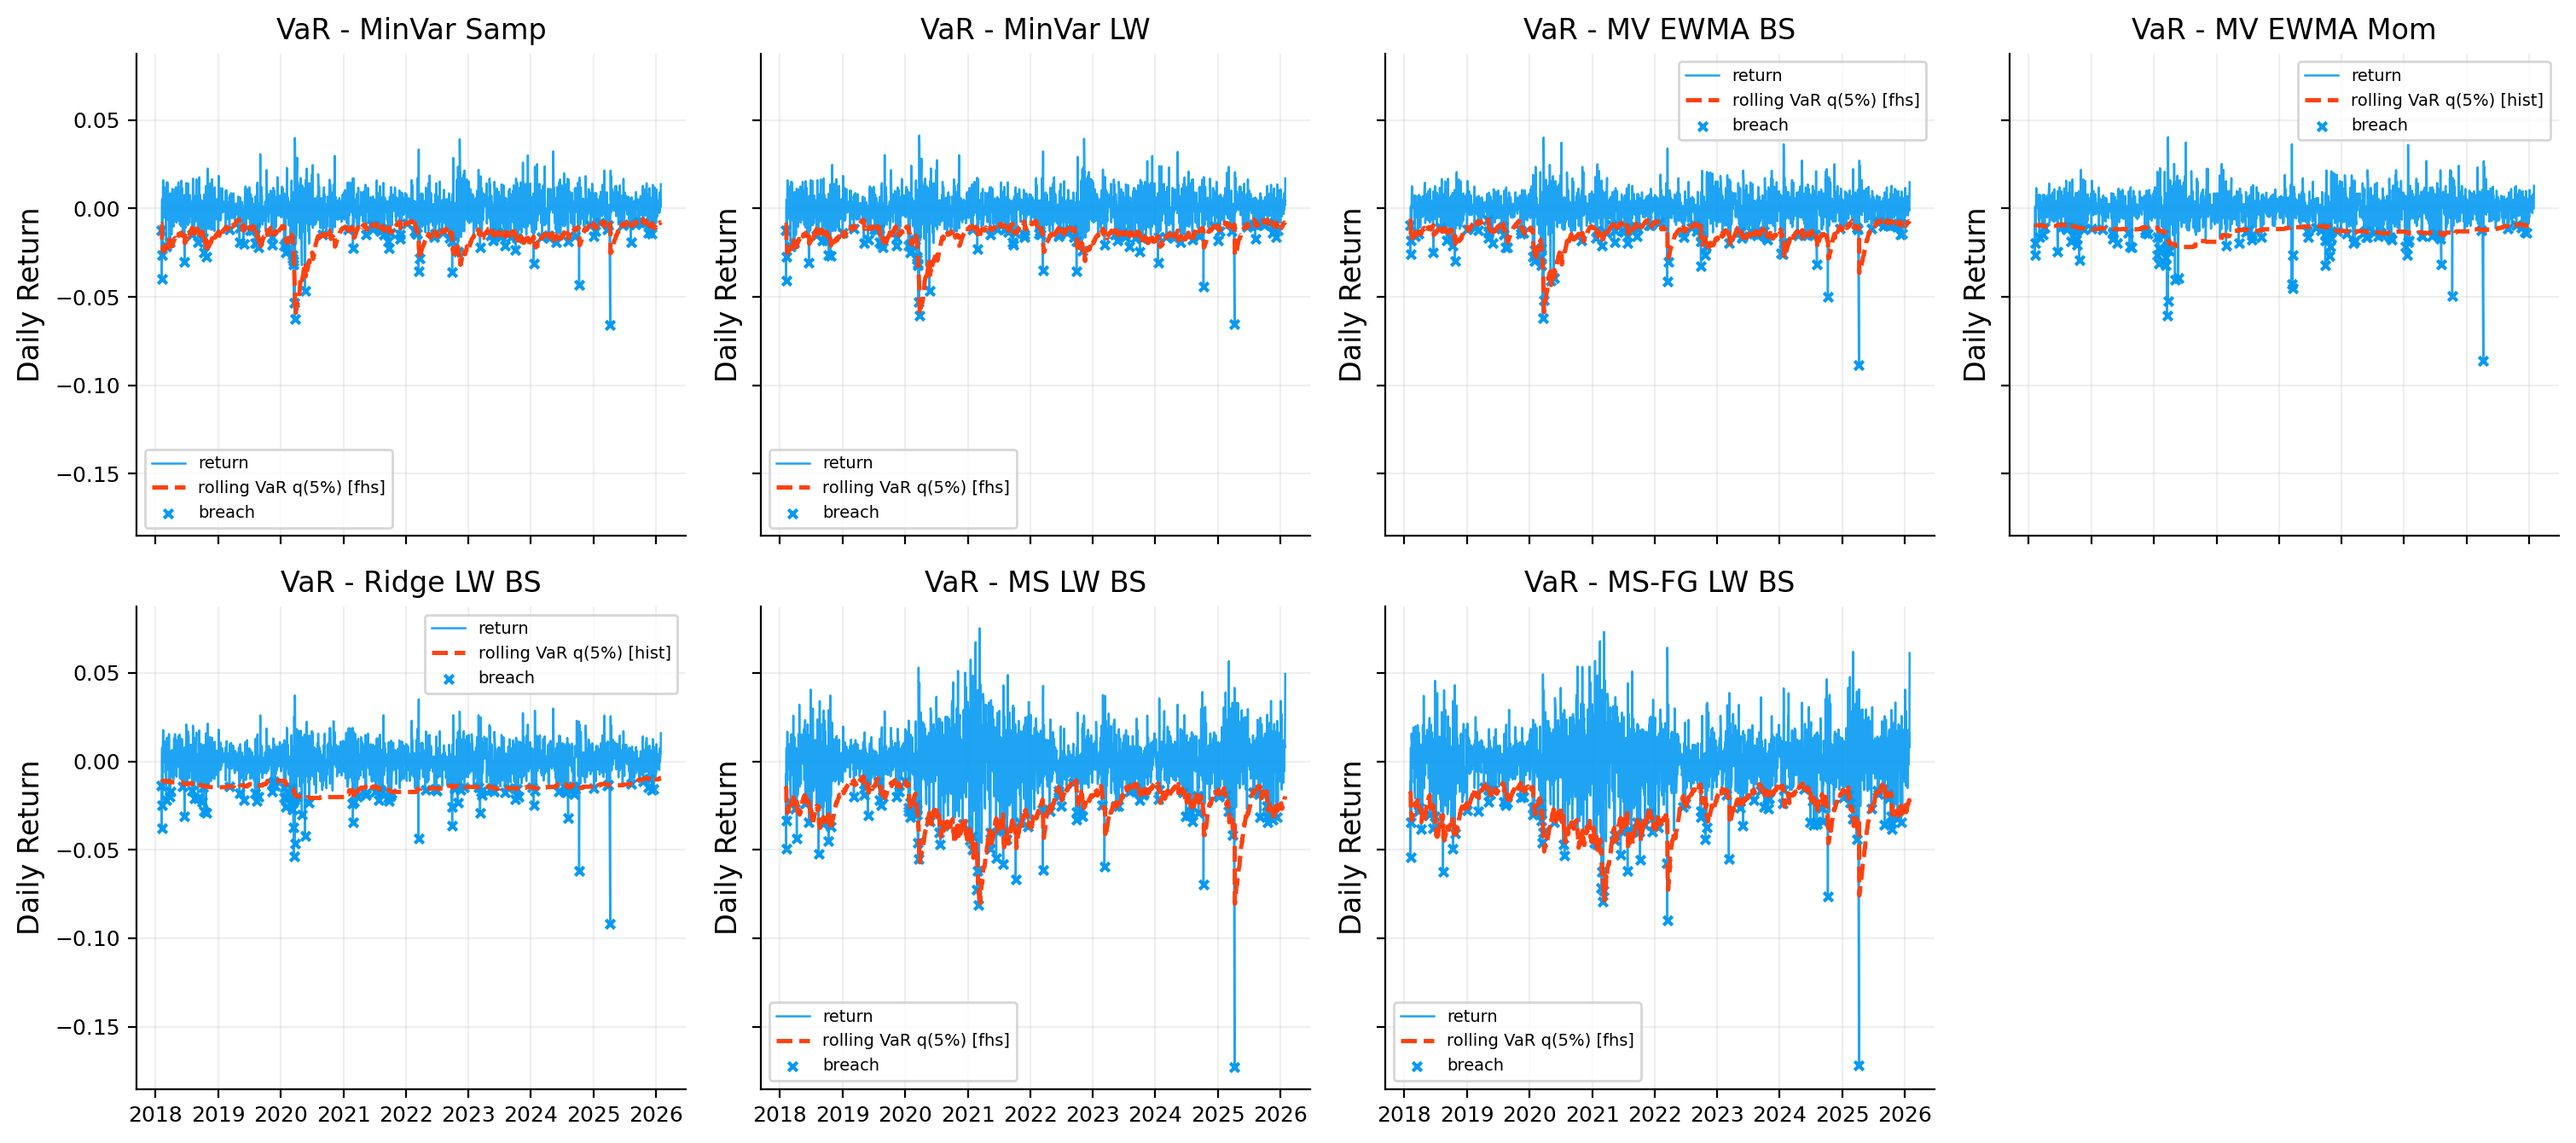

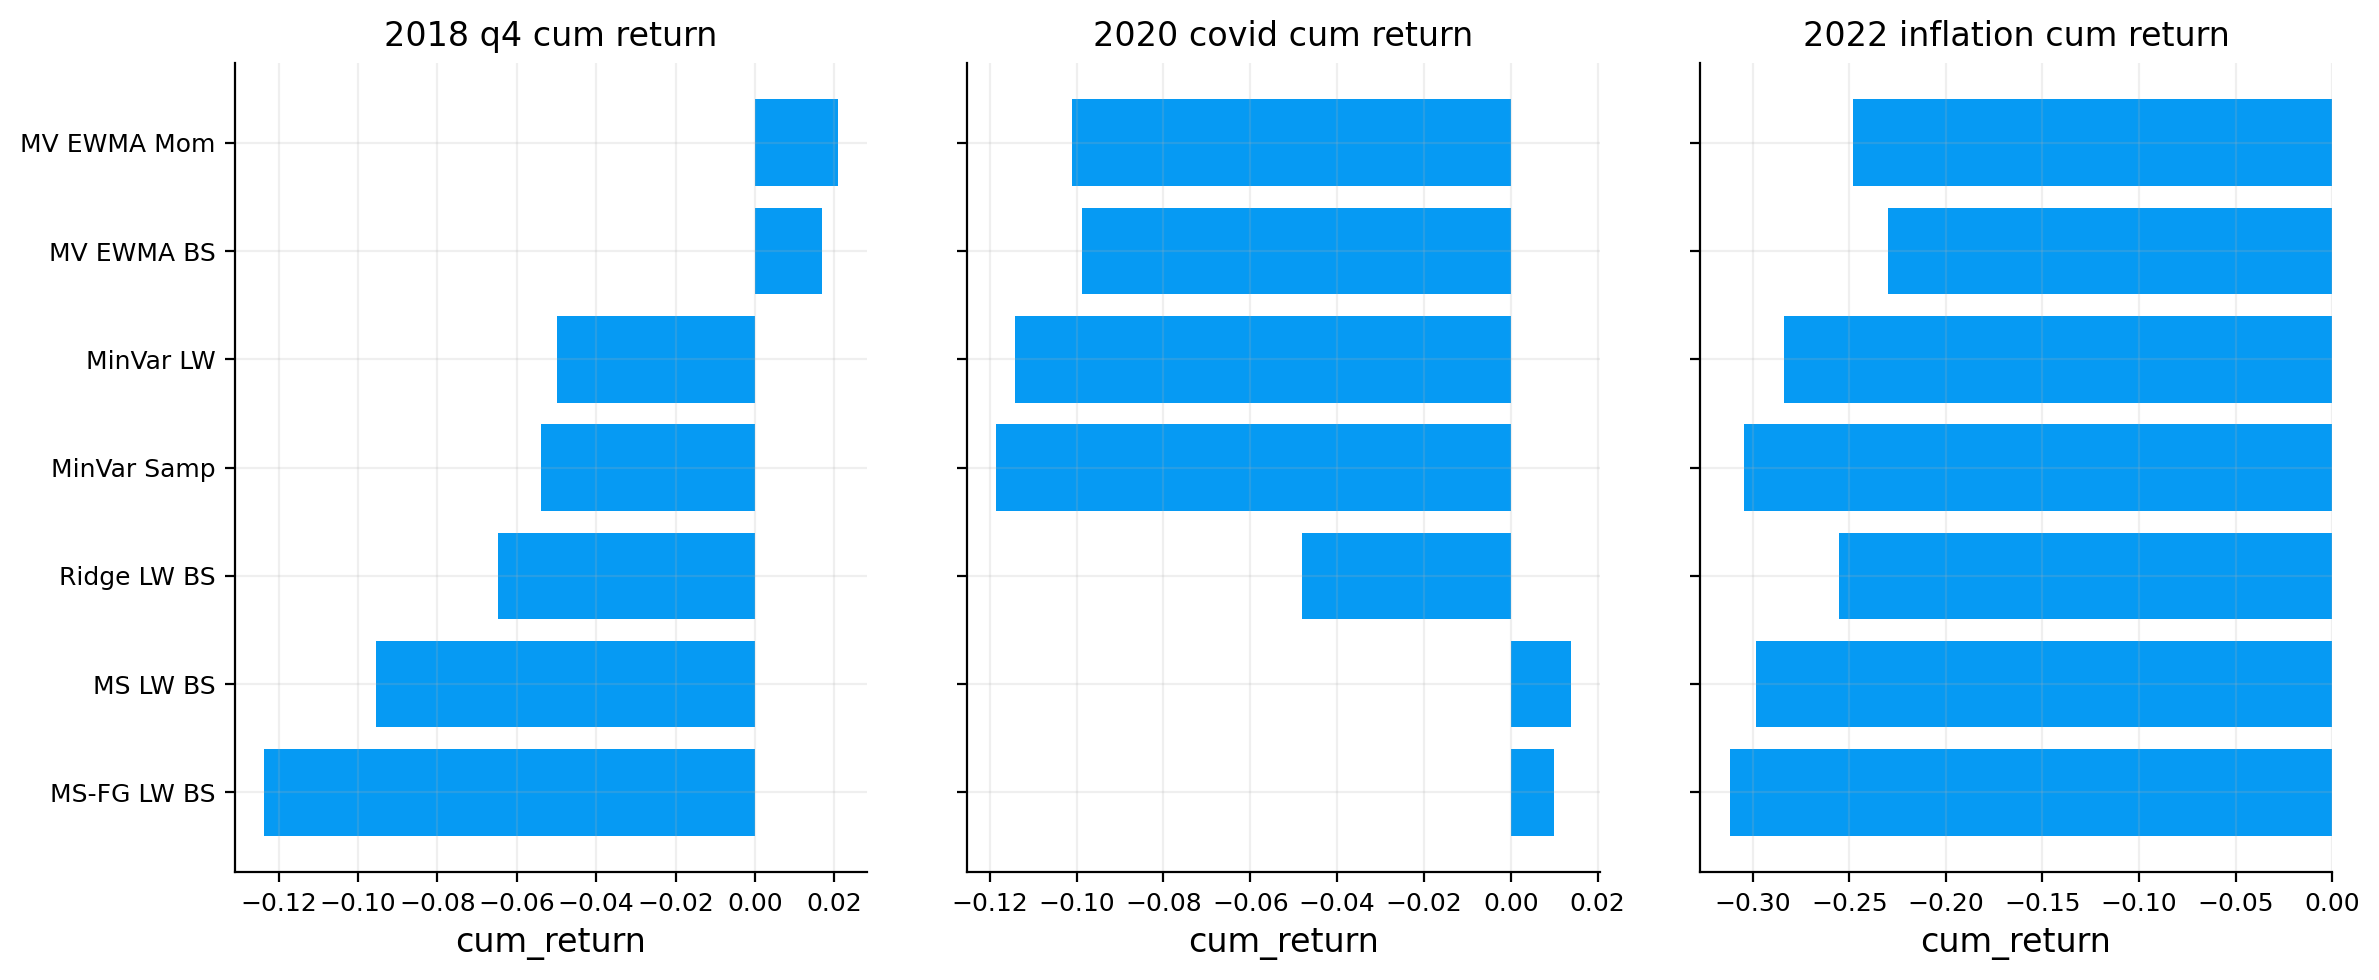

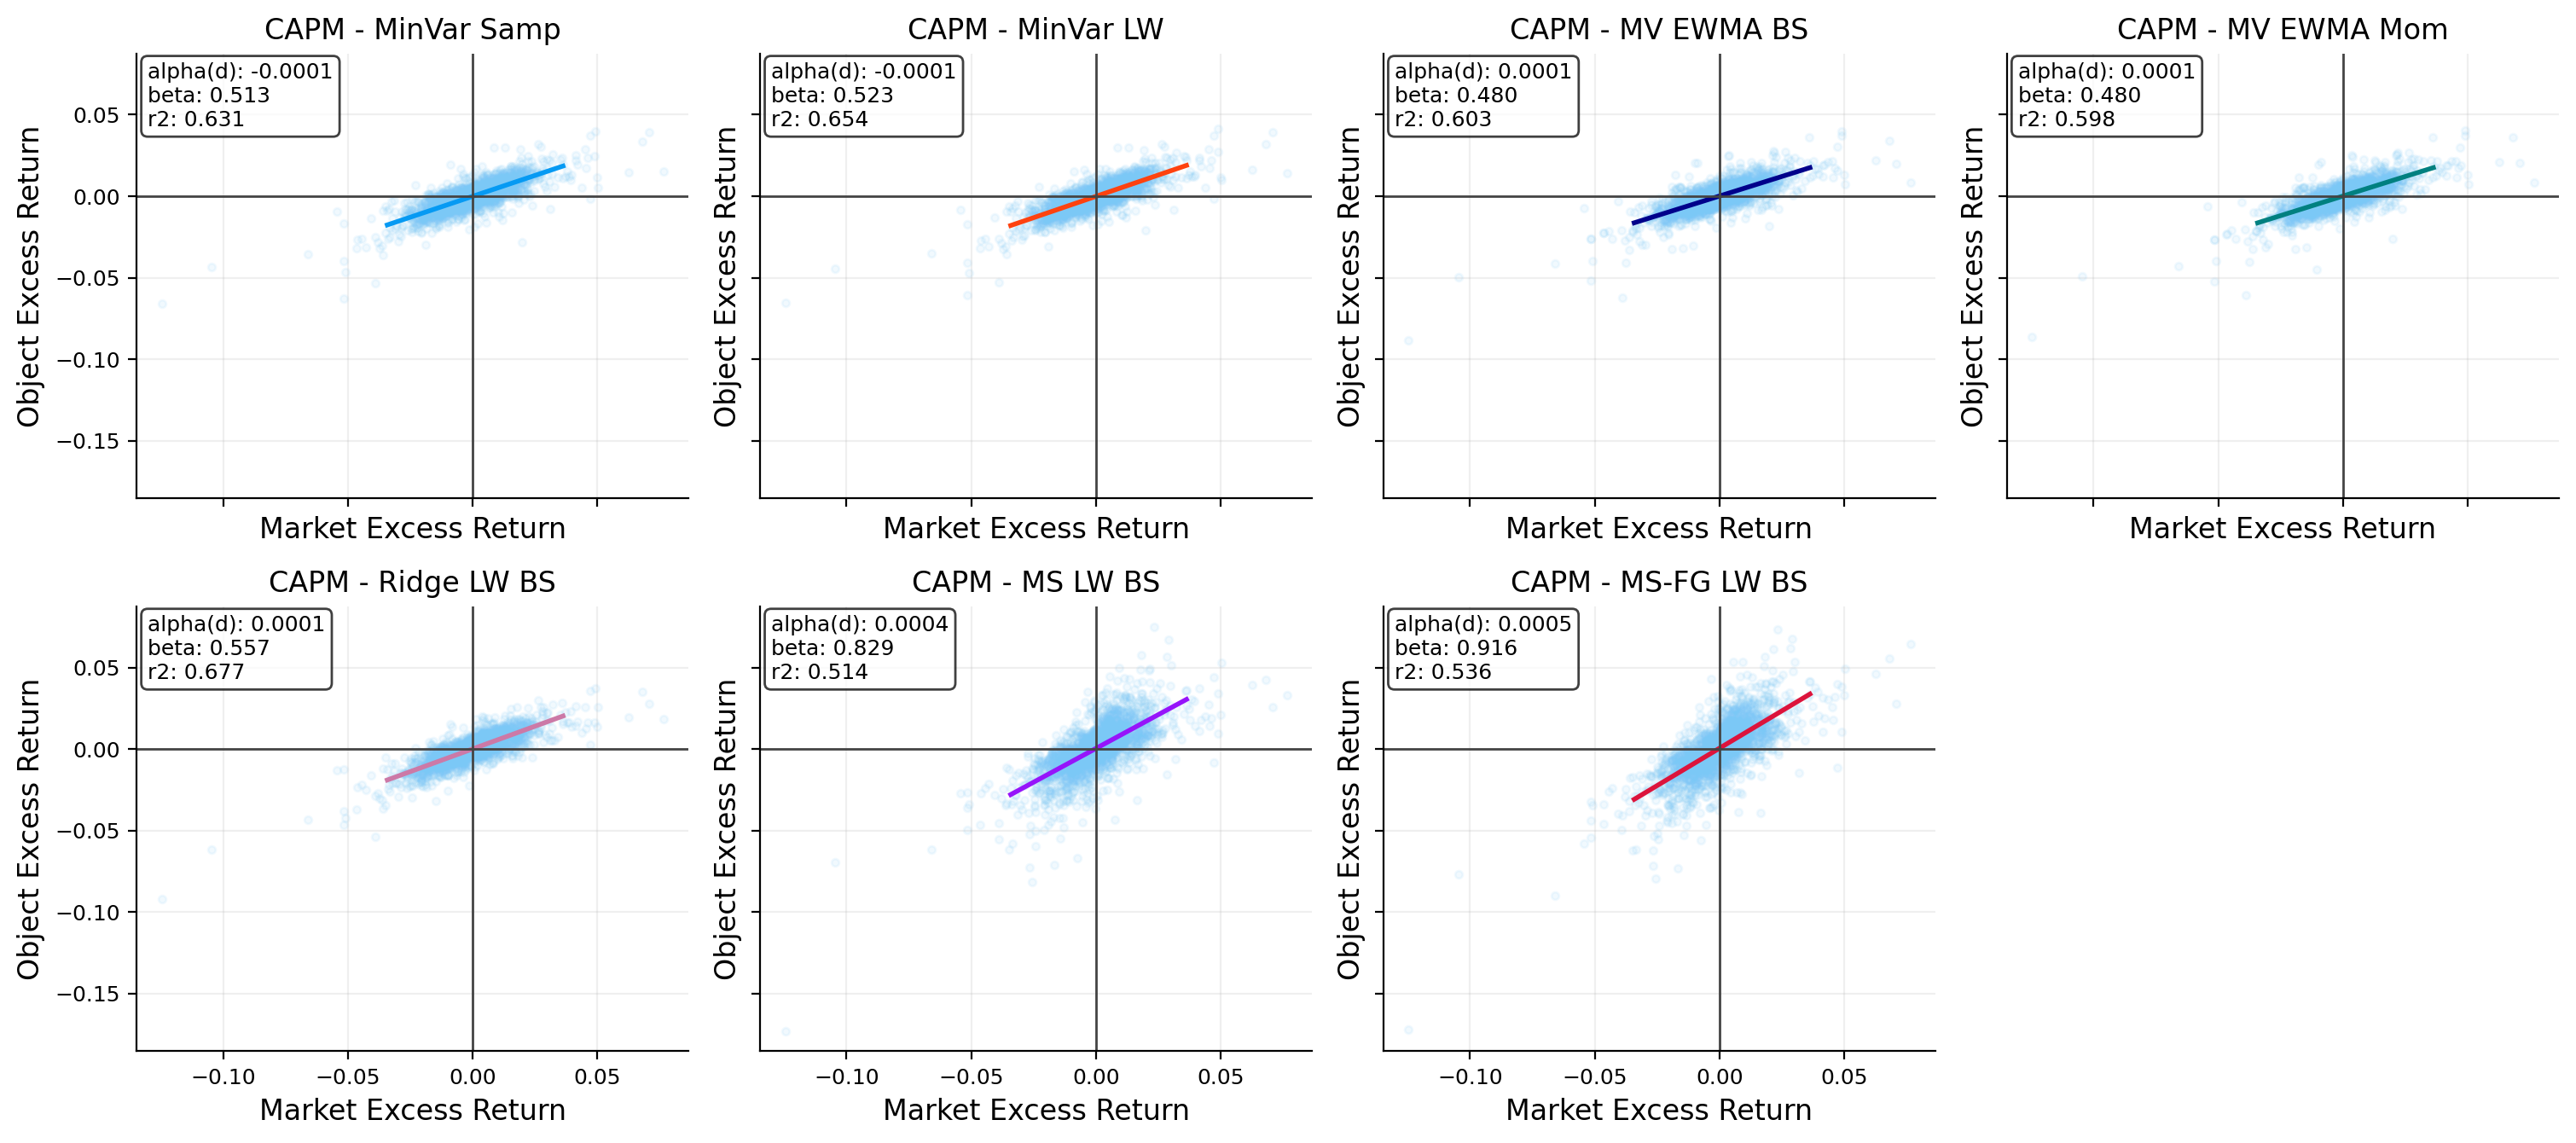

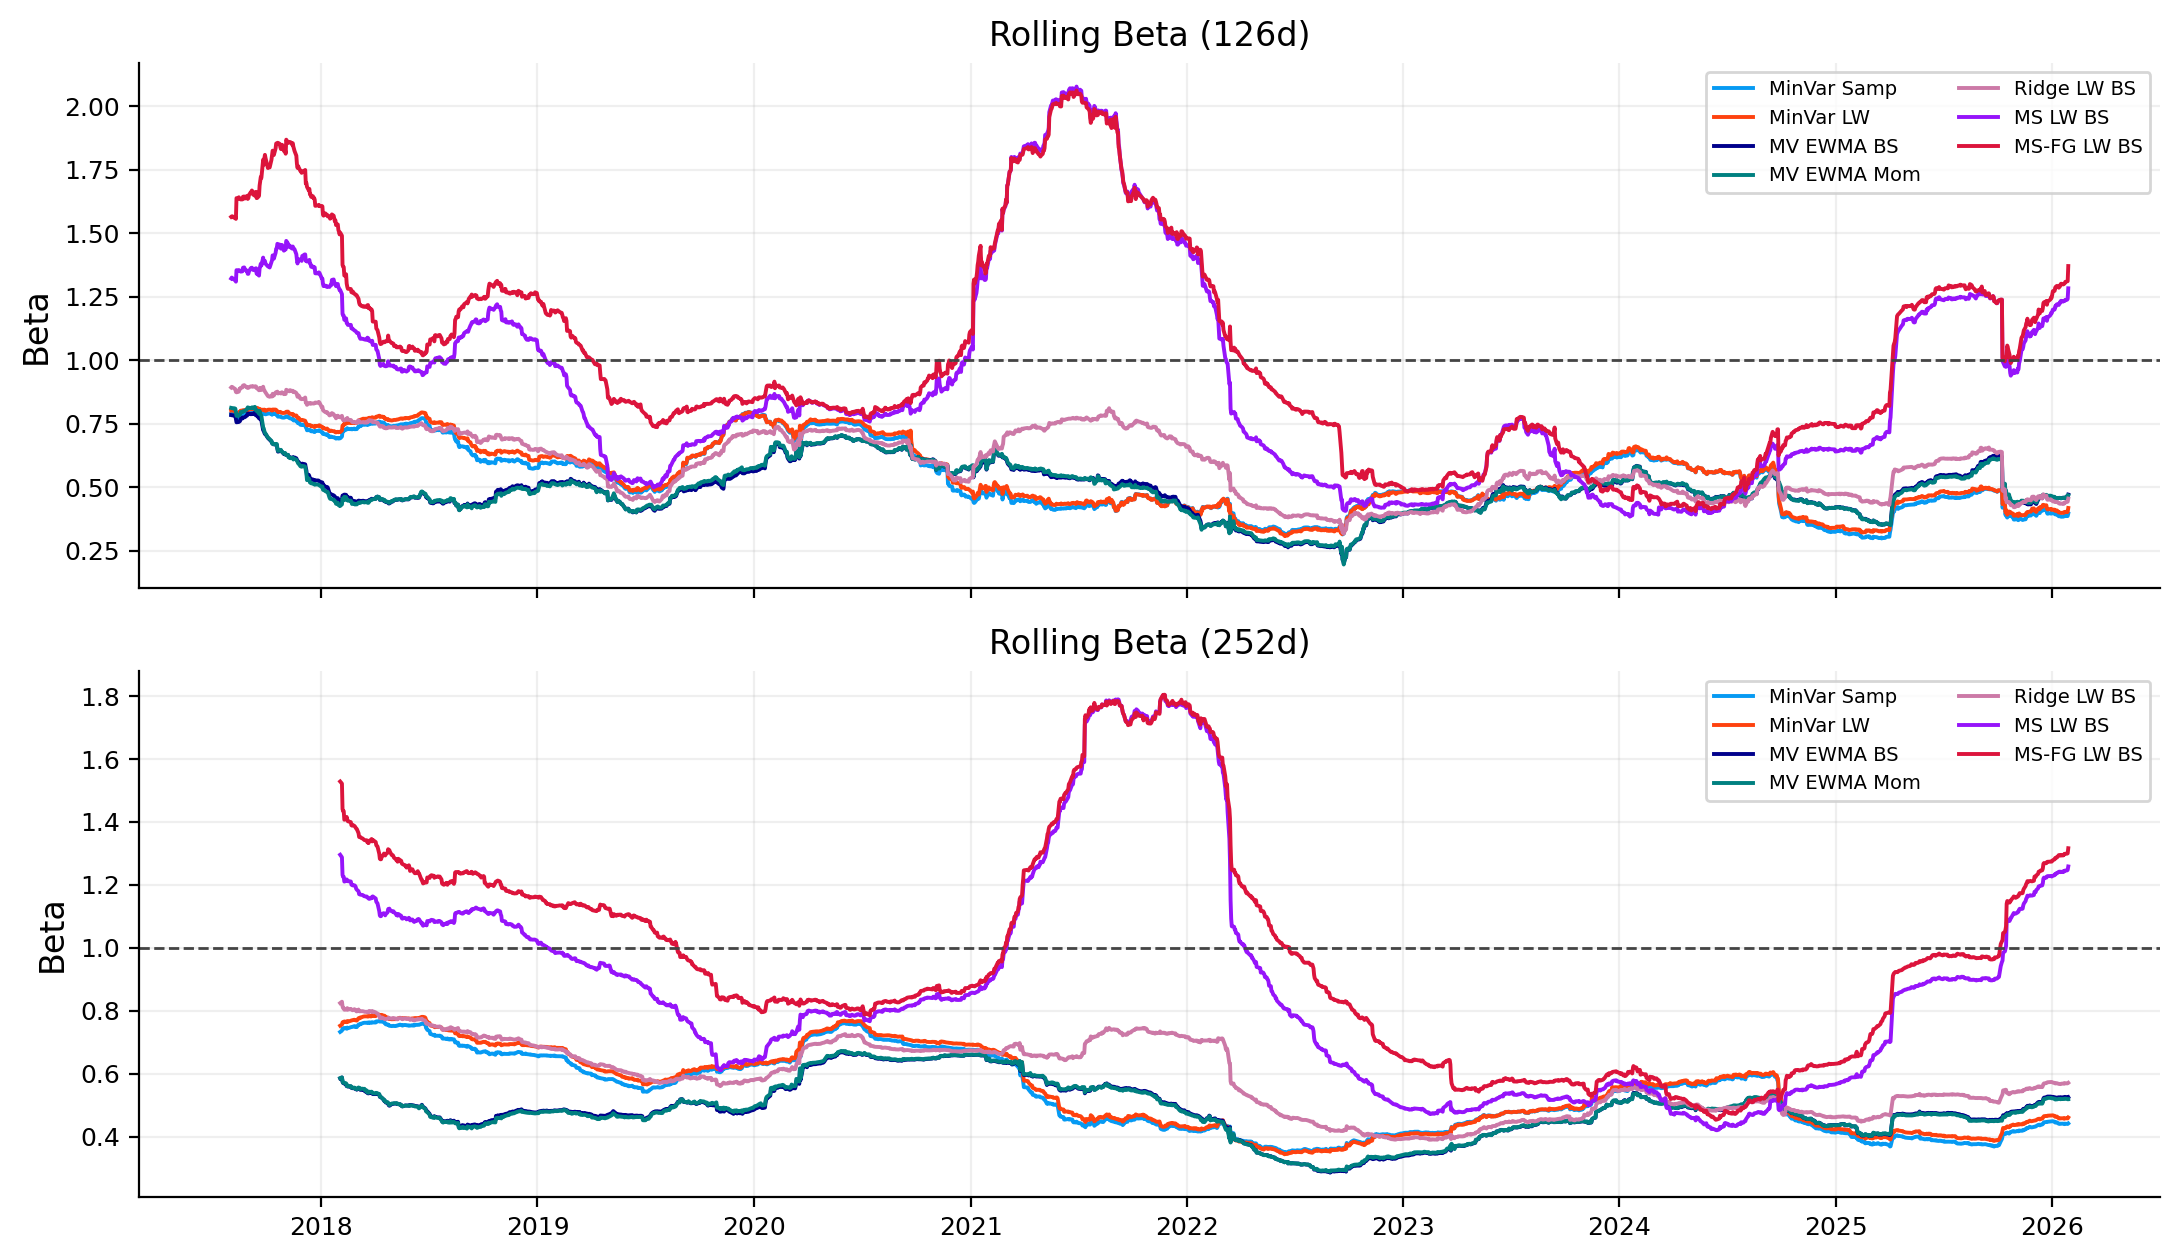

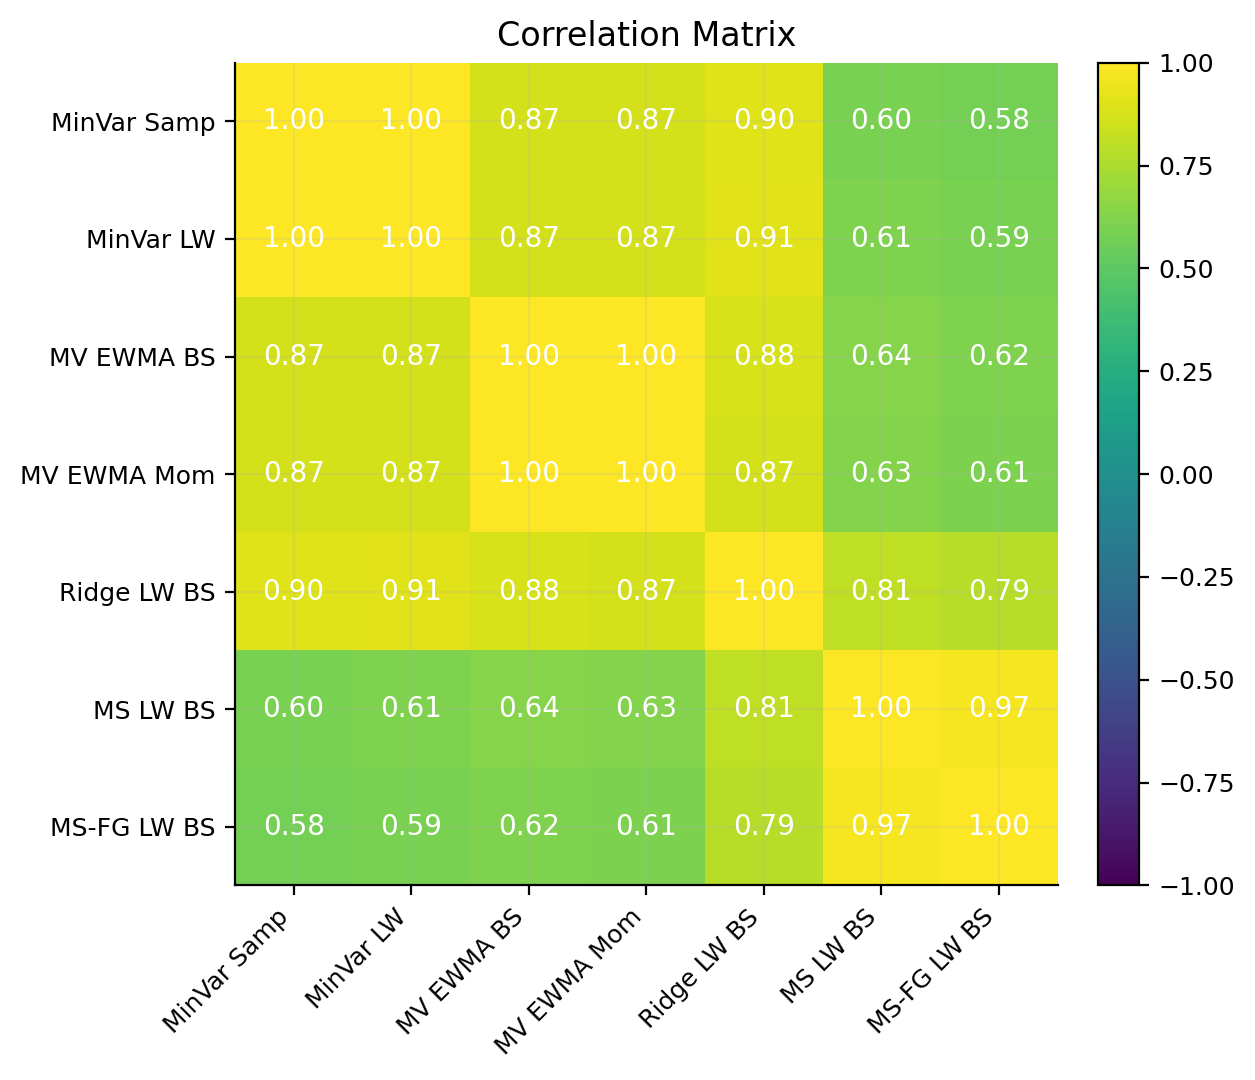

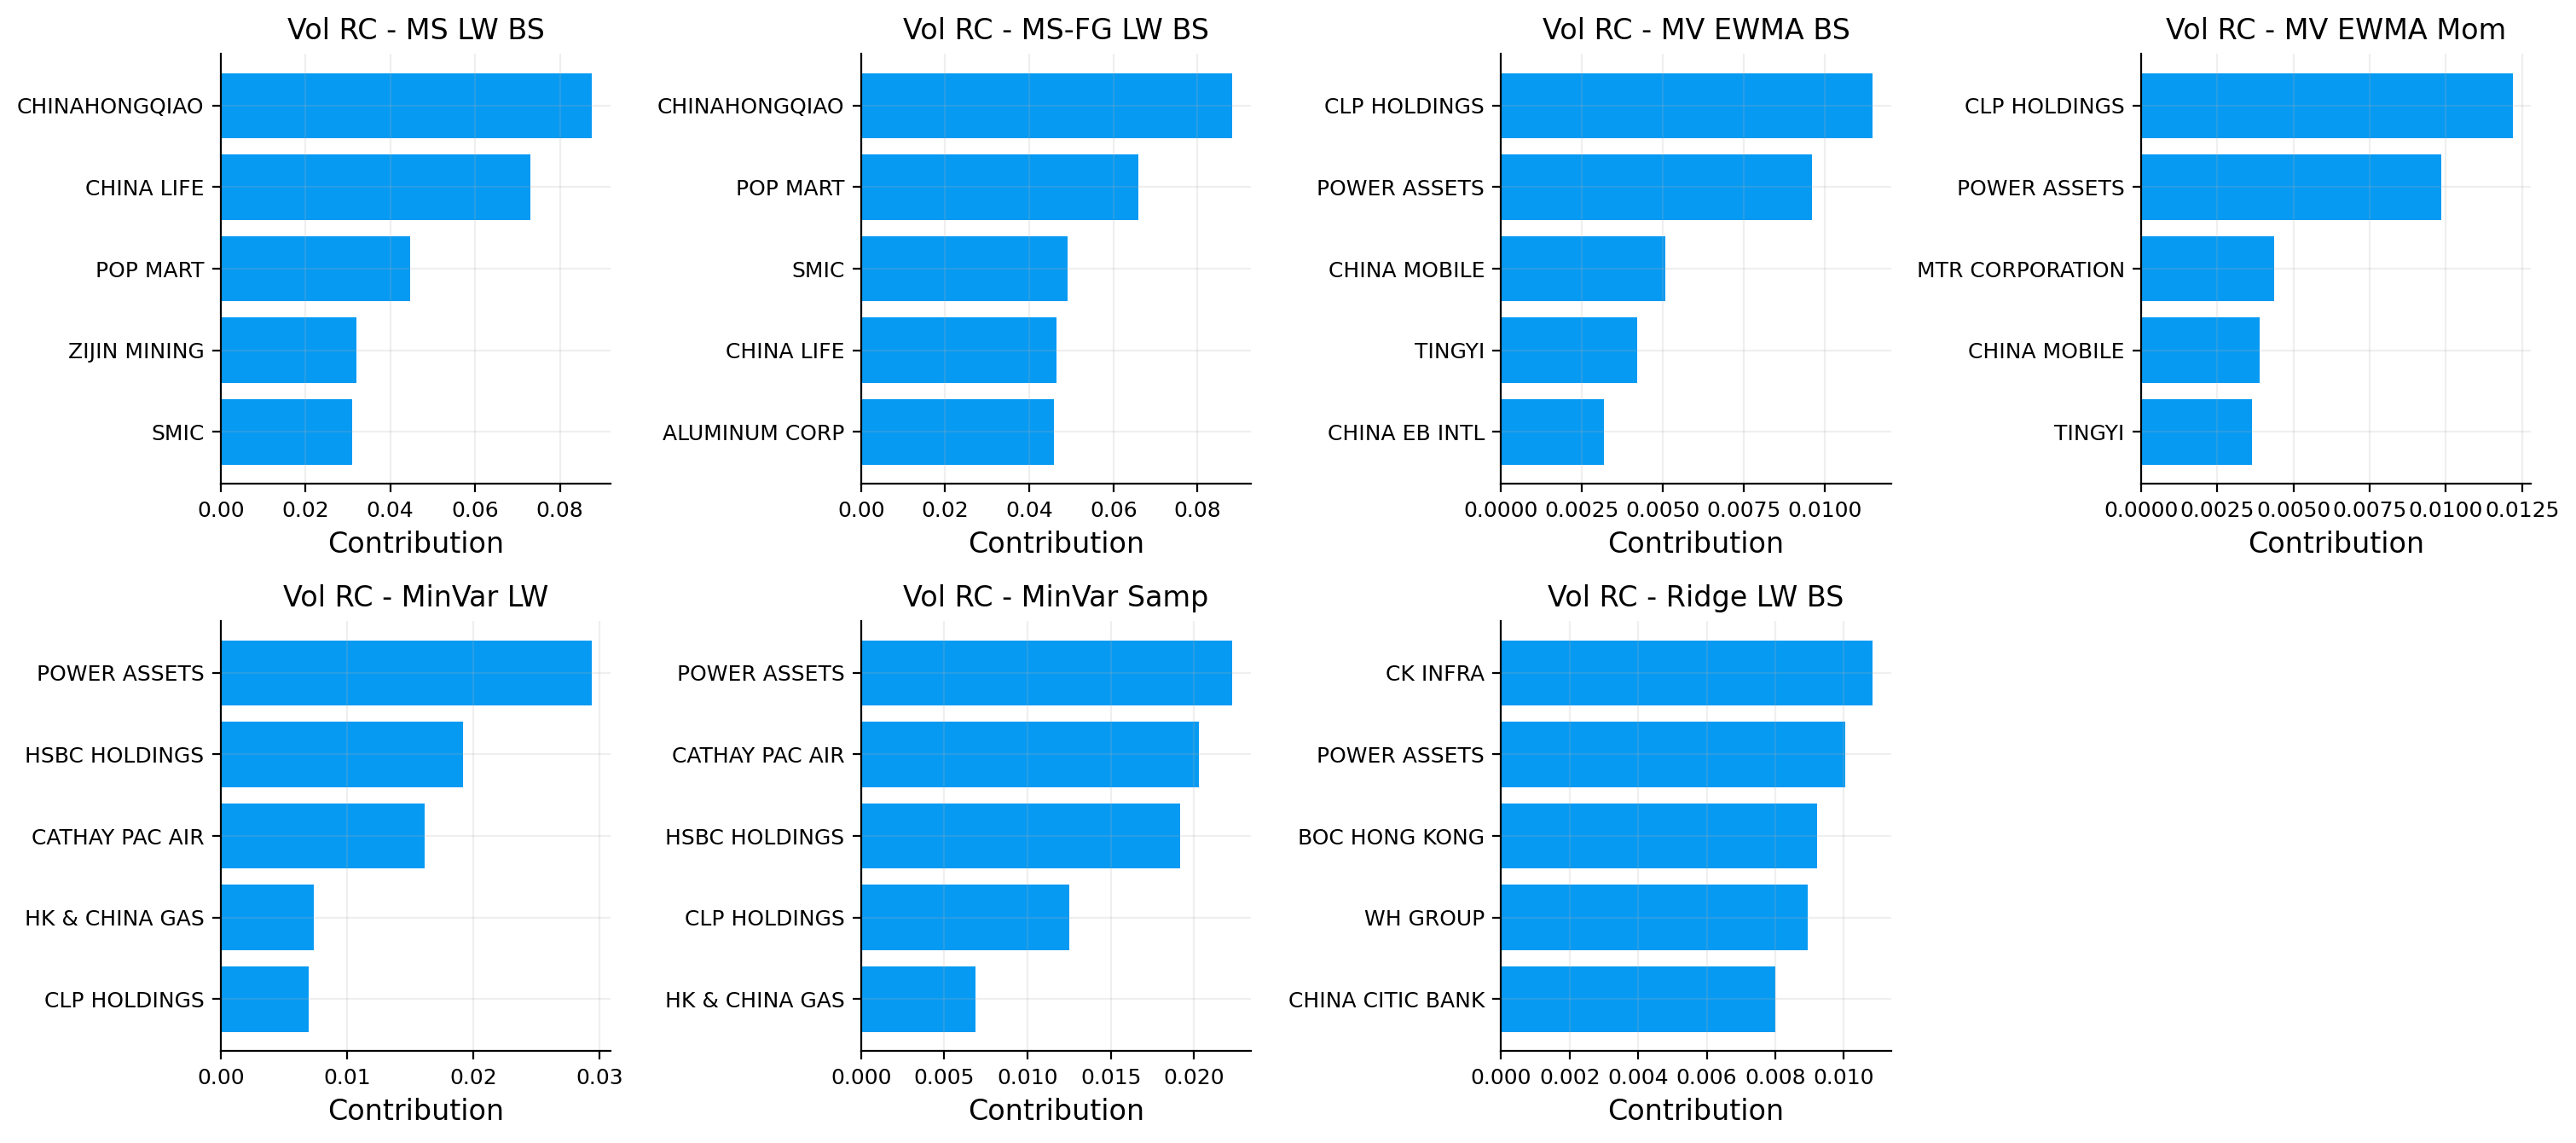

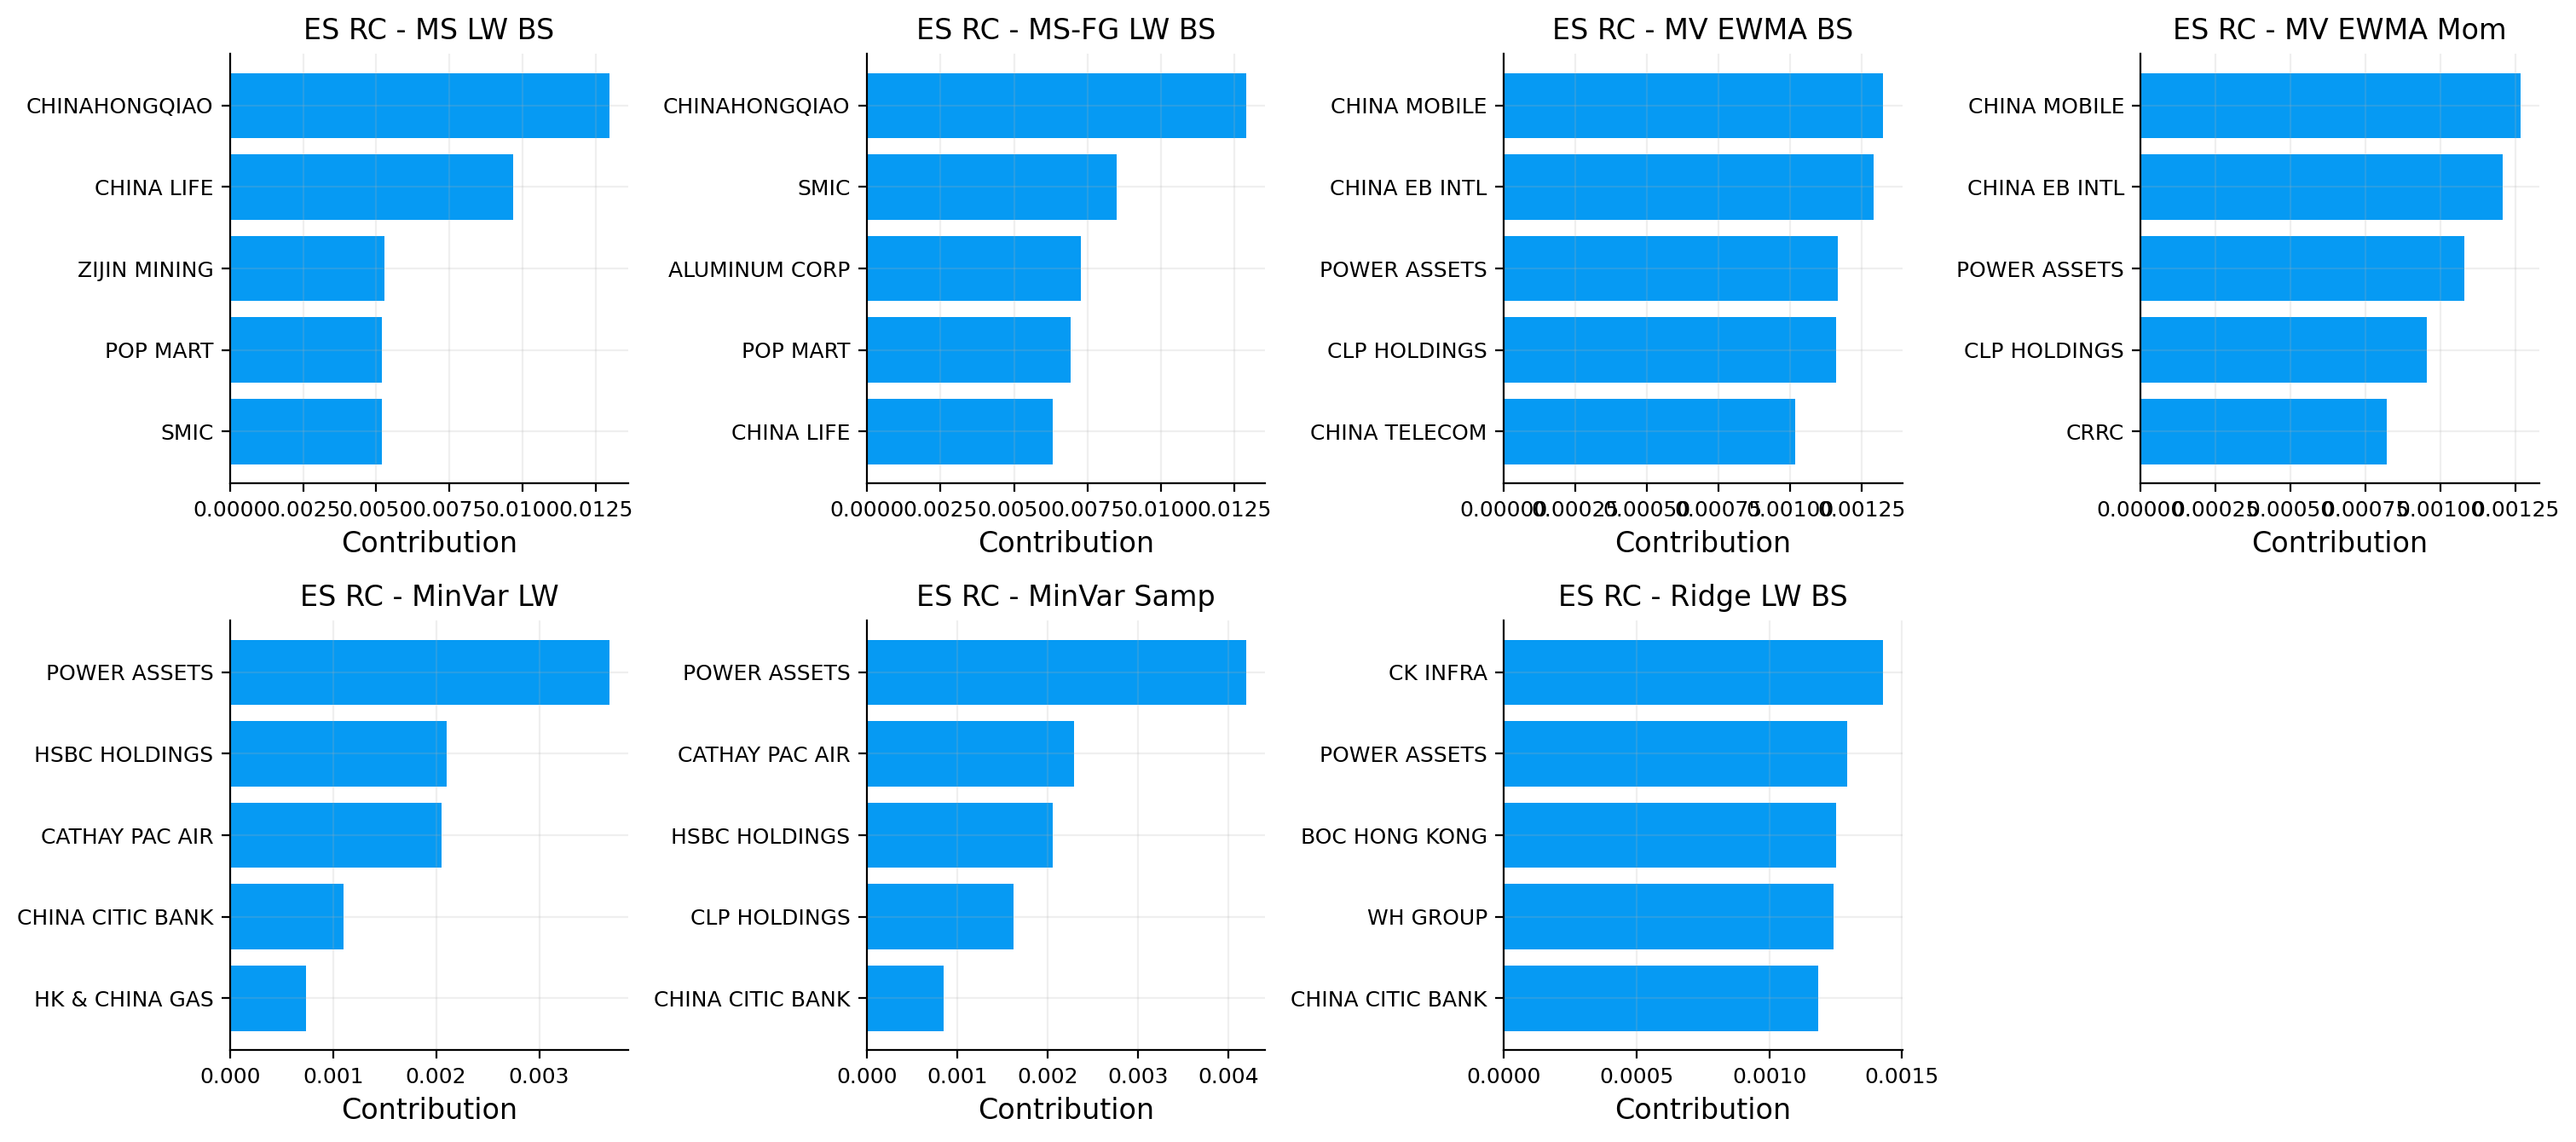

HKEX finalists in report: ['MinVar Samp', 'MinVar LW', 'MV EWMA BS', 'MV EWMA Mom', 'Ridge LW BS', 'MS LW BS', 'MS-FG LW BS']
HKEX report tables: ['attribution_es', 'attribution_overlap', 'attribution_vol', 'capm', 'corr', 'drawdown_episodes', 'drawdown_summary', 'performance', 'shape', 'stress', 'var_backtest', 'var_es']


In [28]:
import warnings

import pandas as pd

from quantfinlab.portfolio import covariance, expected_returns, optimizers, universe, walkforward
from quantfinlab.reports import risk_report

warnings.filterwarnings("ignore")

rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0

HK_FINALISTS = [
    "MinVar Samp",
    "MinVar LW",
    "MV EWMA BS",
    "MV EWMA Mom",
    "Ridge LW BS",
    "MS LW BS",
    "MS-FG LW BS",
]

HK_STRATEGY_SPECS = [
    {"name": "EW", "optimizer": "EW"},
    {"name": "MinVar Samp", "optimizer": "MinVar", "cov_model": "Sample"},
    {"name": "MinVar LW", "optimizer": "MinVar", "cov_model": "LedoitWolf"},
    {"name": "MV EWMA BS", "optimizer": "MV", "cov_model": "EWMA", "mu_model": "BayesStein"},
    {"name": "MV EWMA Mom", "optimizer": "MV", "cov_model": "EWMA", "mu_model": "Momentum"},
    {"name": "Ridge LW BS", "optimizer": "RidgeMV", "cov_model": "LedoitWolf", "mu_model": "BayesStein"},
    {"name": "MS LW BS", "optimizer": "MaxSharpe", "cov_model": "LedoitWolf", "mu_model": "BayesStein"},
    {"name": "MS-FG LW BS", "optimizer": "FrontierGrid", "cov_model": "LedoitWolf", "mu_model": "BayesStein"},
]

raw = pd.read_csv("../data/hkex_selected_close_volume.csv", header=[0, 1], low_memory=False)
raw.columns = pd.MultiIndex.from_tuples([(str(a).strip(), str(b).strip()) for a, b in raw.columns])

date_cols = [c for c in raw.columns if c[0].lower() == "date"]
close_cols = [c for c in raw.columns if c[1].lower() == "close"]
volume_cols = [c for c in raw.columns if c[1].lower() == "volume"]

dates = pd.to_datetime(raw[date_cols[0]], errors="coerce")

close_prices_hk = raw.loc[:, close_cols].copy()
volumes_hk = raw.loc[:, volume_cols].copy()
close_prices_hk.columns = [str(c[0]).strip() for c in close_cols]
volumes_hk.columns = [str(c[0]).strip() for c in volume_cols]

if close_prices_hk.columns.duplicated().any():
    close_prices_hk = close_prices_hk.T.groupby(level=0).last().T
if volumes_hk.columns.duplicated().any():
    volumes_hk = volumes_hk.T.groupby(level=0).last().T

close_prices_hk.index = dates
volumes_hk.index = dates

close_prices_hk, volumes_hk = universe.clean_close_volume_panels(close_prices_hk, volumes_hk, start="2016-01-01")
returns_hk = universe.prices_to_returns(close_prices_hk)
rebal_dates_hk = universe.make_rebalance_dates(returns_hk.index, freq="ME", min_history_days=252)

stack_hk = walkforward.run_walkforward_grid(
    returns=returns_hk,
    close=close_prices_hk,
    volume=volumes_hk,
    rebalance_dates=rebal_dates_hk,
    cov_models={
        "Sample": covariance.sample_covariance,
        "LedoitWolf": covariance.ledoit_wolf_covariance,
        "EWMA": covariance.ewma_covariance},
        
    mu_models={"BayesStein": expected_returns.bayes_stein_mu, "Momentum": expected_returns.momentum_mu},
    optimizers={
        "EW": optimizers.equal_weight,
        "MinVar": optimizers.minimum_variance,
        "MV": optimizers.mean_variance,
        "RidgeMV": optimizers.ridge_mean_variance,
        "MaxSharpe": optimizers.max_sharpe_slsqp,
        "FrontierGrid": optimizers.max_sharpe_frontier_grid},

    strategy_specs=HK_STRATEGY_SPECS,
    rf_daily=rf_daily,
    annualization=252)

missing_hk = [name for name in HK_FINALISTS if name not in stack_hk.backtests]
if missing_hk:
    raise KeyError(f"Missing expected HKEX finalist portfolios: {missing_hk}")

results_hk_all = dict(stack_hk.backtests)
results_hk = {name: results_hk_all[name] for name in HK_FINALISTS}
display(stack_hk.results.loc[HK_FINALISTS].round(4))

cache_hk = dict(stack_hk.cache)


def _default_cov_key(state_cache):
    for state in state_cache.values():
        cov_map = state.get("cov_ann_map", {})
        for preferred in ("LedoitWolf", "OAS", "Sample", "EWMA", "ledoitwolf", "oas", "sample", "ewma"):
            if preferred in cov_map:
                return preferred
        if cov_map:
            return next(iter(cov_map.keys()))
    return None


def _cov_key_for_backtest(result, fallback):
    meta = dict(result.metadata or {})
    return meta.get("cov_model") or fallback


fallback_cov_key_hk = _default_cov_key(cache_hk)
cov_key_for_rc_hk = {name: _cov_key_for_backtest(res, fallback_cov_key_hk) for name, res in results_hk.items()}

common_idx = None
for res in results_hk.values():
    idx_res = pd.DatetimeIndex(res.net_returns.index)
    common_idx = idx_res if common_idx is None else common_idx.intersection(idx_res)
if common_idx is None or len(common_idx) == 0:
    raise ValueError("No overlapping index across HKEX finalist returns.")

objects_hk = {name: res.net_returns.reindex(common_idx).fillna(0.0) for name, res in results_hk.items()}
market_proxy = results_hk_all["EW"].net_returns.reindex(common_idx).fillna(0.0)

portfolios_hk = {
    name: {"backtest": results_hk[name], "state_cache": cache_hk, "cov_key": cov_key_for_rc_hk[name]}
    for name in results_hk.keys()}


report_hk = risk_report(
    objects=objects_hk,
    market_ret=market_proxy,
    rf_daily=rf_daily,
    portfolios=portfolios_hk,
    include={
        "performance_tables": True,
        "shape_tables": True,
        "drawdowns": True,
        "drawdown_episodes": True,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": True,
        "exec_bullets": True,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    rolling_settings={"vol_windows": [20, 60, 252], "beta_windows": [126, 252]},
    stress_settings={
        "windows": {
            "2018_q4": ("2018-10-01", "2018-12-31"),
            "2020_covid": ("2020-02-20", "2020-04-30"),
            "2022_inflation": ("2022-01-03", "2022-10-31"),
        },
        "worst_only": True,
        "worst_by": "cum_return",
    },
    attribution_settings={"es_alpha": 0.05, "top_k": 5},
    layout={"ncols": 4, "sharex": True, "sharey": True},
    output={
        "round_tables": 4,
        "print_exec_bullets": True,
        "display_tables": True,
        "label_max_len": 16,
        "hide_table_keys": [
            "drawdown_episodes",
            "stress",
            "corr",
            "attribution_overlap",
            "attribution_vol",
            "attribution_es",
        ],
        "show_figures": True,
    },
)

print("HKEX finalists in report:", HK_FINALISTS)
print("HKEX report tables:", sorted(report_hk.tables.keys()))
